# Business Understanding

### BO1: Implement a Pathway Recommendation System

* Build a system that leverages pharmaceutical product data along with real-world customer interactions and feedback to identify:

    * The symptoms addressed by each product
    * Their galenic form
    * Their corresponding therapeutic phase within a treatment pathway

* Serve as a core recommendation engine that transforms patient-reported symptoms into a ranked, phase-structured therapeutic pathway, guiding the selection of complementary pharmaceutical products.

### DSO1: Hybrid Similarity & Classification Pipeline

* Deploy an AI-driven pipeline combining NLP preprocessing, semantic similarity, and supervised classification to:

    * Extract structured symptom information from unstructured fields (indication, posology)
    * Compute similarity between patient symptoms and product descriptions
    * Classify products into their appropriate therapeutic phases based on inferred galenic form

* Infer the therapeutic pathway by organizing products into four phases:

    * Phase 1: Cleansing
    * Phase 2: Local Treatment
    * Phase 3: Internal Treatment
    * Phase 4: Maintenance

*******************
### BO2: Cut training and operational costs

* Replace expensive in-person sessions and printed materials with digital alternatives.

* Improve training quality while eliminating travel and material expenditures.

### DSO2: Launch a Virtual Training and Interaction Platform

* Establish a digital academy featuring AI patient simulations and interactive online modules for global, 24/7 access.

* Eliminate travel and printing costs through this scalable solution.
*******************
### BO3: Simplify and Secure the Creation of Compliant Product Indications

* Reduce compliance risks by automatically generating indications that follow regulatory rules before they are shared.
* Save time and ensure consistency by delivering ready-to-use reports and presentations that are clear, accurate, and easy to share with doctors.

### DSO3: Implement an AI-Powered Compliant Indication Generation Module

* Develop a system that analyzes product data, detects non-compliant terms (e.g., forbidden words, disease claims), and rewrites indications based on regulatory guidelines.
* Automatically enrich outputs with safety disclaimers and generate structured reports and presentation slides, ensuring compliant and ready-to-use deliverables.
*******************
### BO4: Prevent Loss of Key Healthcare Professionals
* Identify doctors and pharmacists who may stop prescribing or engaging with your products before they do.
* Detect early disengagement signals during live delegate-HCP conversations through voice tone and sentiment analysis, not just after the fact.
### DSO4: Deploy an AI-Powered HCP Engagement & Churn Predictor
* Implement a multimodal AI system that analyzes real-time delegate-HCP conversation audio within the AVATAR platform to detect engagement risk.
* Use Speech Emotion Recognition (SER) to extract Valence-Arousal-Dominance (VAD) from the HCP's voice, combined with text sentiment analysis of the transcribed conversation via Whisper STT.
* Apply a fusion layer that merges voice emotion and text sentiment signals to detect "tonal flattening" — the early warning pattern where an HCP shifts from frustrated/engaged to neutral/indifferent.

# Data Acquisition and Understanding

## DSO1: Hybrid Similarity & Classification Pipeline

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re

from itertools import combinations
import warnings

warnings.filterwarnings('ignore')

# ============================================================================
# CONFIGURATION
# ============================================================================

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
%matplotlib inline

# High-resolution output
plt.rcParams['figure.dpi'] = 100
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['font.size'] = 10

print("=" * 80)
print("DSO1: THERAPEUTIC PATHWAY RECOMMENDATION SYSTEM")
print("Data Understanding & Visualization - COMPLETE NOTEBOOK")
print("=" * 80)
print("\n All libraries imported successfully")

DSO1: THERAPEUTIC PATHWAY RECOMMENDATION SYSTEM
Data Understanding & Visualization - COMPLETE NOTEBOOK

 All libraries imported successfully


In [3]:
# ============================================================================
# STEP 1: LOAD & EXPLORE RAW DATA
# ============================================================================

# Load Excel file
file_path = 'data/extracted_clean_plus_vital_gamme_vital.xlsx'
df = pd.read_excel(file_path)

# Normalize column names
df.columns = df.columns.str.strip().str.lower()

print(f"\n DATASET SHAPE & BASIC INFORMATION:")
print(f"   • Total Rows: {df.shape[0]:,}")
print(f"   • Total Columns: {df.shape[1]}")
print(f"   • Column Names: {df.columns.tolist()}")
produit_norm = df['produit'].fillna("").str.strip().str.lower()
invalid_mask = (
    produit_norm.eq("oops! that page can't be found.") |
    produit_norm.str.contains(r"^oops", na=False)
)

invalid_count = int(invalid_mask.sum())
df = df.loc[~invalid_mask].copy()

print(f"   • Invalid rows removed: {invalid_count:,}")
print(f"   • Rows remaining: {len(df):,}")
print(f"\n DATA TYPES:")
print(df.dtypes)

print(f"\n FIRST 5 ROWS:")
display(df.head(5))


 DATASET SHAPE & BASIC INFORMATION:
   • Total Rows: 10,588
   • Total Columns: 5
   • Column Names: ['gamme', 'produit', 'composition', 'indication', 'posologie']
   • Invalid rows removed: 35
   • Rows remaining: 10,553

 DATA TYPES:
gamme          object
produit        object
composition    object
indication     object
posologie      object
dtype: object

 FIRST 5 ROWS:


,gamme,produit,composition,indication,posologie
0,Aromessence,Aromessence Piedarom Baume 50 ml,NaN,Baume pour les pieds\n\n\nContenance de 50 ml\...,NaN
1,Bielenda,Bielenda Mask Black Sugar Detox 2En1,NaN,Masque purifiant\n\n\nÉlimine les impuretés\n\...,NaN
2,Michel-pierre,Michel Pierre Reflustop Dose De 10ml Boite 20 ...,NaN,Apaise brûlures d’estomac et reflux\n\n\nProtè...,NaN
3,Michel-pierre,Michel Pierre Digest Express 14 Sticks De 10ml,NaN,Aide à réduire ballonnements et gaz\n\n\nFavor...,NaN
4,Moline,Vasy Gel Lubrifiant 100 ml,NaN,Gel lubrifiant à base d’eau purifiée\n\n\nCont...,NaN


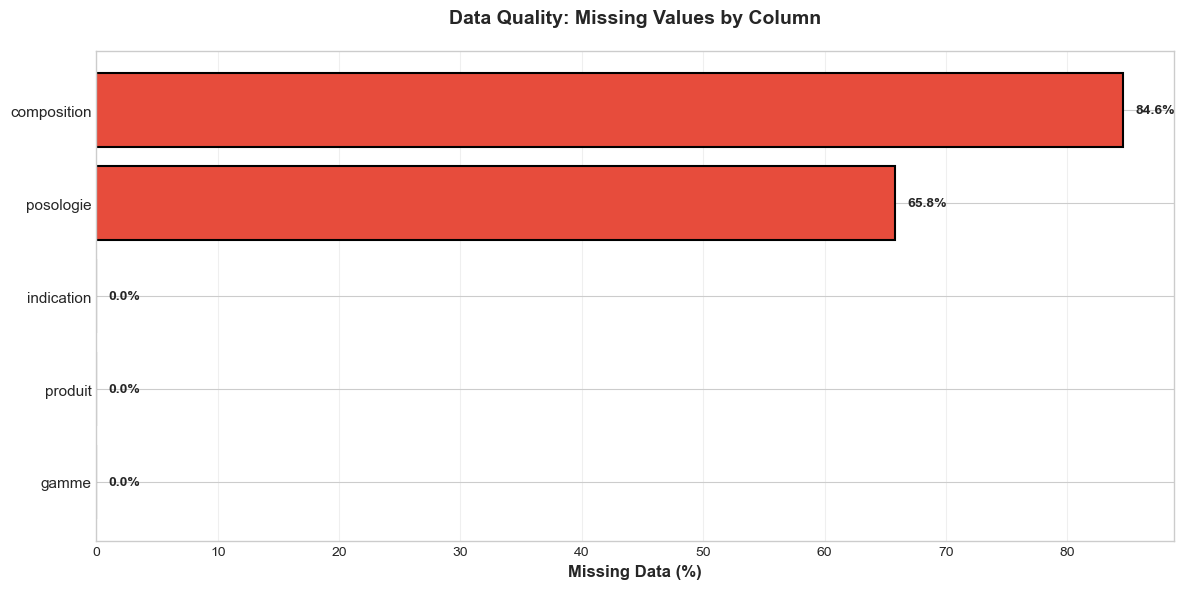

In [5]:
# VIZ 1: MISSING DATA BY COLUMN
# ============================================================================

fig, ax = plt.subplots(figsize=(12, 6))

missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=True)
colors = ['#2ecc71' if x < 10 else '#f39c12' if x < 50 else '#e74c3c' for x in missing_pct.values]

bars = ax.barh(range(len(missing_pct)), missing_pct.values, color=colors, edgecolor='black', linewidth=1.5)
ax.set_yticks(range(len(missing_pct)))
ax.set_yticklabels(missing_pct.index, fontsize=11)
ax.set_xlabel('Missing Data (%)', fontsize=12, weight='bold')
ax.set_title('Data Quality: Missing Values by Column', fontsize=14, weight='bold', pad=20)
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, (bar, value) in enumerate(zip(bars, missing_pct.values)):
    ax.text(value + 1, i, f'{value:.1f}%', va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

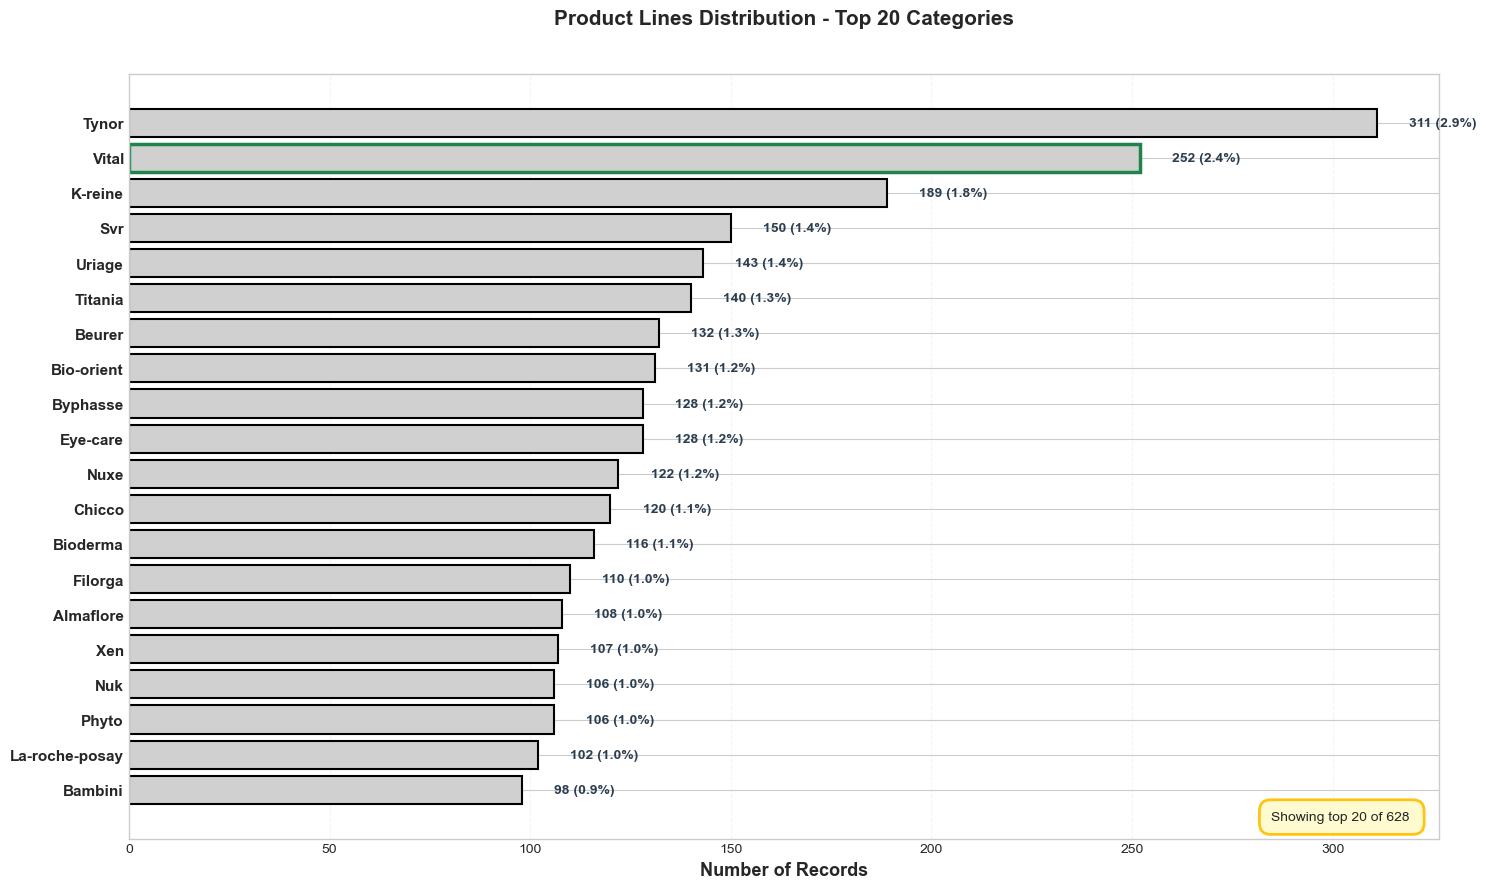

In [7]:
# ============================================================================
# VIZ 2: GAMME DISTRIBUTION - FINAL CORRECTED VERSION
# ============================================================================

fig, ax = plt.subplots(figsize=(15, 9))

if 'gamme' in df.columns:
    gamme_dist = df['gamme'].value_counts()

    # Auto-switch chart type based on number of categories
    if len(gamme_dist) <= 5:
        # PIE CHART for ≤5 categories
        colors = ['#27ae60' if x == 'VITAL' else plt.cm.Set3(i/len(gamme_dist)) for i, x in enumerate(gamme_dist.index)]
        explode = [0.15 if x == 'VITAL' else 0 for x in gamme_dist.index]

        wedges, texts, autotexts = ax.pie(
            gamme_dist.values,
            labels=gamme_dist.index,
            autopct='%1.1f%%',
            colors=colors,
            explode=explode,
            startangle=90,
            textprops={'fontsize': 12, 'weight': 'bold'}
        )

        for autotext in autotexts:
            autotext.set_color('white')
            autotext.set_fontsize(11)
            autotext.set_weight('bold')

        ax.set_title('Product Lines Distribution\n',
                     fontsize=15, weight='bold', pad=20)
    else:
        # BAR CHART for >5 categories - FINAL VERSION
        # Get top 19 + ensure VITAL is included
        top_19 = gamme_dist.head(19)

        # Add VITAL if not in top 19
        if 'VITAL' in gamme_dist.index and 'VITAL' not in top_19.index:
            vital_count = gamme_dist['VITAL']
            top_20 = pd.concat([top_19, pd.Series({'VITAL': vital_count})])
        else:
            top_20 = gamme_dist.head(20)

        top_20 = top_20.sort_values(ascending=True)

        # ============================================================================
        # KEY FIX: VITAL bar is BRIGHT GREEN, others are LIGHT GRAY
        # ============================================================================
        colors = ['#27ae60' if x == 'VITAL' else '#d0d0d0' for x in top_20.index]

        # Create bars with black outline
        bars = ax.barh(range(len(top_20)), top_20.values,
                      color=colors, edgecolor='black', linewidth=1.5)

        # Make VITAL bar even more prominent with thicker border
        for i, (bar, label) in enumerate(zip(bars, top_20.index)):
            if label == 'Vital':
                bar.set_edgecolor('#1e8449')  # Darker green border
                bar.set_linewidth(2.5)

        # Y-axis labels
        ax.set_yticks(range(len(top_20)))
        ax.set_yticklabels(top_20.index, fontsize=11, weight='bold')

        # X-axis
        ax.set_xlabel('Number of Records', fontsize=13, weight='bold')
        ax.set_title('Product Lines Distribution - Top 20 Categories\n',
                     fontsize=15, weight='bold', pad=20)

        # Grid for readability
        ax.grid(axis='x', alpha=0.2, linestyle='--', linewidth=0.8)
        ax.set_axisbelow(True)

        # ============================================================================
        # VALUE LABELS - Right-aligned
        # ============================================================================
        for i, (bar, value) in enumerate(zip(bars, top_20.values)):
            pct = (value / gamme_dist.sum() * 100)
            label_text = f'{value:,} ({pct:.1f}%)'

            # Position labels to the right of bars
            ax.text(value + 8, i, label_text, va='center', fontsize=10,
                   weight='bold', color='#2c3e50')

        # ============================================================================
        # INFO BOX - Bottom right corner
        # ============================================================================
        if len(gamme_dist) > 20:
            info_text = f'Showing top 20 of {len(gamme_dist)} '
            ax.text(0.98, 0.02, info_text,
                   transform=ax.transAxes, fontsize=10, ha='right', va='bottom',
                   bbox=dict(boxstyle='round,pad=0.8', facecolor='#fffacd',
                            alpha=0.95, edgecolor='#ffc107', linewidth=2))

else:
    ax.text(0.5, 0.5, 'Gamme column not found', ha='center', va='center', fontsize=12)
    ax.set_title('Product Lines Distribution', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

In [9]:
# NLP libraries
import spacy
from spacy.lang.fr.stop_words import STOP_WORDS as FR_STOP_WORDS
from nltk.stem.snowball import SnowballStemmer
import nltk
import unicodedata
from collections import Counter, defaultdict
# Download required NLTK data
nltk.download('punkt', quiet=True)

# Load spaCy French model
try:
    nlp_fr = spacy.load("fr_core_news_sm")
except OSError:
    print("⚠ Installing French spaCy model...")
    import os
    os.system("python -m spacy download fr_core_news_sm")
    nlp_fr = spacy.load("fr_core_news_sm")

print("✓ All NLP libraries loaded successfully!")

# Initialize French stemmer
stemmer = SnowballStemmer("french")

✓ All NLP libraries loaded successfully!


In [11]:
# ============================================================================
# ÉTAPE PRÉALABLE : CRÉATION DE LA COLONNE 'full_text'
# ============================================================================

# Vérifions que les colonnes nécessaires existent
required_cols = ['produit', 'indication', 'posologie']
for col in required_cols:
    if col not in df.columns:
        print(f"⚠️ Attention : La colonne '{col}' n'existe pas dans le DataFrame.")
        # Créer une colonne vide si elle n'existe pas pour éviter l'erreur
        df[col] = ""

# Combiner les textes
df['full_text'] = (
    df['produit'].fillna('') + ' ' +
    df['indication'].fillna('') + ' ' +
    df['posologie'].fillna('')
)

# Nettoyage de base pour enlever les retours à la ligne et espaces multiples
df['full_text'] = df['full_text'].str.replace('\n', ' ').str.replace('\r', ' ')
df['full_text'] = df['full_text'].str.replace(r'\s+', ' ', regex=True).str.strip()

print("✓ Colonne 'full_text' créée avec succès.")
print(f"   Exemple de texte : {df['full_text'].iloc[0][:100]}...")

✓ Colonne 'full_text' créée avec succès.
   Exemple de texte : Aromessence Piedarom Baume 50 ml Baume pour les pieds Contenance de 50 ml Marque Aromessence Idéal p...


In [13]:
# ============================================================================
# SECTION: NLP Symptom Extraction with spaCy (AVEC LEMMATISATION)
# ============================================================================
import spacy
from spacy.matcher import PhraseMatcher

# 1. Charger le modèle COMPLET (lemmatizer activé)
#    On peut quand même désactiver parser et ner pour accélérer un peu
nlp = spacy.load("fr_core_news_md", disable=["parser", "ner"])
print("✓ Modèle spaCy COMPLET chargé (avec lemmatizer).")

# 2. Définir le dictionnaire enrichi de symptômes
# ============================================================================
# DICTIONNAIRE DE SYMPTÔMES - VERSION FINALE ET COMPLÈTE
# ============================================================================

enriched_symptom_phrases = {
    # =========================================================================
    # PEAU & VISAGE
    # =========================================================================
    "Acné": [
        "acné", "bouton", "imperfection", "point noir", "peau grasse", "anti-acné", "comédon",
        "teen", "jeune peau", "peau à problème", "acnéique", "sébum", "purifiant", "désincrustant"
    ],
    "Peau sèche": [
        "peau sèche", "peau très sèche", "déshydraté", "tiraillement", "rugosité", "peau atopique", "eczéma",
        "sécheresse cutanée", "inconfort", "peau sensible", "apaisant", "relipidant", "surgras","hydratation cutanée", "purifie la peau", "restaure l'hydratation","hydratation", "nutrition de la peau", "hydrafine", "après épilation", "peau sensibilisée"
    ],
    "Taches pigmentaires": [
        "tache brune", "hyperpigmentation", "mélasma", "anti-tache", "éclaircissant", "dépigmentant",
        "tache de vieillesse", "teint terne", "unifier le teint", "teint irrégulier", "tache pigmentaire","tc2000", "nutractiva", "effet éclaircissant", "tâches brunes"
    ],
    "Rides/Anti-âge": [
        "ride", "ridule", "anti-âge", "anti-ride", "vieillissement", "fermeté", "liftant", "raffermissant",
        "repulpant", "relâchement cutané", "peau mature", "collagène", "élastine", "contour des yeux", "regard"
    ],
    "Cernes/Poches": [
        "cerne", "poche", "contour des yeux", "anti-cerne", "regard fatigué", "poche sous les yeux", "décongestionnant"
    ],
    "Cicatrices": [
        "cicatrice", "cicatrisant", "marque post-acné", "réparateur cutané", "brûlure", "plaie", "régénérant"
    ],
    "Rougeurs": [
        "rougeur", "rosacée", "couperose", "anti-rougeur", "irritation", "peau réactive", "erythrose"
    ],
    "Vergetures": [
        "vergeture", "anti-vergeture", "grossesse"
    ],
    "Lèvres sèches/gercées": [
        "lèvre sèche", "lèvre gercée", "lèvre abîmée", "lèvre fragilisée", "baume à lèvre", "stick lèvre",
        "gerçure", "dessèchement des lèvre", "lèvre déshydratée", "protège les lèvre"
    ],
    "Protection solaire": [
        "protection solaire", "écran solaire", "spf", "coup de soleil", "exposition au soleil", "rayon uv",
        "photovieillissement", "tache solaire", "indice de protection", "filtre uv","hydrascreen", "huile solaire", "pailletée", "protège la peau", "uva", "uvb"
    ],
    "Nettoyage visage": [  # Nouvelle catégorie (besoin fonctionnel)
        "gel nettoyant", "nettoyage quotidien", "nettoyant visage"
    ],
    "Piqûres d'insectes": [  # Nouvelle catégorie
        "moustik", "piqûre", "insecte", "anti-moustique"
    ],
    # =========================================================================
    # CHEVEUX & CUIR CHEVELU
    # =========================================================================
    "Chute de cheveux": [
        "chute de cheveu", "perte de cheveu", "anti-chute", "alopécie", "cheveu clairsemé", "fortifiant capillaire",
        "repousse", "densité"
    ],
    "Pellicules": [
        "pellicule", "antipelliculaire", "squame", "démangeaison cuir chevelu", "cuir chevelu irrité", "pityriasis"
    ],
    "Cheveux secs/abîmés": [
        "cheveu sec", "cheveu abîmé", "cheveu cassant", "pointe fourchue", "réparateur cheveu", "nutrition cheveu",
        "cheveu terne", "cheveu dévitalisé", "reconstituant", "restructurant", "fibre capillaire abîmée",
        "réparateur", "réparer","phytophane", "brillance", "souplesse des cheveux", "hydratation des cheveux"
    ],
    "Cheveux gras": [
        "cheveu gras", "excès de sébum", "séborrhéique", "cuir chevelu gras", "cheveu regraisser vite"
    ],
    "Cheveux blancs": [
        "cheveu blanc", "cheveu gris", "anti-cheveu blanc", "repigmentant"
    ],
    "Poux": [
        "pou", "lente", "anti-pou"
    ],
    "Coiffage/Fixation": [
        "gel fixant", "fixation", "coiffage", "laque", "coiffant"
    ],

    # =========================================================================
    # CORPS & PIEDS
    # =========================================================================
    "Pieds secs/Crevasses": [
        "pied sec", "callosité", "crevasse", "corne", "pied abîmé", "talon fendillé", "durillon"
    ],
    "Mains sèches": [
        "main sèche", "main abîmée", "main gercée", "crème main", "cuticule"
    ],
    "Jambes lourdes": [
        "jambe lourde", "circulation", "jambe fatiguée", "rétention d'eau", "varice", "insuffisance veineuse"
    ],
    "Cellulite": [
        "cellulite", "capiton", "peau d'orange", "amincissant corps"
    ],
    "Douleurs musculaires/articulaires": [
        "douleur musculaire", "courbature", "torticolis", "contracture", "entorse", "arthrose", "confort articulaire",
        "cartilage", "rhumatisme", "articulation", "tendinite", "lombalgie", "soulage les douleur","arthroforce", "douleur articulaire", "douleurs articulaires"
    ],
    "Douleurs menstruelles": [
        "règle douloureuse", "dysménorrhée", "bouillotte", "douleur pelvienne"
    ],
    "Transpiration": [
        "transpiration", "anti-transpirant", "déodorant", "odeur corporelle", "main moite", "pied qui transpire"
    ],
    "Odeurs corporelles": [
        "anti odeur", "mauvaise odeur", "désodorisant", "odeur de transpiration"
    ],
    "Verrues": [
        "verrue", "anti-verrue", "verrue plantaire"
    ],
    "Mycose des ongles": [
        "mycose des ongle", "onychomycose", "ongle jaune", "ongle épaissi"
    ],
    "Incontinence": [
        "incontinence", "fuite urinaire", "protection urinaire", "alèse", "change adulte"
    ],

    # =========================================================================
    # SANTÉ & BIEN-ÊTRE
    # =========================================================================
    "Digestion": [
        "digestion", "ballonnement", "confort intestinal", "brûlure d'estomac", "reflux", "transit", "constipation","spasvit", "spasmes digestifs", "spasme",
        "gaz", "nausée", "vomissement", "mal d'estomac", "difficulté digestive","stimule l'appétit", "prise de poids", "grossivit""antiacide", "acidité estomac", "équilibre acido-basique", "appétit croissance", "stimule appétit", "appétit"
    ],
    "Fatigue": [
        "fatigue", "manque d'énergie", "tonus", "vitalité", "épuisement", "coup de fouet", "baisse de forme", "asthénie","coenzyme q10", "performances physiques", "coq10", "ubiquinone"
    ],
    "Développement cérébral": [  # Nouvelle catégorie
        "omega3", "oméga 3", "développement cérébral", "cerveau"
    ],
    "Stress/Sommeil": [
        "stress", "anxiété", "nervosité", "sommeil", "insomnie", "détente", "apaisant", "angoisse", "mélatonine",
        "endormissement", "réveil nocturne"
    ],
    "Immunité": [
        "immunité", "défense naturelle", "système immunitaire", "résistance", "coup de froid", "rhume", "grippe","anti-grippal", "apigrip","immunovit", "stimulation immunitaire",
        "plantex", "état grippal", "prévention grippe","spiruline", "immunostimulant"

    ],
    "Minceur": [
        "perte de poids", "minceur", "brûle graisse", "coupe-faim", "draineur", "amincissant", "régime","vinaigre de figue de barbarie", "perdre du poids","pectine de pomme", "coupe faim"
    ],
    "Maux de gorge": [
        "mal de gorge", "toux", "gorge irritée", "voie respiratoire", "pastille gorge", "angine", "enrouement","angine", "inflammation gorge", "apigorge", "angine gorge", "angiplant","calmoss", "gorge", "pastille gorge"
    ],
    "Fertilité": [
        "fertilité", "conception", "grossesse", "désir d'enfant", "procréation"
    ],
    "Bébé/Change": [
        "érythème fessier", "change bébé", "croûte de lait", "liniment", "poussée dentaire", "colique nourrisson","coligaz", "coliques bébé", "colique nourrisson", "gaz bébé", "crème pour le change", "érythème fessier", "change bébé", "gripe water", "flatulences bébé", "flatulence"
    ],
    "Accessoires bébé": [
        "sucette", "tétine", "biberon"
    ],
    "Hygiène intime": [
        "hygiène intime", "mycose vaginale", "sécheresse intime", "démangeaison intime","vitonic mémoire", "concentration", "mémoire"
    ],
    "Hygiène bucco-dentaire": [
        "plaque dentaire", "santé des gencive", "gencive sensible", "saignement gingival", "brosse à dent", "fil dentaire",
        "carie", "haleine fraîche", "blanchiment dentaire", "dentifrice"
    ],
    "Douleurs dentaires": [
        "douleur dentaire", "aphte", "poussée dentaire bébé", "gel gingival","calmo dent", "mal des dents", "douleur dent"
    ],
    "Santé des os": [
        "calcium", "santé des os", "ostéoporose", "fracture", "solidité osseuse", "dent solide", "vitamine d3", "minéralisation","vitonic croissance", "développement osseux", "croissance enfant"
    ],
    "Carences nutritionnelles": [
        "carence", "complément alimentaire", "multivitamine", "fer", "magnésium", "zinc", "vitamine", "oligo-élément", "selenium", "ace", "anti oxydant", "oligovit", "vit.e", "vitamine e", "cardio protecteur", "antioxydant", "vitonic senior", "besoins nutritionnels des seniors", "senior"
    ],
    "Santé cardiovasculaire": [
        "cholestérol", "tension artérielle", "hypertension", "cœur", "circulation sanguine", "oméga 3"
    ],
    "Santé de la prostate": [
        "prostate", "confort urinaire", "hypertrophie bénigne de la prostate"
    ],
    "Ménopause": [
        "ménopause", "bouffée de chaleur", "sécheresse vaginale ménopause","soya", "ménopause", "bouffées de chaleur"
    ],
    "Allergies": [
        "allergie", "rhinite allergique", "antihistaminique", "pollen", "acarien"
    ],
    "Sevrage tabagique": [
        "arrêter de fumer", "tabac", "nicotine", "substitut nicotinique"
    ],
    "Infections cutanées": [  # Nouvelle catégorie
        "antiseptique cutané", "eosine", "dermalo", "antiseptique peau", "vitosine"
    ],
    "Rétention d'eau": [  # Nouvelle catégorie
        "rétention d'eau", "jambes gonflées", "mincivit"
    ],
    "Mycoses cutanées": [  # Nouvelle catégorie
        "fongiderm", "antifongique", "mycose peau", "savon antifongique"
    ],
     "Anémie": [  # Nouvelle catégorie
        "ferbiotic", "anémie", "ferriprive", "carence en fer"
    ],
    "Hémorroïdes": [  # Nouvelle catégorie
        "hemostop", "hémorroïde", "crise hémorroïdaire"
    ],
    "Nez bouché / Rhume": [ # Nouvelle catégorie
        "apinez", "nez bouché", "rhinite", "décongestionnant nasal","spray nasal", "nettoyage muqueuse nasale", "narine","rhinoplant", "désobstruction nasale", "nettoyage des muqueuses"

    ],
    "Migraine": [ # Nouvelle catégorie
        "migrainal", "migraine", "céphalée", "mal de tête"
    ],
     "Dépression / Humeur": [  # Nouvelle catégorie
        "millepertuis", "améliore l'humeur", "antidépresseur naturel", "moral","omevie emotion", "humeur équilibrée", "équilibre émotionnel", "déclin cognitif", "dépression"
    ],
    "Libido / Performance sexuelle": [  # Nouvelle catégorie
        "stimulplus", "libido", "performances sexuelles", "désir sexuel", "aphrodisiaque"
    ],
     "Bouche sèche": [  # Nouvelle catégorie
        "phytol", "bain de bouche", "xérostomie", "bouche sèche", "muqueuse buccale"
    ],
    "Désinfection / Antiseptique": [  # Nouvelle catégorie
        "bactol", "savon désinfectant", "spray désinfectant", "gel désinfectant"
    ],
    "Peau mixte": [  # Nouvelle catégorie
        "uniderm", "peau mixte", "unifiant"
    ],
    "Hygiène bucco-dentaire": [
        "bain de bouche antiseptique", "assainissement", "résidus alimentaires"
    ],
    "Peau sensible bébé": [  # Nouvelle catégorie
        "savon extra doux", "peau bébé"
    ],
    "Varicelle": [  # Nouvelle catégorie
        "pédiakids", "varispray", "varicelle", "apaiser varicelle"
    ],
    "Système nerveux": [  # Nouvelle catégorie
        "tetra b", "système nerveux"
    ],

}

print(f"✓ Dictionnaire final créé avec {len(enriched_symptom_phrases)} catégories de symptômes.")

# 3. Initialiser le PhraseMatcher avec LEMMA
matcher = PhraseMatcher(nlp.vocab, attr="LEMMA")
print("✓ PhraseMatcher initialisé en mode LEMMA.")

# 4. Ajouter les patterns en utilisant nlp() (pipeline complet)
print("⏳ Préparation des patterns avec lemmatisation...")
for symptom, phrases in enriched_symptom_phrases.items():
    patterns = [nlp(phrase) for phrase in phrases]  # <-- nlp() au lieu de nlp.make_doc()
    matcher.add(symptom, patterns)

print(f"✓ {len(enriched_symptom_phrases)} symptômes ajoutés au matcher.")

# 5. Fonction d'extraction avec lemmatisation
def extract_symptoms_spacy_lemmatized(text):
    if not isinstance(text, str) or len(text.strip()) == 0:
        return []

    # On passe le texte dans le pipeline complet (lemmatisation incluse)
    doc = nlp(text.lower())
    matches = matcher(doc)

    symptoms = set()
    for match_id, start, end in matches:
        symptom = nlp.vocab.strings[match_id]
        symptoms.add(symptom)
    return list(symptoms)

# 6. Application sur le DataFrame
print("\n⏳ Extraction des symptômes (v3 avec lemmatisation) en cours...")
print("   (Cette étape peut prendre 2-3 minutes pour 10k produits)")
df['symptoms_spacy_lemmatized'] = df['full_text'].apply(extract_symptoms_spacy_lemmatized)
print("✓ Extraction terminée !")

# 7. Analyse rapide des résultats
total = len(df)
with_symptoms = df[df['symptoms_spacy_lemmatized'].apply(len) > 0].shape[0]
print(f"\n📊 Résultats de l'extraction avec lemmatisation :")
print(f"   • Produits avec symptômes : {with_symptoms} / {total} ({with_symptoms/total:.1%})")

✓ Modèle spaCy COMPLET chargé (avec lemmatizer).
✓ Dictionnaire final créé avec 65 catégories de symptômes.
✓ PhraseMatcher initialisé en mode LEMMA.
⏳ Préparation des patterns avec lemmatisation...
✓ 65 symptômes ajoutés au matcher.

⏳ Extraction des symptômes (v3 avec lemmatisation) en cours...
   (Cette étape peut prendre 2-3 minutes pour 10k produits)
✓ Extraction terminée !

📊 Résultats de l'extraction avec lemmatisation :
   • Produits avec symptômes : 7965 / 10553 (75.5%)



 STATISTIQUES GLOBALES:
   • Total produits analysés : 10,553
   • Produits avec au moins 1 symptôme : 7,965 (75.5%)
   • Produits sans symptôme détecté : 2,588 (24.5%)

 NOMBRE DE SYMPTÔMES PAR PRODUIT:
   • Moyenne : 1.57
   • Maximum : 9
   • Médiane : 1


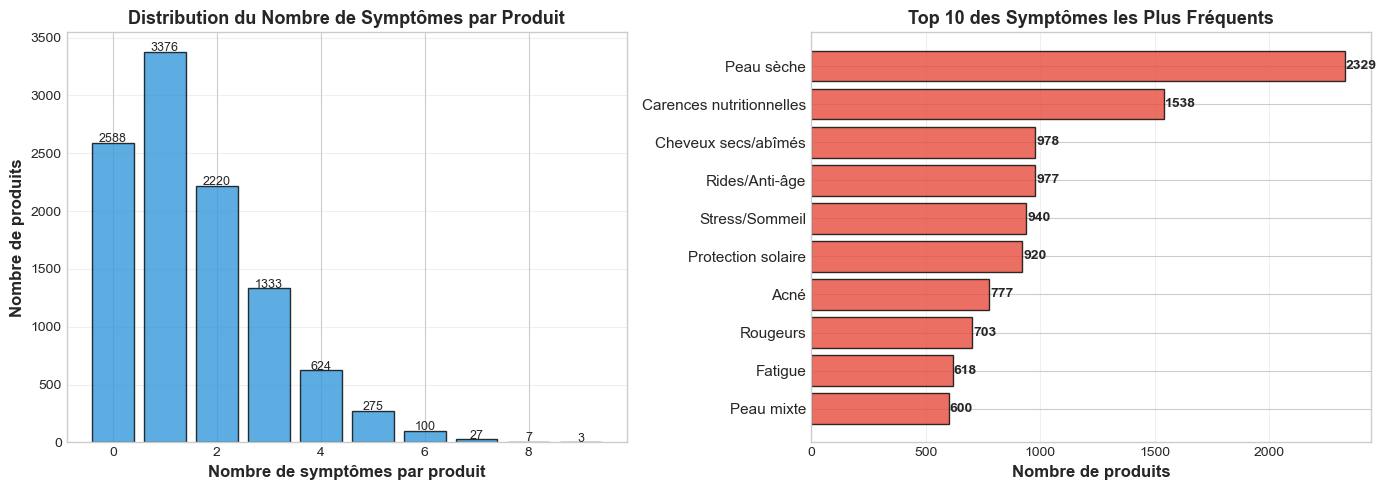


 EXEMPLES DE PRODUITS AVEC SYMPTÔMES (SUCCÈS)

  Produit : Novaclear Collagen Creme De Jour 50ml...
   ➜ Symptômes détectés : Rides/Anti-âge, Cicatrices, Carences nutritionnelles

  Produit : OMEVIE ARTICULATION...
   ➜ Symptômes détectés : Douleurs musculaires/articulaires

  Produit : OLIGOVIT SÉLÉNIUM...
   ➜ Symptômes détectés : Immunité, Carences nutritionnelles, Stress/Sommeil

  Produit : Soskin Gel Doux Nettoyant Purifiant 500ml...
   ➜ Symptômes détectés : Cheveux secs/abîmés, Acné, Peau mixte

  Produit : Bio Gatrana Spiruline Biologique   45 Gélules...
   ➜ Symptômes détectés : Immunité, Hygiène intime


In [15]:
# 1. Statistiques générales
total_products = len(df)
products_with_symptoms = df[df['symptoms_spacy_lemmatized'].apply(len) > 0].shape[0]
products_without_symptoms = total_products - products_with_symptoms

print(f"\n STATISTIQUES GLOBALES:")
print(f"   • Total produits analysés : {total_products:,}")
print(f"   • Produits avec au moins 1 symptôme : {products_with_symptoms:,} ({products_with_symptoms/total_products:.1%})")
print(f"   • Produits sans symptôme détecté : {products_without_symptoms:,} ({products_without_symptoms/total_products:.1%})")

# 2. Distribution du nombre de symptômes par produit
symptom_counts_per_product = df['symptoms_spacy_lemmatized'].apply(len)
print(f"\n NOMBRE DE SYMPTÔMES PAR PRODUIT:")
print(f"   • Moyenne : {symptom_counts_per_product.mean():.2f}")
print(f"   • Maximum : {symptom_counts_per_product.max()}")
print(f"   • Médiane : {symptom_counts_per_product.median():.0f}")

# Visualisation
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Graphique 1 : Distribution
ax1 = axes[0]
count_dist = symptom_counts_per_product.value_counts().sort_index()
bars = ax1.bar(count_dist.index, count_dist.values, color='#3498db', edgecolor='black', alpha=0.8)
ax1.set_xlabel('Nombre de symptômes par produit', fontsize=12, weight='bold')
ax1.set_ylabel('Nombre de produits', fontsize=12, weight='bold')
ax1.set_title('Distribution du Nombre de Symptômes par Produit', fontsize=13, weight='bold')
ax1.grid(axis='y', alpha=0.3)
for bar, val in zip(bars, count_dist.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5, str(val), ha='center', fontsize=9)

# Graphique 2 : Top Symptômes
ax2 = axes[1]
all_symptoms = df['symptoms_spacy_lemmatized'].explode().dropna()
top_symptoms = all_symptoms.value_counts().head(10)
bars = ax2.barh(range(len(top_symptoms)), top_symptoms.values, color='#e74c3c', edgecolor='black', alpha=0.8)
ax2.set_yticks(range(len(top_symptoms)))
ax2.set_yticklabels(top_symptoms.index, fontsize=11)
ax2.set_xlabel('Nombre de produits', fontsize=12, weight='bold')
ax2.set_title('Top 10 des Symptômes les Plus Fréquents', fontsize=13, weight='bold')
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)
for i, (bar, val) in enumerate(zip(bars, top_symptoms.values)):
    ax2.text(val + 5, i, str(val), va='center', fontsize=10, weight='bold')

plt.tight_layout()
plt.show()

# 3. Exemples de produits AVEC symptômes (succès)
print("\n" + "="*60)
print(" EXEMPLES DE PRODUITS AVEC SYMPTÔMES (SUCCÈS)")
print("="*60)
sample_success = df[df['symptoms_spacy_lemmatized'].apply(len) > 0].sample(min(5, products_with_symptoms), random_state=42)
for idx, row in sample_success.iterrows():
    print(f"\n  Produit : {row['produit'][:60]}...")
    print(f"   ➜ Symptômes détectés : {', '.join(row['symptoms_spacy_lemmatized'])}")

In [21]:
# ============================================================================
# ANALYSE DES PRODUITS 'VITAL' SANS SYMPTÔME
# ============================================================================

# Filtrer les produits de gamme 'Vital' sans symptôme
vital_no_symptoms = df[(df['gamme'] == 'Vital') & (df['symptoms_spacy_lemmatized'].apply(len) == 0)]

print(f" Produits 'Vital' sans symptôme : {len(vital_no_symptoms)}")
print("\n Échantillon de 10 produits 'Vital' sans symptôme :")
for idx, row in vital_no_symptoms.sample(min(10, len(vital_no_symptoms)), random_state=42).iterrows():
    print(f"\n  {row['produit'][:70]}...")
    print(f"    Texte : {row['full_text'][:200]}...")

 Produits 'Vital' sans symptôme : 0

 Échantillon de 10 produits 'Vital' sans symptôme :


In [23]:
# ============================================================================
# EXPORT DES PRODUITS AVEC SYMPTÔMES VERS EXCEL
# ============================================================================

# 1. Filtrer uniquement les produits qui ont des symptômes
df_with_symptoms = df[df['symptoms_spacy_lemmatized'].apply(len) > 0].copy()

print(f"\n Produits avec symptômes : {len(df_with_symptoms)} / {len(df)} ({len(df_with_symptoms)/len(df):.1%})")

# 2. Sélectionner les colonnes pertinentes pour l'export
columns_to_export = [
    'gamme',           # Catégorie de produit (Premium, Essentiel, etc.)
    'produit',         # Nom du produit
    'indication',      # Indication originale
    'posologie',       # Posologie originale
    'symptoms_spacy_lemmatized'  # Symptômes extraits
]

# Vérifier que toutes les colonnes existent
available_columns = [col for col in columns_to_export if col in df_with_symptoms.columns]
df_export = df_with_symptoms[available_columns].copy()

# 3. Convertir la liste des symptômes en chaîne de caractères (pour Excel)
df_export['symptoms_spacy_lemmatized'] = df_export['symptoms_spacy_lemmatized'].apply(lambda x: ', '.join(x) if isinstance(x, list) else '')

# 4. Sauvegarder en Excel
output_path = 'produits_avec_symptomes.xlsx'
df_export.to_excel(output_path, index=False, sheet_name='Produits_Symptomes')

print(f"\n Fichier Excel exporté avec succès : '{output_path}'")
print(f"   • {len(df_export)} produits exportés")
print(f"   • Colonnes incluses : {', '.join(available_columns)}")

# 5. Aperçu du fichier exporté
print("\n📋 Aperçu des 10 premiers produits exportés :")
display(df_export.head(10))


 Produits avec symptômes : 7965 / 10553 (75.5%)

 Fichier Excel exporté avec succès : 'produits_avec_symptomes.xlsx'
   • 7965 produits exportés
   • Colonnes incluses : gamme, produit, indication, posologie, symptoms_spacy_lemmatized

📋 Aperçu des 10 premiers produits exportés :


,gamme,produit,indication,posologie,symptoms_spacy_lemmatized
0,Aromessence,Aromessence Piedarom Baume 50 ml,Baume pour les pieds\n\n\nContenance de 50 ml\...,NaN,Peau sèche
1,Bielenda,Bielenda Mask Black Sugar Detox 2En1,Masque purifiant\n\n\nÉlimine les impuretés\n\...,NaN,Acné
2,Michel-pierre,Michel Pierre Reflustop Dose De 10ml Boite 20 ...,Apaise brûlures d’estomac et reflux\n\n\nProtè...,NaN,"Carences nutritionnelles, Digestion, Cicatrices"
3,Michel-pierre,Michel Pierre Digest Express 14 Sticks De 10ml,Aide à réduire ballonnements et gaz\n\n\nFavor...,NaN,"Carences nutritionnelles, Digestion"
4,Moline,Vasy Gel Lubrifiant 100 ml,Gel lubrifiant à base d’eau purifiée\n\n\nCont...,NaN,"Peau sèche, Carences nutritionnelles, Stress/S..."
5,Moline,Moline Gel Lavant 250ml,MOLINE GEL LAVANT 250ML\n\n\nNe pique pas les ...,"ORIGINE : Tunisie\nCOMPOSITION : AQUA, Glyceri...",Peau sèche
11,Moline,Moline Liniment Oléo-Calcaire 500ml,Le Liniment Oléo-calcaire Moline\n\n\nUn soin ...,Poids : 0.05 kg,"Rougeurs, Bébé/Change"
12,Moline,Moline Liniment Oléo-Calcaire 200ml,Le Liniment Oléo-calcaire Moline\n\n\nUn soin ...,Poids : 0.05 kg,"Rougeurs, Bébé/Change"
14,Moline,Moline Huile Antivergetures 50ml,MOLINE HUILE ANTIVERGETURES 50ML\n\n\nPrévient...,ORIGINE : Tunisie\nCONDITIONNEMENT : Flacon de...,Vergetures
16,Nutravit,NUTRAVIT OMEGAPRO JUNIOR SIROP 120ML,Oméga 3 junior goût mangue agréable\n\n\nSans ...,NaN,"Santé cardiovasculaire, Développement cérébral"


In [25]:
df_produits_avec_symptomes = pd.read_excel('produits_avec_symptomes.xlsx')
print(f" Fichier chargé : {len(df_produits_avec_symptomes)} produits")

 Fichier chargé : 7965 produits


In [27]:
# ============================================================================
# DICTIONNAIRE EXHAUSTIF DES FORMES GALÉNIQUES (CORRIGÉ - TOUT EN MINUSCULES)
# ============================================================================

exhaustive_form_keywords = {
    # Formes solides orales
    "Comprimé / Gélule": [
        "comprimé", "comprimés", "cp", "cpr", "tablet", "tablette", "comprimes", "comprime",
        "pastille", "pastilles", "gélule", "gélules", "gelule", "gelules", "capsule", "capsules",
        "cap", "caps", "cachet", "cachets", "pilule", "pilules", "softgel", "softgels",
        "comprimé effervescent", "comprimé orodispersible", "comprimé à croquer",
        "gélule végétale", "gélule gastro-résistante","multi vitamines"
    ],

    # Formes liquides orales
    "Sirop / Suspension buvable": [
        "sirop", "suspension buvable", "solution buvable", "buvable", "ampoule buvable",
        "flacon", "gouttes", "goutte", "soluté", "elixir", "élixir", "suspension",
        "émulsion buvable", "sirop sans sucre", "sirop enfant", "solution orale",
        "coligaz","appétit croissance"  # <- EN MINUSCULE
    ],

    # Formes topiques semi-solides
    "Crème": [
        "crème", "creme", "cold cream", "crème de jour", "crème de nuit", "crème visage",
        "crème corps", "crème mains", "crème pieds", "crème solaire", "crème teintée",
        "crème hydratante", "crème nourrissante", "crème réparatrice", "crème apaisante",
        "crème anti-rides", "crème anti-taches", "crème éclaircissante", "crème dépigmentante",
        "uniderm écran solaire", "mincivit lift cafeine", "hydrascreen aftersun",
        "hydravera", "hydrafine apres epilation", "hydrafine antibrulure", "hydra",
        "dermadouce", "dermalo"  # <- TOUT EN MINUSCULE
    ],

    "Pommade / Baume": [
        "pommade", "baume", "onguent", "cérat", "beurre corporel", "body butter",
        "baume à lèvres", "stick lèvres", "baume réparateur", "baume apaisant",
        "vaseline", "vaseline salicylée", "vaseline glycérinée", "vitosine vaseline salicylée"
    ],

    "Gel": [
        "gel", "gelée", "gelee", "gel douche", "gel lavant", "gel nettoyant", "gel moussant",
        "gel hydroalcoolique", "gel désinfectant", "gel intime", "gel capillaire",
        "gel coiffant", "gel fixant", "gel contour des yeux", "gel anti-acné"
    ],

    "Lait / Lotion": [
        "lait", "lotion", "lait corporel", "lait hydratant", "lait de toilette",
        "lait démaquillant", "lait solaire", "lotion tonique", "lotion micellaire",
        "tonique", "tonic", "eau micellaire", "micellaire", "liniment",
        "vitosine eosine", "vitosine eosine aqueuse", "vitosine eosine alcoolisée"
    ],

    "Sérum": [
        "sérum", "serum", "concentré", "concentre", "booster", "essence",
        "sérum visage", "sérum anti-âge", "sérum hydratant", "ampoule", "ampoules"
    ],

    "Huile": [
        "huile", "huile sèche", "huile de massage", "bain d'huile", "huile de douche",
        "huile lavante", "huile démaquillante", "huile capillaire", "huile visage",
        "huile corps", "huile solaire", "huile bronzante"
    ],

    # Formes pour les cheveux
    "Shampooing": [
        "shampooing", "shampoing", "shampooin", "shampooing sec", "shampoing traitant",
        "shampoing anti-chute", "shampoing antipelliculaire", "shampoing réparateur"
    ],

    "Après-shampooing / Masque capillaire": [
        "après-shampooing", "après shampoing", "conditionneur", "conditioner",
        "masque capillaire", "masque cheveux", "soin capillaire", "démêlant"
    ],

    # Formes pour l'hygiène
    "Savon / Pain": [
        "savon", "pain", "syndet", "pain dermatologique", "savon liquide", "savon solide",
        "savon surgras", "savon antiseptique", "savon doux", "dermasoufre", "argiderm"
    ],

    "Dentifrice": [
        "dentifrice", "pâte dentifrice", "gel dentifrice", "pâte à dents"
    ],

    "Bain de bouche": [
        "bain de bouche", "solution buccale", "rinçage buccal"
    ],

    # Formes aérosols
    "Spray / Brume": [
        "spray", "brume", "vaporisateur", "aérosol", "aerosol", "pulvérisateur",
        "atomiseur", "spray nasal", "spray buccal", "spray solaire", "brume parfumée"
    ],

    # Formes diverses
    "Poudre": [
        "poudre", "poudré", "talque", "poudre libre", "poudre compacte", "poudre de toilette"
    ],

    "Masque visage": [
        "masque visage", "masque facial", "masque peel-off", "masque crème", "masque tissu",
        "masque hydrogel", "masque à l'argile", "masque purifiant", "masque hydratant"
    ],

    "Lingettes": [
        "lingette", "lingettes", "wipe", "wipes", "lingettes nettoyantes",
        "lingettes démaquillantes", "lingettes intimes", "lingettes bébé"
    ],

    "Sachet / Stick": [
        "sachet", "sachets", "stick", "sticks", "unidose", "unidoses", "monodose"
    ],

    "Patch / Pansement": [
        "patch", "patchs", "pansement", "sparadrap", "pansement hydrocolloïde"
    ],

    "Ovule / Suppositoire": [
        "ovule", "ovules", "suppositoire", "suppositoires", "suppo"
    ],

    # Accessoires
    "Brosse / Accessoire": [
        "brosse", "brossette", "peigne", "pinceau", "éponge", "eponge", "gant",
        "coupe-ongles", "pince à épiler", "recourbe-cils"
    ],

    "Biberon / Tétine": [
        "biberon", "tétine", "sucette", "tasse", "gobelet"
    ],

    # Compléments spécifiques
    "Poudre à diluer": [
        "poudre à diluer", "poudre pour solution", "poudre pour suspension",
        "sachet à diluer"
    ],

    "Granulés": [
        "granulés", "granules", "granulé", "microgranules"
    ]
}

print(f" Dictionnaire exhaustif créé avec {len(exhaustive_form_keywords)} catégories.")

 Dictionnaire exhaustif créé avec 24 catégories.


In [29]:
def extract_form_exhaustive(row):
    """
    Extrait la forme galénique de manière exhaustive.
    """
    # Combiner TOUT le texte disponible
    text = str(row['produit']) + ' ' + str(row['indication']) + ' ' + str(row['posologie'])
    text = text.lower()

    detected_forms = []
    product_name = str(row['produit']).lower()

    for form, keywords in exhaustive_form_keywords.items():
        # Priorité 1 : dans le nom du produit
        for kw in keywords:
            if kw in product_name:
                detected_forms.append((form, 2))
                break
        # Priorité 2 : dans le texte complet
        for kw in keywords:
            if kw in text:
                detected_forms.append((form, 1))
                break

    if not detected_forms:
        # Recherche par motifs
        if re.search(r'\d+\s*ml', text) and 'sirop' not in text and 'lait' not in text:
            return "Sirop / Suspension buvable"
        if re.search(r'\d+\s*gélules?', text) or re.search(r'\d+\s*comprimés?', text):
            return "Comprimé / Gélule"
        return "Autre"

    # Trier par priorité et prendre la première
    detected_forms.sort(key=lambda x: x[1], reverse=True)
    return detected_forms[0][0]

# Appliquer
df_produits_avec_symptomes['form'] = df_produits_avec_symptomes.apply(extract_form_exhaustive, axis=1)
print(" Colonne 'form' créée avec dictionnaire exhaustif.")

 Colonne 'form' créée avec dictionnaire exhaustif.



 DISTRIBUTION DES FORMES GALÉNIQUES :
   • Crème                     : 1922 ( 18.2%)
   • Comprimé / Gélule         : 1222 ( 11.6%)
   • Autre                     :  768 (  7.3%)
   • Sirop / Suspension buvable :  737 (  7.0%)
   • Gel                       :  629 (  6.0%)
   • Sérum                     :  497 (  4.7%)
   • Lait / Lotion             :  445 (  4.2%)
   • Biberon / Tétine          :  309 (  2.9%)
   • Huile                     :  298 (  2.8%)
   • Shampooing                :  274 (  2.6%)
   • Spray / Brume             :  206 (  2.0%)
   • Pommade / Baume           :  162 (  1.5%)
   • Sachet / Stick            :  132 (  1.3%)
   • Brosse / Accessoire       :   84 (  0.8%)
   • Savon / Pain              :   72 (  0.7%)
   • Bain de bouche            :   58 (  0.5%)
   • Ovule / Suppositoire      :   44 (  0.4%)
   • Poudre                    :   25 (  0.2%)
   • Dentifrice                :   18 (  0.2%)
   • Patch / Pansement         :   18 (  0.2%)
   • Masque visage  

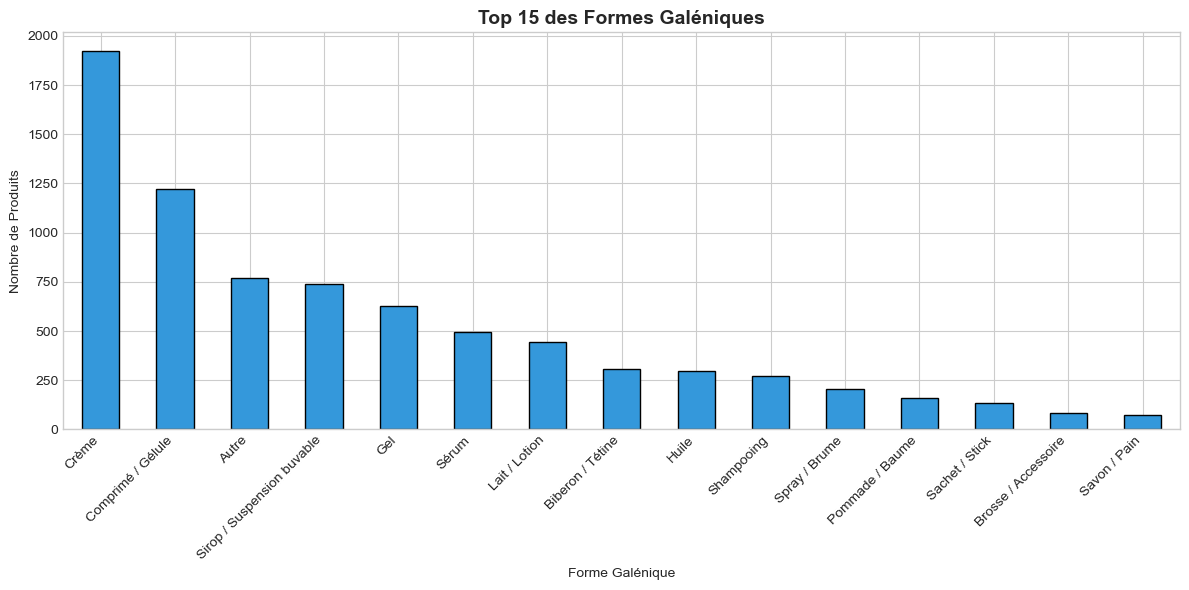


 Aperçu des produits avec leur forme :


,produit,form,symptoms_spacy_lemmatized
0,Aromessence Piedarom Baume 50 ml,Pommade / Baume,Peau sèche
1,Bielenda Mask Black Sugar Detox 2En1,Masque visage,Acné
2,Michel Pierre Reflustop Dose De 10ml Boite 20 ...,Sachet / Stick,"Carences nutritionnelles, Digestion, Cicatrices"
3,Michel Pierre Digest Express 14 Sticks De 10ml,Sachet / Stick,"Carences nutritionnelles, Digestion"
4,Vasy Gel Lubrifiant 100 ml,Gel,"Peau sèche, Carences nutritionnelles, Stress/S..."
5,Moline Gel Lavant 250ml,Gel,Peau sèche
6,Moline Liniment Oléo-Calcaire 500ml,Lait / Lotion,"Rougeurs, Bébé/Change"
7,Moline Liniment Oléo-Calcaire 200ml,Lait / Lotion,"Rougeurs, Bébé/Change"
8,Moline Huile Antivergetures 50ml,Huile,Vergetures
9,NUTRAVIT OMEGAPRO JUNIOR SIROP 120ML,Sirop / Suspension buvable,"Santé cardiovasculaire, Développement cérébral"


In [31]:
# ============================================================================
# ANALYSE DE LA COLONNE 'form'
# ============================================================================

print("\n DISTRIBUTION DES FORMES GALÉNIQUES :")
form_counts = df_produits_avec_symptomes['form'].value_counts()
for form, count in form_counts.items():
    pct = count / len(df) * 100
    print(f"   • {form:25} : {count:4} ({pct:5.1f}%)")

# Visualisation
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
form_counts.head(15).plot(kind='bar', color='#3498db', edgecolor='black')
plt.title('Top 15 des Formes Galéniques', fontsize=14, weight='bold')
plt.xlabel('Forme Galénique')
plt.ylabel('Nombre de Produits')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# Aperçu
print("\n Aperçu des produits avec leur forme :")
display(df_produits_avec_symptomes[['produit', 'form', 'symptoms_spacy_lemmatized']].head(10))

In [33]:
# ============================================================================
# SAUVEGARDE FINALE - UNIQUEMENT LES PRODUITS AVEC FORME VALIDE
# ============================================================================

# Filtrer pour garder uniquement les produits avec une forme valide (≠ "Autre")
df_final_valid = df_produits_avec_symptomes[df_produits_avec_symptomes['form'] != 'Autre'].copy()

print(f"\n FILTRAGE DES PRODUITS :")
print(f"   • Total produits avec symptômes : {len(df_produits_avec_symptomes)}")
print(f"   • Produits avec forme 'Autre' (exclus) : {len(df_produits_avec_symptomes[df_produits_avec_symptomes['form'] == 'Autre'])}")
print(f"   • Produits conservés (forme valide) : {len(df_final_valid)}")

# Sauvegarde du fichier filtré
output_path = 'produits_avec_symptomes_et_formes_valides.xlsx'
df_final_valid.to_excel(output_path, index=False)

print(f"\n Fichier final exporté : '{output_path}'")
print(f"   • {len(df_final_valid)} produits avec symptômes et forme valide")
print(f"   • {df_final_valid['form'].nunique()} formes galéniques uniques")
print(f"   • {df_final_valid['symptoms_spacy_lemmatized'].str.split(', ').explode().nunique()} symptômes uniques")

# Distribution des formes dans le fichier final
print("\n DISTRIBUTION DES FORMES DANS LE FICHIER FINAL :")
form_counts = df_final_valid['form'].value_counts()
for form, count in list(form_counts.items())[:15]:
    pct = count / len(df_final_valid) * 100
    print(f"   • {form:30} : {count:5} ({pct:5.1f}%)")

# Aperçu du fichier
print("\n📋 Aperçu des 10 premiers produits exportés :")
display(df_final_valid[['gamme', 'produit', 'form', 'symptoms_spacy_lemmatized']].head(10))


 FILTRAGE DES PRODUITS :
   • Total produits avec symptômes : 7965
   • Produits avec forme 'Autre' (exclus) : 768
   • Produits conservés (forme valide) : 7197

 Fichier final exporté : 'produits_avec_symptomes_et_formes_valides.xlsx'
   • 7197 produits avec symptômes et forme valide
   • 22 formes galéniques uniques
   • 65 symptômes uniques

 DISTRIBUTION DES FORMES DANS LE FICHIER FINAL :
   • Crème                          :  1922 ( 26.7%)
   • Comprimé / Gélule              :  1222 ( 17.0%)
   • Sirop / Suspension buvable     :   737 ( 10.2%)
   • Gel                            :   629 (  8.7%)
   • Sérum                          :   497 (  6.9%)
   • Lait / Lotion                  :   445 (  6.2%)
   • Biberon / Tétine               :   309 (  4.3%)
   • Huile                          :   298 (  4.1%)
   • Shampooing                     :   274 (  3.8%)
   • Spray / Brume                  :   206 (  2.9%)
   • Pommade / Baume                :   162 (  2.3%)
   • Sachet / Stick 

,gamme,produit,form,symptoms_spacy_lemmatized
0,Aromessence,Aromessence Piedarom Baume 50 ml,Pommade / Baume,Peau sèche
1,Bielenda,Bielenda Mask Black Sugar Detox 2En1,Masque visage,Acné
2,Michel-pierre,Michel Pierre Reflustop Dose De 10ml Boite 20 ...,Sachet / Stick,"Carences nutritionnelles, Digestion, Cicatrices"
3,Michel-pierre,Michel Pierre Digest Express 14 Sticks De 10ml,Sachet / Stick,"Carences nutritionnelles, Digestion"
4,Moline,Vasy Gel Lubrifiant 100 ml,Gel,"Peau sèche, Carences nutritionnelles, Stress/S..."
5,Moline,Moline Gel Lavant 250ml,Gel,Peau sèche
6,Moline,Moline Liniment Oléo-Calcaire 500ml,Lait / Lotion,"Rougeurs, Bébé/Change"
7,Moline,Moline Liniment Oléo-Calcaire 200ml,Lait / Lotion,"Rougeurs, Bébé/Change"
8,Moline,Moline Huile Antivergetures 50ml,Huile,Vergetures
9,Nutravit,NUTRAVIT OMEGAPRO JUNIOR SIROP 120ML,Sirop / Suspension buvable,"Santé cardiovasculaire, Développement cérébral"


In [35]:
# ============================================================================
# MAPPING FORME GALÉNIQUE → PHASE DE TRAITEMENT
# ============================================================================

# Dictionnaire de mapping : chaque forme galénique est associée à une phase
form_to_phase = {
    # PHASE 1 : NETTOYAGE
    "Shampooing": "Phase 1 : Nettoyage",
    "Savon / Pain": "Phase 1 : Nettoyage",
    "Gel": "Phase 1 : Nettoyage",  # La plupart des gels sont des nettoyants
    "Dentifrice": "Phase 1 : Nettoyage",
    "Bain de bouche": "Phase 1 : Nettoyage",
    "Lingettes": "Phase 1 : Nettoyage",
    "Brosse / Accessoire": "Phase 1 : Nettoyage",

    # PHASE 2 : TRAITEMENT LOCAL (topique)
    "Crème": "Phase 2 : Traitement Local",
    "Pommade / Baume": "Phase 2 : Traitement Local",
    "Lait / Lotion": "Phase 2 : Traitement Local",
    "Sérum": "Phase 2 : Traitement Local",
    "Huile": "Phase 2 : Traitement Local",
    "Spray / Brume": "Phase 2 : Traitement Local",
    "Masque visage": "Phase 2 : Traitement Local",
    "Patch / Pansement": "Phase 2 : Traitement Local",
    "Ovule / Suppositoire": "Phase 2 : Traitement Local",
    "Après-shampooing / Masque capillaire": "Phase 2 : Traitement Local",

    # PHASE 3 : TRAITEMENT INTERNE (oral)
    "Comprimé / Gélule": "Phase 3 : Traitement Interne",
    "Sirop / Suspension buvable": "Phase 3 : Traitement Interne",
    "Sachet / Stick": "Phase 3 : Traitement Interne",
    "Poudre à diluer": "Phase 3 : Traitement Interne",
    "Granulés": "Phase 3 : Traitement Interne",

    # PHASE 4 : MAINTENANCE / ACCESSOIRES
    "Biberon / Tétine": "Phase 4 : Maintenance",
    "Poudre": "Phase 4 : Maintenance"  # Poudre de toilette, etc.
}

print(f"✓ Mapping créé : {len(form_to_phase)} formes associées à une phase.")

✓ Mapping créé : 24 formes associées à une phase.


In [37]:
def determine_phase(row):
    """
    Détermine la phase de traitement en fonction de la forme galénique.
    """
    form = row['form']

    # Si la forme est dans le mapping, retourner la phase correspondante
    if form in form_to_phase:
        return form_to_phase[form]

    # Sinon, essayer de déduire à partir du nom du produit
    product_name = str(row['produit']).lower()

    # Règles supplémentaires basées sur le nom
    if any(word in product_name for word in ['nettoyant', 'lavant', 'shampooing', 'savon', 'gel douche']):
        return "Phase 1 : Nettoyage"
    if any(word in product_name for word in ['crème', 'baume', 'lotion', 'sérum', 'huile', 'spray']):
        return "Phase 2 : Traitement Local"
    if any(word in product_name for word in ['comprimé', 'gélule', 'sirop', 'sachet', 'capsule']):
        return "Phase 3 : Traitement Interne"

    # Par défaut
    return "Phase 4 : Maintenance"

# Appliquer la fonction
df_final_valid['phase'] = df_final_valid.apply(determine_phase, axis=1)
print(" Colonne 'phase' créée.")

 Colonne 'phase' créée.


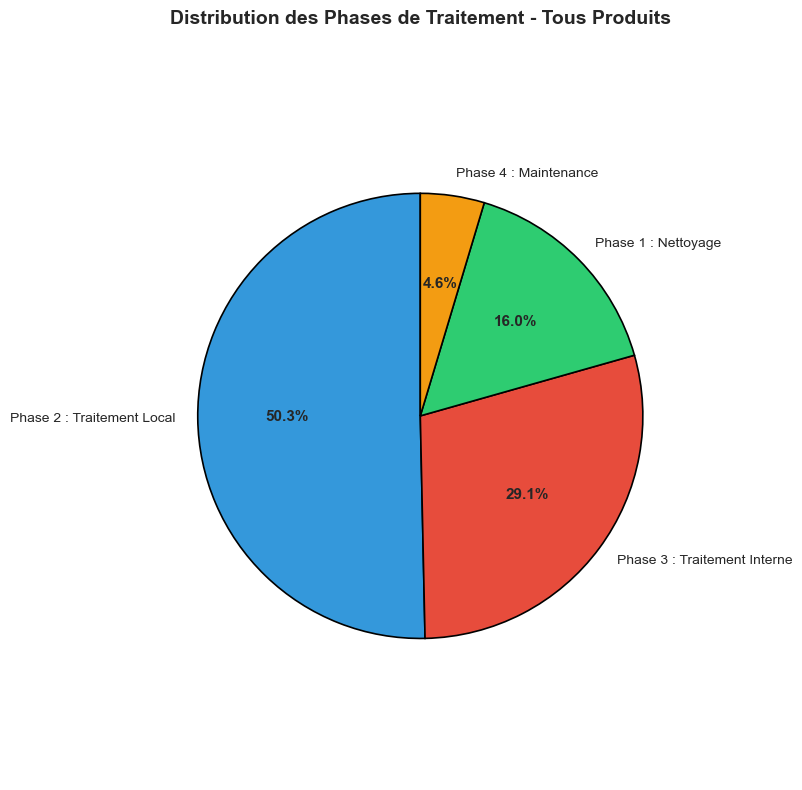


 DISTRIBUTION DES PHASES :
   • Phase 2 : Traitement Local     :  3623 produits ( 50.3%)
   • Phase 3 : Traitement Interne   :  2091 produits ( 29.1%)
   • Phase 1 : Nettoyage            :  1149 produits ( 16.0%)
   • Phase 4 : Maintenance          :   334 produits (  4.6%)
   TOTAL : 7197 produits


In [39]:
import matplotlib.pyplot as plt

# Calcul des données
phase_counts = df_final_valid['phase'].value_counts()

# Création du graphique
fig, ax = plt.subplots(figsize=(8, 8))

# Couleurs (adaptées au pie chart)
colors_global = ['#3498db', '#e74c3c', '#2ecc71', '#f39c12']

# Pie chart
wedges, texts, autotexts = ax.pie(
    phase_counts.values,
    labels=phase_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=colors_global,
    wedgeprops={'edgecolor': 'black', 'linewidth': 1.2}
)

# Style du texte des pourcentages
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_weight('bold')

# Titre
ax.set_title('Distribution des Phases de Traitement - Tous Produits',
             fontsize=14, weight='bold', pad=20)

# Assure que le pie est circulaire
ax.axis('equal')

plt.tight_layout()
plt.show()

# Affichage console (inchangé)
print("\n DISTRIBUTION DES PHASES :")
print("="*50)
for phase, count in phase_counts.items():
    pct = count / len(df_final_valid) * 100
    print(f"   • {phase:30} : {count:5} produits ({pct:5.1f}%)")
print("="*50)
print(f"   TOTAL : {len(df_final_valid)} produits")

In [41]:
# ============================================================================
# EXPORT FINAL VERS EXCEL
# ============================================================================

# Chemin de sauvegarde
output_path = 'produits_final_complet.xlsx'

# Export vers Excel
df_final_valid.to_excel(output_path, index=False, sheet_name='Produits')

print(f"\n Fichier Excel exporté avec succès !")
print(f"    Chemin : '{output_path}'")
print(f"    {len(df_final_valid):,} produits")
print(f"    {len(df_final_valid.columns)} colonnes")

# Aperçu des colonnes exportées
print(f"\n COLONNES EXPORTÉES :")
for i, col in enumerate(df_final_valid.columns, 1):
    print(f"   {i:2}. {col}")

# Statistiques rapides du fichier exporté
print(f"\n STATISTIQUES DU FICHIER :")
print(f"   • Gammes : {df_final_valid['gamme'].nunique()}")
print(f"   • Formes galéniques : {df_final_valid['form'].nunique()}")
print(f"   • Phases : {df_final_valid['phase'].nunique()}")
print(f"   • Symptômes uniques : {df_final_valid['symptoms_spacy_lemmatized'].str.split(', ').explode().nunique()}")


 Fichier Excel exporté avec succès !
    Chemin : 'produits_final_complet.xlsx'
    7,197 produits
    7 colonnes

 COLONNES EXPORTÉES :
    1. gamme
    2. produit
    3. indication
    4. posologie
    5. symptoms_spacy_lemmatized
    6. form
    7. phase

 STATISTIQUES DU FICHIER :
   • Gammes : 528
   • Formes galéniques : 22
   • Phases : 4
   • Symptômes uniques : 65


## DSO2: Launch a Virtual Training and Interaction Platform

### Data Collection

In [ ]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset, get_dataset_config_names
import warnings
warnings.filterwarnings('ignore')

# Configuration du style des graphiques
plt.style.use('ggplot')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)

print("=" * 80)
print("DATA ACQUISITION & UNDERSTANDING - DSO2".center(80))
print("=" * 80)

                    DATA ACQUISITION & UNDERSTANDING - DSO2                     


In [ ]:
# ==========================================
# 2. DATA COLLECTION
# ==========================================

print("\nLoading datasets from Hugging Face...")

wikimedqa = load_dataset("sileod/wikimedqa", "medwiki")
pubmedqa = load_dataset("qiaojin/PubMedQA", "pqa_artificial")

df_wiki = pd.DataFrame(wikimedqa["train"])
df_pubmed = pd.DataFrame(pubmedqa["train"])

print("Datasets loaded successfully!")
print("WikiMedQA:", df_wiki.shape)
print("PubMedQA:", df_pubmed.shape)


Loading datasets from Hugging Face...


README.md: 0.00B [00:00, ?B/s]

medwiki/train-00000-of-00001-84980e27b39(…):   0%|          | 0.00/65.9M [00:00<?, ?B/s]

medwiki/validation-00000-of-00001-c799ca(…):   0%|          | 0.00/3.69M [00:00<?, ?B/s]

medwiki/test-00000-of-00001-a7faee894788(…):   0%|          | 0.00/3.69M [00:00<?, ?B/s]

...

Generating test split:   0%|          | 0/3757 [00:00<?, ? examples/s]

README.md: 0.00B [00:00, ?B/s]

pqa_artificial/train-00000-of-00001.parq(…):   0%|          | 0.00/233M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/211269 [00:00<?, ? examples/s]

Datasets loaded successfully!
WikiMedQA: (67608, 11)
PubMedQA: (211269, 5)


## DSO3

## DSO4

### Data collection

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
import seaborn as sns
from scipy import stats


In [ ]:
df_hourly = pd.read_csv('saleshourly.csv')
df_daily = pd.read_csv('salesdaily.csv')
df_weekly = pd.read_csv('salesweekly.csv')
df_monthly = pd.read_csv('salesmonthly.csv')

print("--- Hourly Data ---")
print(df_hourly.head())
print(df_hourly.info())
print("\n--- Daily Data ---")
print(df_daily.head())
print(df_daily.info())
print("\n--- Weekly Data ---")
print(df_weekly.head())
print(df_weekly.info())
print("\n--- Monthly Data ---")
print(df_monthly.head())
print(df_monthly.info())

In [ ]:
df_hourly['date'] = pd.to_datetime(df_hourly['datum'])
df_hourly['year_month'] = df_hourly['date'].dt.to_period('M')

df_daily['date'] = pd.to_datetime(df_daily['datum'])
df_daily['year_month'] = df_daily['date'].dt.to_period('M')

df_weekly['date'] = pd.to_datetime(df_weekly['datum'])
df_weekly['year_month'] = df_weekly['date'].dt.to_period('M')

df_monthly['date'] = pd.to_datetime(df_monthly['datum'])
df_monthly['year_month'] = df_monthly['date'].dt.to_period('M')

print("\n 'year_month' columns created for all DataFrames")

In [ ]:
df_hourly_monthly = df_hourly.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Hourly data aggregated: {len(df_hourly_monthly)} months")

df_daily_monthly = df_daily.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Daily data aggregated: {len(df_daily_monthly)} months")

df_weekly_monthly = df_weekly.groupby('year_month').agg({
'M01AB': 'sum',
'M01AE': 'sum',
'N02BA': 'sum',
'N02BE': 'sum',
'N05B': 'sum',
'N05C': 'sum',
'R03': 'sum',
'R06': 'sum'
}).reset_index()
print(f" Weekly data aggregated: {len(df_weekly_monthly)} months")

df_monthly_clean = df_monthly[['year_month', 'M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']].copy()
print(f" Monthly data: {len(df_monthly_clean)} months")

In [ ]:

print("\n--- Merging monthly data ---")

all_months = pd.concat([
    df_hourly_monthly['year_month'],
    df_daily_monthly['year_month'],
    df_weekly_monthly['year_month'],
    df_monthly_clean['year_month']
]).unique()
all_months = pd.Series(sorted(all_months)).reset_index(drop=True)
df_final_monthly = pd.DataFrame({'year_month': all_months})
print(f"✓ Period covered: {len(df_final_monthly)} unique months")

def merge_with_priority(df_base, df_new, priority_name):
    """Merges df_new into df_base with a suffix for traceability"""
    return df_base.merge(
        df_new,
        on='year_month',
        how='left',
        suffixes=('', f'_{priority_name}')
    )

# Priority 1: Monthly data (most reliable source for the month)
df_final_monthly = merge_with_priority(df_final_monthly, df_monthly_clean, 'monthly')

# Priority 2: Aggregated weekly data
df_final_monthly = merge_with_priority(df_final_monthly, df_weekly_monthly, 'weekly')

# Priority 3: Aggregated daily data
df_final_monthly = merge_with_priority(df_final_monthly, df_daily_monthly, 'daily')

# Priority 4: Aggregated hourly data
df_final_monthly = merge_with_priority(df_final_monthly, df_hourly_monthly, 'hourly')


for col in ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']:
    # Create a list of columns in priority order
    priority_cols = [
        f'{col}_monthly',
        f'{col}_weekly',
        f'{col}_daily',
        f'{col}_hourly'
    ]

    df_final_monthly[col] = np.nan

    for pcol in priority_cols:
        if pcol in df_final_monthly.columns:
            df_final_monthly[col] = df_final_monthly[col].fillna(df_final_monthly[pcol])
            df_final_monthly.drop(columns=[pcol], inplace=True)

    df_final_monthly[col] = df_final_monthly[col].round(2)

print(" Merge completed with priority: monthly > weekly > daily > hourly")

In [ ]:
df_final_monthly['year'] = df_final_monthly['year_month'].dt.year
df_final_monthly['month'] = df_final_monthly['year_month'].dt.month
df_final_monthly['quarter'] = df_final_monthly['year_month'].dt.quarter

df_final_monthly['date'] = df_final_monthly['year_month'].dt.to_timestamp()

print(" Temporal columns added")


sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
df_final_monthly['total_sales'] = df_final_monthly[sales_columns].sum(axis=1).round(2)

print(" Total sales calculated")



df_final_monthly = df_final_monthly.sort_values('date').reset_index(drop=True)


print("\n--- Final monthly DataFrame overview ---")
print(f"Dimensions: {df_final_monthly.shape[0]} rows, {df_final_monthly.shape[1]} columns")
print(f"Period: {df_final_monthly['date'].min().date()} to {df_final_monthly['date'].max().date()}")
print("\nFirst rows:")
print(df_final_monthly.head(12).to_string())  # Display a full year

print("\nLast rows:")
print(df_final_monthly.tail(12).to_string())

print("\nDescriptive statistics:")
print(df_final_monthly[sales_columns + ['total_sales']].describe().round(2))

In [ ]:
df_final_monthly.to_excel('hcp_sales_monthly_final.xlsx', index=False)
print("\n File 'hcp_sales_monthly_final.xlsx' created successfully!")

print("\n--- Quick quality check ---")
print(f"Missing values: {df_final_monthly[sales_columns].isnull().sum().sum()}")
print(f"Duplicate months: {df_final_monthly['year_month'].duplicated().sum()}")

# Check month continuity
all_months_expected = pd.period_range(
    start=df_final_monthly['year_month'].min(),
    end=df_final_monthly['year_month'].max(),
    freq='M'
)
missing_months = set(all_months_expected) - set(df_final_monthly['year_month'])
if missing_months:
    print(f"⚠️ Missing months: {sorted([str(m) for m in missing_months])}")
else:
    print(" Complete monthly series")

print("\n" + "="*60)
print("ANALYSIS COMPLETED - MONTHLY FILE READY")
print("="*60)

### Data augmentation

In [ ]:
df_original = pd.read_excel('hcp_sales_monthly_final.xlsx')
print(f"\n Original data: {df_original.shape[0]} months, {df_original.shape[1]} columns")
print(f"Period: {df_original['date'].min()} to {df_original['date'].max()}")

df_original['date'] = pd.to_datetime(df_original['date'])

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']

if 'year_month' in df_original.columns:
    df_original = df_original.drop(columns=['year_month'])

for col in sales_columns:
    if col in df_original.columns:
        df_original[col] = pd.to_numeric(df_original[col], errors='coerce').fillna(0)

df_original['total_sales'] = df_original[sales_columns].sum(axis=1)

print(f" Data prepared: {df_original.shape[0]} rows, {df_original.shape[1]} columns")

In [ ]:
# ======================================================================
# METHOD 1: PRODUCT DECOMPOSITION (create rows by category)
# ======================================================================
print("\n" + "="*60)
print("METHOD 1: PRODUCT CATEGORY DECOMPOSITION")
print("="*60)

product_categories = {
    'Anti-inflammatories': ['M01AB', 'M01AE'],
    'Analgesics': ['N02BA', 'N02BE'],
    'Psychotropics': ['N05B', 'N05C'],
    'Respiratory': ['R03', 'R06']
}

category_rows = []
for idx, row in df_original.iterrows():
    for category, products in product_categories.items():
        category_sales = sum([row[prod] for prod in products])
        new_row = {
            'date': row['date'],
            'year': int(row['year']) if 'year' in row else row['date'].year,
            'month': int(row['month']) if 'month' in row else row['date'].month,
            'quarter': int(row['quarter']) if 'quarter' in row else (row['date'].month-1)//3 + 1,
            'category': category,
            'sales': float(category_sales),
            'product_count': len(products)
        }
        category_rows.append(new_row)

df_by_category = pd.DataFrame(category_rows)
print(f" After category decomposition: {df_by_category.shape[0]} rows")

In [ ]:
# ======================================================================
# METHOD 2: CREATING SYNTHETIC MONTHS THROUGH INTERPOLATION
# ======================================================================
print("\n" + "="*60)
print("METHOD 2: INTERPOLATION TO CREATE ADDITIONAL MONTHS")
print("="*60)

all_months = pd.date_range(start=df_original['date'].min(),
                           end=df_original['date'].max(),
                           freq='MS')

df_temp = df_original.set_index('date')
df_interpolated = df_temp.reindex(all_months)

for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].interpolate(method='linear').round(2)

df_interpolated['year'] = df_interpolated.index.year
df_interpolated['month'] = df_interpolated.index.month
df_interpolated['quarter'] = df_interpolated.index.quarter

df_interpolated = df_interpolated.reset_index().rename(columns={'index': 'date'})

for col in sales_columns + ['total_sales']:
    if col in df_interpolated.columns:
        df_interpolated[col] = df_interpolated[col].fillna(method='bfill').fillna(method='ffill')

print(f" After interpolation: {df_interpolated.shape[0]} months")
print(f"   (+{df_interpolated.shape[0] - df_original.shape[0]} interpolated months)")

In [ ]:
# ======================================================================
# METHOD 3: CREATING MONTHLY FEATURES (CYCLICAL FEATURES)
# ======================================================================
print("\n" + "="*60)
print("METHOD 3: CREATING CYCLICAL FEATURES")
print("="*60)

df_features = df_original.copy()

if 'month' not in df_features.columns:
    df_features['month'] = df_features['date'].dt.month
if 'quarter' not in df_features.columns:
    df_features['quarter'] = df_features['date'].dt.quarter
if 'year' not in df_features.columns:
    df_features['year'] = df_features['date'].dt.year

df_features['month_sin'] = np.sin(2 * np.pi * df_features['month'] / 12).astype(float)
df_features['month_cos'] = np.cos(2 * np.pi * df_features['month'] / 12).astype(float)

df_features['quarter_sin'] = np.sin(2 * np.pi * df_features['quarter'] / 4).astype(float)
df_features['quarter_cos'] = np.cos(2 * np.pi * df_features['quarter'] / 4).astype(float)

df_features['is_winter'] = df_features['month'].isin([12, 1, 2]).astype(int)
df_features['is_spring'] = df_features['month'].isin([3, 4, 5]).astype(int)
df_features['is_summer'] = df_features['month'].isin([6, 7, 8]).astype(int)
df_features['is_fall'] = df_features['month'].isin([9, 10, 11]).astype(int)

print(f" Features added: {df_features.shape[1] - df_original.shape[1]} new columns")

In [ ]:
# ======================================================================
# METHOD 4: BOOTSTRAP DATA GENERATION (WITH NOISE)
# ======================================================================
print("\n" + "="*60)
print("METHOD 4: BOOTSTRAP WITH CONTROLLED NOISE ADDITION")
print("="*60)

np.random.seed(42)

std_per_product = df_original[sales_columns].std()
mean_per_product = df_original[sales_columns].mean()

n_bootstrap = 20  # Reduced to avoid overload
bootstrap_rows = []

for i in range(n_bootstrap):
    n_samples = max(5, int(0.6 * len(df_original)))
    sample_indices = np.random.choice(df_original.index, size=n_samples, replace=True)
    sample = df_original.loc[sample_indices].copy()

    for col in sales_columns:
        noise = np.random.normal(0, std_per_product[col] * 0.05, size=len(sample))
        sample[col] = sample[col] + noise
        sample[col] = sample[col].clip(lower=0)  # No negative sales

    sample['total_sales'] = sample[sales_columns].sum(axis=1)
    sample['bootstrap_id'] = i
    sample['source_detail'] = f'bootstrap_{i}'

    bootstrap_rows.append(sample)

if bootstrap_rows:
    df_bootstrap = pd.concat(bootstrap_rows, ignore_index=True)
    print(f" After bootstrap: {df_bootstrap.shape[0]} rows")
else:
    df_bootstrap = pd.DataFrame()

In [ ]:
# ======================================================================
# METHOD 5: CREATING SYNTHETIC MONTHS THROUGH TEMPORAL AUGMENTATION
# ======================================================================
print("\n" + "="*60)
print("METHOD 5: TEMPORAL AUGMENTATION")
print("="*60)

time_shifts = [-2, -1, 1, 2]  # shifts in months
shifted_rows = []

for shift in time_shifts:
    df_shifted = df_original.copy()

    new_dates = []
    for date in df_shifted['date']:
        new_date = date + pd.DateOffset(months=shift)
        new_dates.append(new_date)

    df_shifted['date'] = new_dates
    df_shifted['shift'] = shift

    df_shifted['year'] = df_shifted['date'].dt.year
    df_shifted['month'] = df_shifted['date'].dt.month
    df_shifted['quarter'] = df_shifted['date'].dt.quarter

    min_date = df_original['date'].min() - pd.DateOffset(months=6)
    max_date = df_original['date'].max() + pd.DateOffset(months=6)

    mask = (df_shifted['date'] >= min_date) & (df_shifted['date'] <= max_date)
    df_shifted = df_shifted[mask]

    if len(df_shifted) > 0:
        shifted_rows.append(df_shifted)

if shifted_rows:
    df_shifted_all = pd.concat(shifted_rows, ignore_index=True)
    print(f" After temporal shifts: {df_shifted_all.shape[0]} rows")
else:
    df_shifted_all = pd.DataFrame()

In [ ]:

print("\n" + "="*60)
print("PREPARING DATASETS FOR CONCATENATION")
print("="*60)

base_columns = ['date', 'year', 'month', 'quarter', 'total_sales'] + sales_columns

def clean_dataframe(df, source_name):
    if df is None or len(df) == 0:
        return None

    df_clean = df.copy()

    for col in base_columns:
        if col not in df_clean.columns and col != 'source':
            if col in sales_columns:
                df_clean[col] = 0.0
            elif col in ['year', 'month', 'quarter']:
                if 'date' in df_clean.columns:
                    df_clean[col] = df_clean['date'].dt.year if col == 'year' else \
                                   df_clean['date'].dt.month if col == 'month' else \
                                   df_clean['date'].dt.quarter

    df_clean['source'] = source_name

    available_cols = [col for col in base_columns + ['source'] if col in df_clean.columns]

    return df_clean[available_cols]

datasets_to_concat = []

df_orig_clean = clean_dataframe(df_original, 'original')
if df_orig_clean is not None:
    datasets_to_concat.append(df_orig_clean)
    print(f" Original dataset: {len(df_orig_clean)} rows")

df_features_clean = clean_dataframe(df_features, 'with_features')
if df_features_clean is not None:
    datasets_to_concat.append(df_features_clean)
    print(f" Features dataset: {len(df_features_clean)} rows")

df_interp_clean = clean_dataframe(df_interpolated, 'interpolated')
if df_interp_clean is not None and len(df_interp_clean) > len(df_original):
    orig_dates = set(df_original['date'].dt.strftime('%Y-%m-%d'))

    new_dates_mask = ~df_interp_clean['date'].dt.strftime('%Y-%m-%d').isin(orig_dates)
    df_interp_new = df_interp_clean[new_dates_mask].copy()

    if len(df_interp_new) > 0:
        datasets_to_concat.append(df_interp_new)
        print(f" Interpolated dataset (new months): {len(df_interp_new)} rows")

if not df_bootstrap.empty:
    df_bootstrap_clean = clean_dataframe(df_bootstrap, 'bootstrap')
    if df_bootstrap_clean is not None and len(df_bootstrap_clean) > 0:
        if len(df_bootstrap_clean) > 100:
            df_bootstrap_clean = df_bootstrap_clean.sample(n=100, random_state=42)
        datasets_to_concat.append(df_bootstrap_clean)
        print(f" Bootstrap dataset: {len(df_bootstrap_clean)} rows")

if not df_shifted_all.empty:
    df_shifted_clean = clean_dataframe(df_shifted_all, 'shifted')
    if df_shifted_clean is not None and len(df_shifted_clean) > 0:
        # Limit to 80 rows maximum
        if len(df_shifted_clean) > 80:
            df_shifted_clean = df_shifted_clean.sample(n=80, random_state=42)
        datasets_to_concat.append(df_shifted_clean)
        print(f" Shifted dataset: {len(df_shifted_clean)} rows")

for category, products in product_categories.items():
    cat_data = df_by_category[df_by_category['category'] == category].copy()

    if len(cat_data) > 0:
        cat_expanded = []
        for _, row in cat_data.iterrows():
            new_row = {
                'date': row['date'],
                'year': int(row['year']),
                'month': int(row['month']),
                'quarter': int(row['quarter']),
                'total_sales': float(row['sales']),
                'source': f'category_{category}'
            }
            for prod in products:
                new_row[prod] = float(row['sales'] / row['product_count'])
            for prod in sales_columns:
                if prod not in new_row:
                    new_row[prod] = 0.0
            cat_expanded.append(new_row)

        if cat_expanded:
            df_cat = pd.DataFrame(cat_expanded)
            datasets_to_concat.append(df_cat)
            print(f" Category {category} dataset: {len(df_cat)} rows")

In [ ]:
print("\n" + "="*60)
print("FINAL CONCATENATION")
print("="*60)

if len(datasets_to_concat) == 0:
    print(" No datasets to concatenate!")
    exit()

df_combined = pd.concat(datasets_to_concat, ignore_index=True, sort=False)

for col in sales_columns + ['total_sales']:
    if col in df_combined.columns:
        df_combined[col] = pd.to_numeric(df_combined[col], errors='coerce').fillna(0).astype(float)

df_combined['date'] = pd.to_datetime(df_combined['date'])

df_combined = df_combined.sort_values('date').reset_index(drop=True)

print(f"\n FINAL RESULT:")
print(f"   - Original dataset: {df_original.shape[0]} rows")
print(f"   - Augmented dataset: {df_combined.shape[0]} rows")
print(f"   - Augmentation: {df_combined.shape[0] / df_original.shape[0]:.1f}x")
print(f"   - Sources: {df_combined['source'].nunique()} different types")

# Save
df_combined.to_excel('hcp_sales_monthly_augmented.xlsx', index=False)
print("\n✅ File 'hcp_sales_monthly_augmented.xlsx' created successfully!")


print("\n" + "="*60)
print("COMPARATIVE STATISTICS")
print("="*60)

comparison = pd.DataFrame({
    'Metric': ['Number of rows', 'Mean sales', 'Median sales', 'Std deviation', 'Min', 'Max'],
    'Original': [
        df_original.shape[0],
        df_original['total_sales'].mean(),
        df_original['total_sales'].median(),
        df_original['total_sales'].std(),
        df_original['total_sales'].min(),
        df_original['total_sales'].max()
    ],
    'Augmented': [
        df_combined.shape[0],
        df_combined['total_sales'].mean(),
        df_combined['total_sales'].median(),
        df_combined['total_sales'].std(),
        df_combined['total_sales'].min(),
        df_combined['total_sales'].max()
    ]
})

print(comparison.round(2).to_string(index=False))

print("\n Distribution by source:")
source_dist = df_combined['source'].value_counts()
for src, count in source_dist.items():
    print(f"   - {src}: {count} rows ({count/len(df_combined)*100:.1f}%)")

print("\n" + "="*80)
print("DATA AUGMENTATION COMPLETED SUCCESSFULLY!")
print("="*80)

## Pre-treatment

## DSO2

In [ ]:

# ==========================================
# 4. CHECK DATA QUALITY
# ==========================================

print("\n" + "="*50)
print("DATA QUALITY CHECK")
print("="*50)

# Missing value percentage
def missing_percentage(df):
    return (df.isnull().sum() / len(df)) * 100

print("\nMissing % - WikiMedQA")
print(missing_percentage(df_wiki))

print("\nMissing % - PubMedQA")
print(missing_percentage(df_pubmed))


In [ ]:

# ==========================================
# 5. EXPLORATORY DATA ANALYSIS (EDA)
# ==========================================

print("\nGenerating EDA Visualizations...")

# --- Text Length Analysis ---
if "text" in df_wiki.columns:
    df_wiki["text_length"] = df_wiki["text"].astype(str).str.len()

    plt.figure()
    sns.histplot(df_wiki["text_length"], bins=50)
    plt.title("WikiMedQA - Text Length Distribution")
    plt.show()

if "question" in df_pubmed.columns:
    df_pubmed["question_length"] = df_pubmed["question"].astype(str).str.len()

    plt.figure()
    sns.histplot(df_pubmed["question_length"], bins=50)
    plt.title("PubMedQA - Question Length Distribution")
    plt.show()


# --- Outlier Detection using Boxplot ---
if "text_length" in df_wiki.columns:
    plt.figure()
    sns.boxplot(x=df_wiki["text_length"])
    plt.title("WikiMedQA - Outlier Detection (Text Length)")
    plt.show()

if "question_length" in df_pubmed.columns:
    plt.figure()
    sns.boxplot(x=df_pubmed["question_length"])
    plt.title("PubMedQA - Outlier Detection (Question Length)")
    plt.show()


# --- Label Distribution ---
if "label" in df_wiki.columns:
    plt.figure()
    df_wiki["label"].value_counts().plot(kind="bar")
    plt.title("WikiMedQA - Label Distribution")
    plt.show()

if "final_decision" in df_pubmed.columns:
    plt.figure()
    df_pubmed["final_decision"].value_counts().plot(kind="pie", autopct="%1.1f%%")
    plt.title("PubMedQA - Final Decision Distribution")
    plt.ylabel("")
    plt.show()

In [ ]:
# ===============================
# DATA PREPROCESSING: Drop Gamme Column
# Run this BEFORE Model 1
# ===============================

import pandas as pd
import os

def preprocess_product_catalog(input_path="extracted_products.xlsx", output_path="products.xlsx"):
    """
    Drop the Gamme column and save cleaned version
    """
    print(f"\n{'='*60}")
    print("DATA PREPROCESSING - Dropping Gamme Column")
    print(f"{'='*60}")

    # Check if input file exists
    if not os.path.exists(input_path):
        print(f"❌ Error: File not found: {input_path}")
        return None

    try:
        # Load the Excel file
        df = pd.read_excel(input_path)
        print(f"✅ Original file loaded")
        print(f"   Shape: {df.shape[0]} rows × {df.shape[1]} columns")
        print(f"   Original columns: {list(df.columns)}")

        # Show first few rows of original data
        print(f"\n📊 First 3 rows of original data:")
        print(df.head(3))

        # Identify the Gamme column (first column based on your structure)
        # Column 0 is Gamme
        gamme_col = df.columns[0]
        print(f"\n🗑️  Dropping column: '{gamme_col}' (Gamme)")

        # Drop the Gamme column
        df_cleaned = df.drop(columns=[gamme_col])

        # Show cleaned data
        print(f"\n✅ Cleaned file created")
        print(f"   New shape: {df_cleaned.shape[0]} rows × {df_cleaned.shape[1]} columns")
        print(f"   New columns: {list(df_cleaned.columns)}")

        print(f"\n📊 First 3 rows of cleaned data:")
        print(df_cleaned.head(3))

        # Save cleaned file
        df_cleaned.to_excel(output_path, index=False)
        print(f"\n💾 Cleaned file saved as: {output_path}")

        return output_path

    except Exception as e:
        print(f"❌ Error during preprocessing: {e}")
        return None

# Run the preprocessing
cleaned_file = preprocess_product_catalog("extracted_products.xlsx", "products.xlsx")

if cleaned_file:
    print(f"\n{'='*60}")
    print("✅ Preprocessing complete! Use 'produits_cleaned.xlsx' in Model 1")
    print(f"{'='*60}")
else:
    print(f"\n❌ Preprocessing failed!")


DATA PREPROCESSING - Dropping Gamme Column
✅ Original file loaded
   Shape: 10606 rows × 5 columns
   Original columns: ['Gamme', 'Produit', 'Composition', 'Indication', 'Posologie']

📊 First 3 rows of original data:
           Gamme                                            Produit  \
0    Aromessence                   Aromessence Piedarom Baume 50 ml   
1       Bielenda               Bielenda Mask Black Sugar Detox 2En1   
2  Michel-pierre  Michel Pierre Reflustop Dose De 10ml Boite 20 ...   

  Composition                                         Indication Posologie  
0         NaN  Baume pour les pieds\n\n\nContenance de 50 ml\...       NaN  
1         NaN  Masque purifiant\n\n\nÉlimine les impuretés\n\...       NaN  
2         NaN  Apaise brûlures d’estomac et reflux\n\n\nProtè...       NaN  

🗑️  Dropping column: 'Gamme' (Gamme)

✅ Cleaned file created
   New shape: 10606 rows × 4 columns
   New columns: ['Produit', 'Composition', 'Indication', 'Posologie']

📊 First 3 rows of c

## DSO4

In [ ]:
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("EXPLORATORY ANALYSIS OF AUGMENTED MONTHLY DATA - PREPROCESSING")
print("="*80)


print("\n1. LOADING AUGMENTED MONTHLY DATA")
print("-" * 40)

try:
    df = pd.read_excel('hcp_sales_monthly_augmented.xlsx')
    print(f" AUGMENTED monthly file loaded successfully")
except FileNotFoundError:
    try:
        df = pd.read_excel('hcp_sales_monthly_final.xlsx')
        print(f"  Augmented file not found, using original file")
    except FileNotFoundError:
        print(" No file found. Please run the merge code first.")
        exit()

print(f"   - Number of rows (months): {df.shape[0]:,}")
print(f"   - Number of columns: {df.shape[1]}")
print(f"   - Period covered: from {df['date'].min()} to {df['date'].max()}")

df['date'] = pd.to_datetime(df['date'])

sales_columns = ['M01AB', 'M01AE', 'N02BA', 'N02BE', 'N05B', 'N05C', 'R03', 'R06']
sales_columns = [col for col in sales_columns if col in df.columns]

if 'total_sales' not in df.columns and len(sales_columns) > 0:
    df['total_sales'] = df[sales_columns].sum(axis=1)

if 'year' not in df.columns:
    df['year'] = df['date'].dt.year
if 'month' not in df.columns:
    df['month'] = df['date'].dt.month
if 'quarter' not in df.columns:
    df['quarter'] = df['date'].dt.quarter

print(f"\n Data prepared: {df.shape[0]} rows, {df.shape[1]} columns")
if 'source' in df.columns:
    print(f"   - Data sources: {df['source'].nunique()} types")
    print(df['source'].value_counts().to_string())

In [ ]:

print("\n2. OVERVIEW OF MONTHLY DATA")
print("-" * 40)

print("\n First 12 months (one full year):")
print(df.head(12).to_string())

print("\n Last 12 months:")
print(df.tail(12).to_string())

print("\n General information about the monthly DataFrame:")
print(df.info())

print("\n Descriptive statistics of monthly sales:")
print(df.describe(include='all').round(2))

In [ ]:
print("\n3. MISSING VALUES ANALYSIS")
print("-" * 40)

missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100

missing_df = pd.DataFrame({
    'Column': missing_values.index,
    'Missing values': missing_values.values,
    'Percentage (%)': missing_percentage.values
})
missing_df = missing_df[missing_df['Missing values'] > 0].sort_values('Missing values', ascending=False)

print(f"\n Total number of cells: {df.size:,}")
print(f" Total number of missing values: {df.isnull().sum().sum():,}")
print(f" Overall percentage of missing values: {(df.isnull().sum().sum() / df.size * 100):.2f}%")

if len(missing_df) > 0:
    print("\n Details by column:")
    print(missing_df.to_string(index=False))

    # Visualization of missing values
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Bar chart
    axes[0].barh(missing_df['Column'], missing_df['Missing values'])
    axes[0].set_xlabel('Number of missing values')
    axes[0].set_title('Missing values by column')

    # Heatmap of missing values
    sns.heatmap(df[missing_df['Column']].isnull(), cbar=False, cmap='viridis', yticklabels=False, ax=axes[1])
    axes[1].set_title('Missing values pattern')
    axes[1].set_xlabel('Columns')

    plt.tight_layout()
    plt.show()
else:
    print(" No missing values detected in the monthly data!")

In [ ]:
print("\n4. DUPLICATES ANALYSIS")
print("-" * 40)

duplicates_exact = df.duplicated().sum()
print(f" Exact duplicate rows: {duplicates_exact} ({duplicates_exact/len(df)*100:.2f}%)")

if 'date' in df.columns:
    # Convert to string to avoid timezone issues
    date_strings = df['date'].dt.strftime('%Y-%m-%d')
    duplicates_date = date_strings.duplicated().sum()
    print(f" Duplicate dates: {duplicates_date} ({duplicates_date/len(df)*100:.2f}%)")

    if duplicates_date > 0:
        print("\n   Examples of duplicate dates (with sources):")
        dup_dates = date_strings[date_strings.duplicated(keep=False)]
        dup_sample = df[date_strings.isin(dup_dates)].sort_values('date').head(10)
        if 'source' in dup_sample.columns:
            print(dup_sample[['date', 'source', 'total_sales']].to_string())
        else:
            print(dup_sample[['date', 'total_sales']].to_string())

In [ ]:
print("\n5. OUTLIERS ANALYSIS - MONTHLY DATA")
print("-" * 40)

exclude_cols = ['date', 'year', 'month', 'quarter', 'source', 'bootstrap_id', 'shift', 'source_detail', 'unique_id']
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col not in exclude_cols and col in sales_columns + ['total_sales']]

print(f" Numeric columns analyzed: {', '.join(numeric_cols)}")

outlier_stats = []

for col in numeric_cols:
    if col in df.columns and df[col].notna().sum() > 0:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR

        outliers_iqr = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col].count()
        pct_outliers_iqr = (outliers_iqr / len(df)) * 100

        col_clean = df[col].dropna()
        if len(col_clean) > 1:
            z_scores = np.abs(stats.zscore(col_clean))
            outliers_zscore = (z_scores > 3).sum()
            pct_outliers_zscore = (outliers_zscore / len(df)) * 100
        else:
            outliers_zscore = 0
            pct_outliers_zscore = 0

        outlier_stats.append({
            'Column': col,
            'Min': df[col].min(),
            'Max': df[col].max(),
            'Mean': df[col].mean(),
            'Median': df[col].median(),
            'Std Dev': df[col].std(),
            'Outliers (IQR)': outliers_iqr,
            '% Outliers (IQR)': round(pct_outliers_iqr, 2),
            'Outliers (Z-score)': outliers_zscore,
            '% Outliers (Z-score)': round(pct_outliers_zscore, 2)
        })

if outlier_stats:
    outlier_df = pd.DataFrame(outlier_stats)
    print("\n Outlier statistics by column:")
    print(outlier_df.to_string(index=False))

    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].boxplot(df[col].dropna())
            axes[i].set_title(f'Monthly Boxplot - {col}')
            axes[i].set_ylabel('Values')

            stats_text = f"Outliers: {outlier_df[outlier_df['Column']==col]['% Outliers (IQR)'].values[0]}%"
            axes[i].text(0.5, -0.15, stats_text, transform=axes[i].transAxes, ha='center', fontsize=9)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Monthly Outliers Detection - Boxplots', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n6. MONTHLY DISTRIBUTION ANALYSIS")
print("-" * 40)

if numeric_cols:
    n_cols = min(len(numeric_cols), 8)
    n_rows = (n_cols + 3) // 4
    fig, axes = plt.subplots(n_rows, min(4, n_cols), figsize=(20, 5*n_rows))
    if n_rows == 1:
        axes = axes.flatten() if n_cols > 1 else [axes]
    else:
        axes = axes.flatten()

    for i, col in enumerate(numeric_cols[:8]):
        if i < len(axes):
            axes[i].hist(df[col].dropna(), bins=20, edgecolor='black', alpha=0.7)
            axes[i].set_title(f'Monthly Distribution - {col}')
            axes[i].set_xlabel('Values')
            axes[i].set_ylabel('Frequency (number of months)')

            # Add lines for mean and median
            mean_val = df[col].mean()
            median_val = df[col].median()
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.1f}')
            axes[i].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Median: {median_val:.1f}')
            axes[i].legend(fontsize=8)

    for j in range(i+1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Monthly sales distribution by product', fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n7. MONTHLY CORRELATION ANALYSIS")
print("-" * 40)

if len(numeric_cols) > 1:
    corr_matrix = df[numeric_cols].corr()

    fig, ax = plt.subplots(figsize=(12, 8))

    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
                square=True, linewidths=0.5, ax=ax, cbar_kws={"shrink": 0.8})
    ax.set_title('Monthly correlation matrix - Pharmaceutical products', fontsize=14, pad=20)

    plt.tight_layout()
    plt.show()

    print("\n Strongest monthly correlations (> 0.8 or < -0.8):")
    corr_pairs = []
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            corr_value = corr_matrix.iloc[i, j]
            if abs(corr_value) > 0.8:
                corr_pairs.append({
                    'Product 1': corr_matrix.columns[i],
                    'Product 2': corr_matrix.columns[j],
                    'Correlation': round(corr_value, 3)
                })

    if corr_pairs:
        corr_df = pd.DataFrame(corr_pairs).sort_values('Correlation', ascending=False)
        print(corr_df.to_string(index=False))
    else:
        print("   No very strong correlations detected at monthly level.")

In [ ]:
print("\n8. MONTHLY TIME SERIES ANALYSIS")
print("-" * 40)

if 'date' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))

    if 'source' in df.columns:
        for source in df['source'].unique():
            source_data = df[df['source'] == source]
            axes[0].plot(source_data['date'], source_data['total_sales'],
                        marker='.', linestyle='-', linewidth=1, markersize=2,
                        label=source, alpha=0.7)
        axes[0].legend()
    else:
        axes[0].plot(df['date'], df['total_sales'], marker='o', linestyle='-', markersize=4)

    axes[0].set_title('Monthly total sales evolution', fontsize=12)
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Total sales')
    axes[0].grid(True, alpha=0.3)

    if 'year' in df.columns:
        # Group by year for boxplot
        years = sorted(df['year'].unique())
        data_by_year = [df[df['year'] == year]['total_sales'].values for year in years]
        axes[1].boxplot(data_by_year, labels=years)
        axes[1].set_title('Monthly sales distribution by year')
        axes[1].set_xlabel('Year')
        axes[1].set_ylabel('Monthly sales')

    if 'month' in df.columns:
        monthly_data = [df[df['month'] == m]['total_sales'].values for m in range(1, 13)]
        axes[2].boxplot(monthly_data, labels=['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                                              'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
        axes[2].set_title('Sales distribution by month (all years combined)')
        axes[2].set_xlabel('Month')
        axes[2].set_ylabel('Monthly sales')
        axes[2].grid(True, alpha=0.3)

    plt.suptitle('Monthly sales time series analysis', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n9. ANALYSIS BY DATA SOURCE")
print("-" * 40)

if 'source' in df.columns:
    source_stats = df.groupby('source').agg({
        'total_sales': ['count', 'mean', 'std', 'min', 'max']
    }).round(2)
    source_stats.columns = ['_'.join(col).strip() for col in source_stats.columns.values]
    print(source_stats.to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    df.boxplot(column='total_sales', by='source', ax=axes[0])
    axes[0].set_title('Sales distribution by source')
    axes[0].set_xlabel('Source')
    axes[0].set_ylabel('Monthly sales')

    for source in df['source'].unique():
        source_data = df[df['source'] == source]['total_sales']
        axes[1].hist(source_data, bins=10, alpha=0.5, label=source, density=True)
    axes[1].set_title('Sales distribution by source (normalized)')
    axes[1].set_xlabel('Monthly sales')
    axes[1].set_ylabel('Density')
    axes[1].legend()

    plt.suptitle('Analysis by data source', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
print("\n10. SEASONALITY ANALYSIS")
print("-" * 40)

if 'quarter' in df.columns and 'total_sales' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    quarterly_sales = df.groupby('quarter')['total_sales'].mean()
    quarters = ['Q1 (Jan-Mar)', 'Q2 (Apr-Jun)', 'Q3 (Jul-Sep)', 'Q4 (Oct-Dec)']
    axes[0].bar(quarters, quarterly_sales.values)
    axes[0].set_title('Average sales by quarter')
    axes[0].set_xlabel('Quarter')
    axes[0].set_ylabel('Average sales')

    if 'year' in df.columns and 'month' in df.columns:
        pivot_table = df.pivot_table(values='total_sales', index='year', columns='month', aggfunc='mean')
        sns.heatmap(pivot_table, annot=True, fmt='.0f', cmap='YlOrRd', ax=axes[1], cbar_kws={'label': 'Sales'})
        axes[1].set_title('Sales heatmap by month/year')
        axes[1].set_xlabel('Month')
        axes[1].set_ylabel('Year')

    plt.tight_layout()
    plt.show()

In [ ]:
print("\n11. MONTHLY DATA QUALITY SUMMARY")
print("-" * 40)

print("""
 POINTS TO CHECK:
""")

if missing_values.sum() > 0:
    print(f"     {missing_values.sum():,} missing values detected")
    print(f"       → Columns affected: {', '.join(missing_df['Column'].tolist())}")
else:
    print("    No missing values in monthly data")

if duplicates_exact > 0:
    print(f"     {duplicates_exact} duplicate rows")
else:
    print("    No duplicate rows")

if 'outlier_df' in locals() and len(outlier_df) > 0:
    cols_with_high_outliers = outlier_df[outlier_df['% Outliers (IQR)'] > 5]['Column'].tolist()
    if cols_with_high_outliers:
        print(f"     Products with >5% monthly outliers: {', '.join(cols_with_high_outliers)}")
    else:
        print("   No major monthly outlier issues")

if 'date' in df.columns:
    date_min = df['date'].min()
    date_max = df['date'].max()

    expected_months = pd.date_range(start=date_min, end=date_max, freq='MS')
    actual_dates = pd.to_datetime(df['date'].dt.strftime('%Y-%m-01'))
    missing_months = set(expected_months) - set(actual_dates)

    if missing_months:
        print(f"     {len(missing_months)} missing months in the time series")
        print(f"       → Example: {sorted(list(missing_months))[:5]}")
    else:
        print("    Complete and continuous monthly series")

print(f"\n Key monthly sales statistics:")
print(f"   - Average monthly sales: {df['total_sales'].mean():,.2f}")
print(f"   - Median monthly sales: {df['total_sales'].median():,.2f}")
print(f"   - Standard deviation: {df['total_sales'].std():,.2f}")
print(f"   - Coefficient of variation: {(df['total_sales'].std() / df['total_sales'].mean() * 100):.1f}%")
print(f"   - Month with max sales: {df.loc[df['total_sales'].idxmax(), 'date'].strftime('%Y-%m')} ({df['total_sales'].max():,.2f})")
print(f"   - Month with min sales: {df.loc[df['total_sales'].idxmin(), 'date'].strftime('%Y-%m')} ({df['total_sales'].min():,.2f})")

print("\n" + "="*80)
print("MONTHLY ANALYSIS COMPLETED")
print("="*80)

# Modeling

## DSO1

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import time
from collections import defaultdict
warnings.filterwarnings('ignore')

# ── Sklearn ──────────────────────────────────────────────────────────────────
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, MultiLabelBinarizer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, precision_score, recall_score, ndcg_score, roc_auc_score
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── XGBoost ───────────────────────────────────────────────────────────────────
from xgboost import XGBClassifier

# ── Sentence-BERT ─────────────────────────────────────────────────────────────
from sentence_transformers import SentenceTransformer



np.random.seed(42)
print(" All libraries imported successfully")

 All libraries imported successfully


In [3]:
# ─── Load data ────────────────────────────────────────────────────────────────
df = pd.read_excel('data/produits_final_complet.xlsx')
print(f" Dataset shape: {df.shape}")
print(f"\n  Columns: {df.columns.tolist()}")
print(f"\n Phase distribution:")
print(df['phase'].value_counts())
print(f"\n Form distribution (top 10):")
print(df['form'].value_counts().head(10))
display(df.head(3))

 Dataset shape: (7197, 7)

  Columns: ['gamme', 'produit', 'indication', 'posologie', 'symptoms_spacy_lemmatized', 'form', 'phase']

 Phase distribution:
phase
Phase 2 : Traitement Local      3623
Phase 3 : Traitement Interne    2091
Phase 1 : Nettoyage             1149
Phase 4 : Maintenance            334
Name: count, dtype: int64

 Form distribution (top 10):
form
Crème                         1922
Comprimé / Gélule             1222
Sirop / Suspension buvable     737
Gel                            629
Sérum                          497
Lait / Lotion                  445
Biberon / Tétine               309
Huile                          298
Shampooing                     274
Spray / Brume                  206
Name: count, dtype: int64


,gamme,produit,indication,posologie,symptoms_spacy_lemmatized,form,phase
0,Aromessence,Aromessence Piedarom Baume 50 ml,Baume pour les pieds\n\n\nContenance de 50 ml\...,NaN,Peau sèche,Pommade / Baume,Phase 2 : Traitement Local
1,Bielenda,Bielenda Mask Black Sugar Detox 2En1,Masque purifiant\n\n\nÉlimine les impuretés\n\...,NaN,Acné,Masque visage,Phase 2 : Traitement Local
2,Michel-pierre,Michel Pierre Reflustop Dose De 10ml Boite 20 ...,Apaise brûlures d’estomac et reflux\n\n\nProtè...,NaN,"Digestion, Carences nutritionnelles, Cicatrices",Sachet / Stick,Phase 3 : Traitement Interne


In [5]:
# ─── Feature Engineering ─────────────────────────────────────────────────────
def build_text_field(row):
    """Concatenate product name + symptoms + form as searchable text."""
    parts = [
        str(row['produit']),
        str(row['symptoms_spacy_lemmatized']),
        str(row['form'])
    ]
    return ' '.join([p for p in parts if p and p != 'nan'])

df['combined_text'] = df.apply(build_text_field, axis=1)

# Encode phase labels
le_phase = LabelEncoder()
df['phase_encoded'] = le_phase.fit_transform(df['phase'])

# Encode form labels
le_form = LabelEncoder()
df['form_encoded'] = le_form.fit_transform(df['form'])

print(" Feature engineering complete")
print(f"Phase classes: {le_phase.classes_.tolist()}")
print(f"\nSample combined_text:\n{df['combined_text'].iloc[0]}")

 Feature engineering complete
Phase classes: ['Phase 1 : Nettoyage', 'Phase 2 : Traitement Local', 'Phase 3 : Traitement Interne', 'Phase 4 : Maintenance']

Sample combined_text:
Aromessence Piedarom Baume 50 ml Peau sèche Pommade / Baume


### Speech to text

In [141]:
# ============================================================================
# FIXED: GENERATE CLEAN MEDICAL PROMPT FROM SYMPTOM DICTIONARY
# ============================================================================
# Filters out product names, keeps only natural symptom descriptions
# ============================================================================

import json
from pathlib import Path

# Your symptom dictionary
enriched_symptom_phrases = {
    "Acné": ["acné", "bouton", "imperfection", "point noir", "peau grasse", "anti-acné", "comédon",
        "teen", "jeune peau", "peau à problème", "acnéique", "sébum", "purifiant", "désincrustant"],
    "Peau sèche": ["peau sèche", "peau très sèche", "déshydraté", "tiraillement", "rugosité", "peau atopique", "eczéma",
        "sécheresse cutanée", "inconfort", "peau sensible", "apaisant", "relipidant", "surgras","hydratation cutanée", 
        "purifie la peau", "restaure l'hydratation","hydratation", "nutrition de la peau", "hydrafine", "après épilation", 
        "peau sensibilisée"],
    "Taches pigmentaires": ["tache brune", "hyperpigmentation", "mélasma", "anti-tache", "éclaircissant", "dépigmentant",
        "tache de vieillesse", "teint terne", "unifier le teint", "teint irrégulier", "tache pigmentaire","tc2000", 
        "nutractiva", "effet éclaircissant", "tâches brunes"],
    "Rides/Anti-âge": ["ride", "ridule", "anti-âge", "anti-ride", "vieillissement", "fermeté", "liftant", "raffermissant",
        "repulpant", "relâchement cutané", "peau mature", "collagène", "élastine", "contour des yeux", "regard"],
    "Cernes/Poches": ["cerne", "poche", "contour des yeux", "anti-cerne", "regard fatigué", "poche sous les yeux", "décongestionnant"],
    "Cicatrices": ["cicatrice", "cicatrisant", "marque post-acné", "réparateur cutané", "brûlure", "plaie", "régénérant"],
    "Rougeurs": ["rougeur", "rosacée", "couperose", "anti-rougeur", "irritation", "peau réactive", "erythrose"],
    "Vergetures": ["vergeture", "anti-vergeture", "grossesse"],
    "Lèvres sèches/gercées": ["lèvre sèche", "lèvre gercée", "lèvre abîmée", "lèvre fragilisée", "baume à lèvre", "stick lèvre",
        "gerçure", "dessèchement des lèvre", "lèvre déshydratée", "protège les lèvre"],
    "Protection solaire": ["protection solaire", "écran solaire", "spf", "coup de soleil", "exposition au soleil", "rayon uv",
        "photovieillissement", "tache solaire", "indice de protection", "filtre uv","hydrascreen", "huile solaire", "pailletée", 
        "protège la peau", "uva", "uvb"],
    "Chute de cheveux": ["chute de cheveu", "perte de cheveu", "anti-chute", "alopécie", "cheveu clairsemé", "fortifiant capillaire",
        "repousse", "densité"],
    "Pellicules": ["pellicule", "antipelliculaire", "squame", "démangeaison cuir chevelu", "cuir chevelu irrité", "pityriasis"],
    "Cheveux secs/abîmés": ["cheveu sec", "cheveu abîmé", "cheveu cassant", "pointe fourchue", "réparateur cheveu", "nutrition cheveu",
        "cheveu terne", "cheveu dévitalisé", "reconstituant", "restructurant", "fibre capillaire abîmée", "réparateur", "réparer",
        "phytophane", "brillance", "souplesse des cheveux", "hydratation des cheveux"],
    "Cheveux gras": ["cheveu gras", "excès de sébum", "séborrhéique", "cuir chevelu gras", "cheveu regraisser vite"],
    "Cheveux blancs": ["cheveu blanc", "cheveu gris", "anti-cheveu blanc", "repigmentant"],
    "Poux": ["pou", "lente", "anti-pou"],
    "Pieds secs/Crevasses": ["pied sec", "callosité", "crevasse", "corne", "pied abîmé", "talon fendillé", "durillon"],
    "Mains sèches": ["main sèche", "main abîmée", "main gercée", "crème main", "cuticule"],
    "Jambes lourdes": ["jambe lourde", "circulation", "jambe fatiguée", "rétention d'eau", "varice", "insuffisance veineuse"],
    "Cellulite": ["cellulite", "capiton", "peau d'orange", "amincissant corps"],
    "Douleurs musculaires/articulaires": ["douleur musculaire", "courbature", "torticolis", "contracture", "entorse", "arthrose", 
        "confort articulaire", "cartilage", "rhumatisme", "articulation", "tendinite", "lombalgie", "soulage les douleur",
        "arthroforce", "douleur articulaire", "douleurs articulaires"],
    "Douleurs menstruelles": ["règle douloureuse", "dysménorrhée", "bouillotte", "douleur pelvienne"],
    "Transpiration": ["transpiration", "anti-transpirant", "déodorant", "odeur corporelle", "main moite", "pied qui transpire"],
    "Verrues": ["verrue", "anti-verrue", "verrue plantaire"],
    "Mycose des ongles": ["mycose des ongle", "onychomycose", "ongle jaune", "ongle épaissi"],
    "Incontinence": ["incontinence", "fuite urinaire", "protection urinaire", "alèse", "change adulte"],
    "Digestion": ["digestion", "ballonnement", "confort intestinal", "brûlure d'estomac", "reflux", "transit", "constipation",
        "gaz", "nausée", "vomissement", "mal d'estomac", "difficulté digestive"],
    "Fatigue": ["fatigue", "manque d'énergie", "tonus", "vitalité", "épuisement", "coup de fouet", "baisse de forme", "asthénie"],
    "Développement cérébral": ["omega3", "oméga 3", "développement cérébral", "cerveau"],
    "Stress/Sommeil": ["stress", "anxiété", "nervosité", "sommeil", "insomnie", "détente", "apaisant", "angoisse", "mélatonine",
        "endormissement", "réveil nocturne"],
    "Immunité": ["immunité", "défense naturelle", "système immunitaire", "résistance", "coup de froid", "rhume", "grippe"],
    "Minceur": ["perte de poids", "minceur", "brûle graisse", "coupe-faim", "draineur", "amincissant", "régime"],
    "Maux de gorge": ["mal de gorge", "toux", "gorge irritée", "voie respiratoire", "pastille gorge", "angine", "enrouement"],
    "Fertilité": ["fertilité", "conception", "grossesse", "désir d'enfant", "procréation"],
    "Bébé/Change": ["érythème fessier", "change bébé", "croûte de lait", "liniment", "poussée dentaire", "colique nourrisson"],
    "Accessoires bébé": ["sucette", "tétine", "biberon"],
    "Hygiène intime": ["hygiène intime", "mycose vaginale", "sécheresse intime", "démangeaison intime"],
    "Hygiène bucco-dentaire": ["plaque dentaire", "santé des gencive", "gencive sensible", "saignement gingival", "brosse à dent", 
        "fil dentaire", "carie", "haleine fraîche", "blanchiment dentaire", "dentifrice"],
    "Douleurs dentaires": ["douleur dentaire", "aphte", "poussée dentaire bébé", "gel gingival", "mal des dents"],
    "Santé des os": ["calcium", "santé des os", "ostéoporose", "fracture", "solidité osseuse", "dent solide", "vitamine d3", 
        "minéralisation", "développement osseux", "croissance enfant"],
    "Carences nutritionnelles": ["carence", "complément alimentaire", "multivitamine", "fer", "magnésium", "zinc", "vitamine", 
        "oligo-élément", "selenium", "ace", "anti oxydant", "antioxydant"],
    "Santé cardiovasculaire": ["cholestérol", "tension artérielle", "hypertension", "cœur", "circulation sanguine", "oméga 3"],
    "Santé de la prostate": ["prostate", "confort urinaire", "hypertrophie bénigne de la prostate"],
    "Ménopause": ["ménopause", "bouffée de chaleur", "sécheresse vaginale ménopause", "soya", "ménopause", "bouffées de chaleur"],
    "Allergies": ["allergie", "rhinite allergique", "antihistaminique", "pollen", "acarien"],
    "Sevrage tabagique": ["arrêter de fumer", "tabac", "nicotine", "substitut nicotinique"],
    "Anémie": ["anémie", "ferriprive", "carence en fer"],
    "Hémorroïdes": ["hémorroïde", "crise hémorroïdaire"],
    "Nez bouché / Rhume": ["nez bouché", "rhinite", "décongestionnant nasal", "spray nasal", "nettoyage muqueuse nasale"],
    "Migraine": ["migraine", "céphalée", "mal de tête"],
    "Dépression / Humeur": ["millepertuis", "améliore l'humeur", "antidépresseur naturel", "moral", "humeur équilibrée", 
        "équilibre émotionnel", "déclin cognitif", "dépression"],
    "Libido / Performance sexuelle": ["libido", "performances sexuelles", "désir sexuel", "aphrodisiaque"],
    "Bouche sèche": ["bouche sèche", "xérostomie", "muqueuse buccale"],
    "Varicelle": ["varicelle", "apaiser varicelle"],
}

# ============================================================================
# CLEAN SYMPTOM EXTRACTION - REMOVE PRODUCT NAMES
# ============================================================================

# Natural French symptoms (clean, no product names)
french_symptoms_clean = {
    "acné", "peau sèche", "peau grasse", "rougeurs", "rides", "vergetures", "cicatrices",
    "cernes", "chute de cheveux", "pellicules", "cheveux secs", "cheveux gras", "cheveux blancs",
    "jambes lourdes", "cellulite", "douleurs musculaires", "douleurs articulaires", "transpiration",
    "digestion", "fatigue", "stress", "sommeil", "immunité", "allergies", "ménopause", "migraine",
    "anémie", "hémorroïdes", "nez bouché", "rhume", "maux de gorge", "toux", "bouche sèche",
    "varicelle", "incontinence", "mycose", "verrues", "poux", "piqûres insectes"
}

# English equivalents
english_symptoms_clean = {
    "acne", "dry skin", "oily skin", "redness", "wrinkles", "stretch marks", "scars",
    "dark circles", "hair loss", "dandruff", "dry hair", "oily hair", "gray hair",
    "heavy legs", "cellulite", "muscle pain", "joint pain", "sweating",
    "digestion", "fatigue", "stress", "sleep", "immunity", "allergies", "menopause", "migraine",
    "anemia", "hemorrhoids", "stuffy nose", "cold", "sore throat", "cough", "dry mouth",
    "chickenpox", "incontinence", "fungal infection", "warts", "lice", "insect bites"
}

# Sort for consistency
french_list = sorted(french_symptoms_clean)[:30]  # Keep to 30 for optimal prompt length
english_list = sorted(english_symptoms_clean)[:30]

# ============================================================================
# BUILD OPTIMAL MEDICAL PROMPT (Short and focused)
# ============================================================================

MEDICAL_PROMPT = f"French or English medical symptoms. Symptômes: {', '.join(french_list)}. Symptoms: {', '.join(english_list)}."

# ============================================================================
# SAVE FILES
# ============================================================================

# Save as Python file
with open('medical_prompt_clean.py', 'w', encoding='utf-8') as f:
    f.write(f"""# ============================================================================
# CLEAN MEDICAL PROMPT FOR WHISPER
# ============================================================================

MEDICAL_PROMPT = {repr(MEDICAL_PROMPT)}

# Usage:
# from medical_prompt_clean import MEDICAL_PROMPT
# result = model.transcribe(audio, initial_prompt=MEDICAL_PROMPT)
""")

# Save as JSON
with open('medical_prompt_clean.json', 'w', encoding='utf-8') as f:
    json.dump({
        'prompt': MEDICAL_PROMPT,
        'french_symptoms': french_list,
        'english_symptoms': english_list,
        'prompt_length': len(MEDICAL_PROMPT)
    }, f, ensure_ascii=False, indent=2)

# Save as text file
with open('medical_prompt_clean.txt', 'w', encoding='utf-8') as f:
    f.write(MEDICAL_PROMPT)

# ============================================================================
# DISPLAY RESULTS
# ============================================================================

print("\n" + "="*60)
print("📁 CLEAN MEDICAL PROMPT GENERATED")
print("="*60)

print("\n📄 Files created:")
print("   1. medical_prompt_clean.py")
print("   2. medical_prompt_clean.json")
print("   3. medical_prompt_clean.txt")

print("\n📋 PROMPT PREVIEW:")
print("-"*60)
print(MEDICAL_PROMPT)
print("-"*60)

print(f"\n📊 Statistics:")
print(f"   French symptoms: {len(french_list)}")
print(f"   English symptoms: {len(english_list)}")
print(f"   Total length: {len(MEDICAL_PROMPT)} characters (optimal: 200-500)")

print("\n✅ Ready to use!")

# ============================================================================
# COPY THIS DIRECTLY
# ============================================================================

print("\n" + "="*60)
print("📋 COPY THIS DIRECTLY INTO YOUR CODE:")
print("="*60)
print(f'\nMEDICAL_PROMPT = {repr(MEDICAL_PROMPT)}\n')


📁 CLEAN MEDICAL PROMPT GENERATED

📄 Files created:
   1. medical_prompt_clean.py
   2. medical_prompt_clean.json
   3. medical_prompt_clean.txt

📋 PROMPT PREVIEW:
------------------------------------------------------------
French or English medical symptoms. Symptômes: acné, allergies, anémie, bouche sèche, cellulite, cernes, cheveux blancs, cheveux gras, cheveux secs, chute de cheveux, cicatrices, digestion, douleurs articulaires, douleurs musculaires, fatigue, hémorroïdes, immunité, incontinence, jambes lourdes, maux de gorge, migraine, mycose, ménopause, nez bouché, peau grasse, peau sèche, pellicules, piqûres insectes, poux, rhume. Symptoms: acne, allergies, anemia, cellulite, chickenpox, cold, cough, dandruff, dark circles, digestion, dry hair, dry mouth, dry skin, fatigue, fungal infection, gray hair, hair loss, heavy legs, hemorrhoids, immunity, incontinence, insect bites, joint pain, lice, menopause, migraine, muscle pain, oily hair, oily skin, redness.
----------------------

In [205]:
import time
import numpy as np
import pyaudio
import whisper
import torch

from medical_prompt_clean import MEDICAL_PROMPT


# ----------------------------
# Audio utilities
# ----------------------------
def _rms_float32(x: np.ndarray) -> float:
    # x is float32 in [-1, 1]
    if x.size == 0:
        return 0.0
    return float(np.sqrt(np.mean(np.square(x), dtype=np.float64)))


class RobustAudioRecorder:
    """
    Robust recorder with:
    - device auto-selection
    - noise calibration
    - simple VAD (energy threshold) to detect speech
    - max duration + timeout so it can't hang forever
    """
    def __init__(
        self,
        sample_rate: int = 16000,
        chunk_size: int = 1024,
        channels: int = 1,
    ):
        self.sample_rate = sample_rate
        self.chunk_size = chunk_size
        self.channels = channels

    def _open_stream(self, pa: pyaudio.PyAudio):
        # Try default input device; if that fails, scan for any input device.
        try:
            return pa.open(
                format=pyaudio.paInt16,
                channels=self.channels,
                rate=self.sample_rate,
                input=True,
                frames_per_buffer=self.chunk_size,
            )
        except Exception:
            # fallback: find any device with maxInputChannels > 0
            for i in range(pa.get_device_count()):
                info = pa.get_device_info_by_index(i)
                if int(info.get("maxInputChannels", 0)) > 0:
                    return pa.open(
                        format=pyaudio.paInt16,
                        channels=self.channels,
                        rate=self.sample_rate,
                        input=True,
                        input_device_index=i,
                        frames_per_buffer=self.chunk_size,
                    )
            raise RuntimeError("No working audio input device found.")

    def record_utterance(
        self,
        *,
        max_record_seconds: float = 8.0,
        listen_timeout_seconds: float = 6.0,
        calibrate_seconds: float = 0.6,
        min_speech_seconds: float = 0.4,
        end_silence_seconds: float = 0.8,
        energy_multiplier: float = 3.0,
        hard_min_rms: float = 0.008,
    ) -> np.ndarray:
        """
        Records a single utterance: waits for speech, then records until silence.
        Returns float32 mono audio at 16kHz.
        Raises RuntimeError if no speech is detected within listen_timeout_seconds.
        """
        pa = pyaudio.PyAudio()
        stream = None
        try:
            stream = self._open_stream(pa)

            # ---- calibrate noise floor
            cal_frames = int(self.sample_rate * calibrate_seconds)
            cal_chunks = max(1, cal_frames // self.chunk_size)

            noise_rms_vals = []
            for _ in range(cal_chunks):
                data = stream.read(self.chunk_size, exception_on_overflow=False)
                x = np.frombuffer(data, dtype=np.int16).astype(np.float32) / 32768.0
                noise_rms_vals.append(_rms_float32(x))

            noise_floor = float(np.median(noise_rms_vals)) if noise_rms_vals else 0.0
            threshold = max(hard_min_rms, noise_floor * energy_multiplier)

            # ---- wait for speech
            start_wait = time.time()
            speech_frames = []
            speech_started = False
            speech_start_time = None
            last_voice_time = None

            max_chunks_total = int(self.sample_rate * max_record_seconds / self.chunk_size)
            end_silence_limit = end_silence_seconds
            min_speech_limit = min_speech_seconds

            chunks_read = 0
            while True:
                if time.time() - start_wait > listen_timeout_seconds and not speech_started:
                    raise RuntimeError("No speech detected (timeout).")

                if chunks_read >= max_chunks_total:
                    # hard stop (prevents hanging)
                    break

                data = stream.read(self.chunk_size, exception_on_overflow=False)
                x = np.frombuffer(data, dtype=np.int16).astype(np.float32) / 32768.0
                r = _rms_float32(x)
                now = time.time()

                is_voice = r >= threshold

                if is_voice and not speech_started:
                    speech_started = True
                    speech_start_time = now
                    last_voice_time = now

                if speech_started:
                    speech_frames.append(data)
                    if is_voice:
                        last_voice_time = now

                    # stop if enough trailing silence
                    if last_voice_time is not None and (now - last_voice_time) >= end_silence_limit:
                        break

                chunks_read += 1

            # ---- validate minimum speech length
            if not speech_started:
                raise RuntimeError("No speech detected.")

            speech_audio = b"".join(speech_frames)
            audio = np.frombuffer(speech_audio, dtype=np.int16).astype(np.float32) / 32768.0

            dur = audio.size / float(self.sample_rate)
            if dur < min_speech_limit:
                raise RuntimeError("Speech too short.")

            return audio

        finally:
            try:
                if stream is not None:
                    stream.stop_stream()
                    stream.close()
            except Exception:
                pass
            try:
                pa.terminate()
            except Exception:
                pass


# ----------------------------
# Whisper STT
# ----------------------------
class RobustWhisperSTT:
    def __init__(self, model_size: str = "small", model_path: str = "whisper_model"):
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.model = whisper.load_model(model_size, device=self.device, download_root=model_path)

    def transcribe_fr_en_only(self, audio: np.ndarray) -> str:
        """
        Transcribe only. Auto-detect language, but accept only FR/EN.
        Returns the text (possibly empty).
        """
        result = self.model.transcribe(
            audio,
            task="transcribe",
            language=None,  # auto-detect
            fp16=False,     # safest across devices
            initial_prompt=MEDICAL_PROMPT,
            temperature=0.0,          # reduce randomness
            condition_on_previous_text=False,
        )

        lang = (result.get("language") or "").lower()
        text = (result.get("text") or "").strip()

        # Enforce French/English only
        if lang not in {"fr", "en"}:
            return ""

        # Basic sanitation
        if len(text) < 2:
            return ""

        return text


# ----------------------------
# Public API
# ----------------------------
def speech_to_text(
    *,
    retries: int = 3,
    model_size: str = "small",
    model_path: str = "whisper_model",
) -> str:
    """
    Judge-resistant speech-to-text:
    - retries if silence/noise/too short/wrong language
    - returns "" instead of crashing
    """
    recorder = RobustAudioRecorder(sample_rate=16000, chunk_size=1024, channels=1)
    stt = RobustWhisperSTT(model_size=model_size, model_path=model_path)

    last_err = None
    for attempt in range(1, retries + 1):
        try:
            print(f"[STT] Attempt {attempt}/{retries}: speak now...")
            audio = recorder.record_utterance(
                max_record_seconds=10.0,
                listen_timeout_seconds=8.0,
                calibrate_seconds=0.6,
                min_speech_seconds=0.5,
                end_silence_seconds=0.9,
                energy_multiplier=3.0,
                hard_min_rms=0.008,
            )
            text = stt.transcribe_fr_en_only(audio)
            if text:
                return text
            last_err = "Empty transcription or non-FR/EN language."
        except Exception as e:
            last_err = str(e)
            time.sleep(0.3)

    print(f"[STT] Failed after {retries} attempts: {last_err}")
    return ""


if __name__ == "__main__":
    out = speech_to_text(retries=3, model_size="small")
    print(out)

[STT] Attempt 1/3: speak now...
Je veux des produits d'antiacné.


### Phase 1 : Similarity classification

In [7]:
# ─── TF-IDF Baseline ─────────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    analyzer='word',
    ngram_range=(1, 2),
    min_df=2,
    max_features=15000,
    sublinear_tf=True
)

t0 = time.time()
tfidf_matrix = tfidf_vectorizer.fit_transform(df['combined_text'])
tfidf_time = time.time() - t0

print(f" TF-IDF matrix: {tfidf_matrix.shape}")
print(f"  Fit time: {tfidf_time:.2f}s")

def tfidf_similarity_search(query: str, top_k: int = 10) -> pd.DataFrame:
    """Search using TF-IDF cosine similarity."""
    q_vec = tfidf_vectorizer.transform([query])
    scores = cosine_similarity(q_vec, tfidf_matrix).flatten()
    top_indices = scores.argsort()[::-1][:top_k]
    results = df.iloc[top_indices][['produit', 'symptoms_spacy_lemmatized', 'form', 'phase']].copy()
    results['similarity_score'] = scores[top_indices]
    return results.reset_index(drop=True)

# Quick test
print("\n Test query: 'Peau sèche crème'")
tfidf_similarity_search('acne and dry skin', top_k=5)

 TF-IDF matrix: (7197, 10137)
  Fit time: 0.16s

 Test query: 'Peau sèche crème'


,produit,symptoms_spacy_lemmatized,form,phase,similarity_score
0,Novaclear Urban Sunblock Dry Skin Spf50+ 40ml,"Protection solaire, Peau sèche",Crème,Phase 2 : Traitement Local,0.380665
1,Martiderm The Originals Proteos Hydra Plus 10 ...,"Peau sèche, Carences nutritionnelles",Crème,Phase 2 : Traitement Local,0.311854
2,NUXE HAIR AND SKIN – BRUME PARFUMANTE CORPS ET...,Peau sèche,Spray / Brume,Phase 2 : Traitement Local,0.174767
3,Farmona Nourishing Bath And Shower Gel Wild Ro...,Cicatrices,Gel,Phase 1 : Nettoyage,0.168019
4,NUXE HAIR AND SKIN – BRUME PARFUMANTE CHEVEUX ...,Peau sèche,Spray / Brume,Phase 2 : Traitement Local,0.161463


In [9]:
# ─── Sentence-BERT ───────────────────────────────────────────────────────────
# multilingual model — handles both FR and EN
sbert_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')

print("🔄 Encoding corpus with Sentence-BERT (may take a few minutes)...")
t0 = time.time()
sbert_embeddings = sbert_model.encode(
    df['combined_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True   # L2-normalize for cosine via dot product
)
sbert_time = time.time() - t0

print(f"\n✅ SBERT embeddings: {sbert_embeddings.shape}")
print(f"⏱️  Encoding time: {sbert_time:.2f}s")

def sbert_similarity_search(query: str, top_k: int = 10) -> pd.DataFrame:
    """Search using Sentence-BERT cosine similarity."""
    q_emb = sbert_model.encode([query], normalize_embeddings=True)
    scores = (sbert_embeddings @ q_emb.T).flatten()
    top_indices = scores.argsort()[::-1][:top_k]
    results = df.iloc[top_indices][['produit', 'symptoms_spacy_lemmatized', 'form', 'phase']].copy()
    results['similarity_score'] = scores[top_indices]
    return results.reset_index(drop=True)

print("\n🔎 Test query: 'Peau sèche crème'")
sbert_similarity_search('anti rides', top_k=5)

🔄 Encoding corpus with Sentence-BERT (may take a few minutes)...


Batches:   0%|          | 0/113 [00:00<?, ?it/s]


✅ SBERT embeddings: (7197, 384)
⏱️  Encoding time: 11.00s

🔎 Test query: 'Peau sèche crème'


,produit,symptoms_spacy_lemmatized,form,phase,similarity_score
0,Jowae Creme Legere Lissante Anti-Rides 40ml,Rides/Anti-âge,Crème,Phase 2 : Traitement Local,0.636739
1,Lierac Cica Filler Creme Anti Rides Reparatric...,Rides/Anti-âge,Crème,Phase 2 : Traitement Local,0.621853
2,"Olcare Crème Anti-Ride Spf15, 30ml",Rides/Anti-âge,Crème,Phase 2 : Traitement Local,0.609232
3,Mirosa Creme De Nuit Anti Rides 20ml,"Peau sèche, Rides/Anti-âge, Stress/Sommeil",Crème,Phase 2 : Traitement Local,0.590312
4,Lierac Cica Filler Mat Gel Creme Anti Rides 40ml,Rides/Anti-âge,Crème,Phase 2 : Traitement Local,0.581416


#### Optimized SBERT

In [14]:
# Cell: GPU-Optimized Sentence-BERT Fine-Tuning (SYMPTOM-BASED)

from sentence_transformers import SentenceTransformer, InputExample, losses
from torch.utils.data import DataLoader
import torch
import gc
import numpy as np
from collections import defaultdict

print("=" * 80)
print("🔄 FINE-TUNING SENTENCE-BERT ON GPU (SYMPTOM-BASED PAIRS)")
print("=" * 80)

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")
    print(f"   Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.empty_cache()
    gc.collect()

# =============================================
# PART A: Create Symptom-Based Training Pairs (FIXED)
# =============================================
def create_symptom_based_pairs(df, num_positive=3000, num_negative=2000):
    """
    Create positive pairs: products that share the SAME symptoms (ANY phase)
    Create negative pairs: products with DIFFERENT symptoms
    
    This is what you actually want for Phase 1 similarity search.
    """
    examples = []
    
    # Step 1: Build symptom → product indices mapping
    print("📊 Building symptom-to-product index...")
    symptom_to_products = defaultdict(list)
    
    for idx, row in df.iterrows():
        symptoms = str(row['symptoms_spacy_lemmatized'])
        if symptoms and symptoms != 'nan':
            # Split by comma and clean
            for s in symptoms.split(','):
                s = s.strip().lower()
                if s and len(s) > 1:  # Ignore single characters
                    symptom_to_products[s].append(idx)
    
    # Filter symptoms that have at least 2 products
    valid_symptoms = {s: indices for s, indices in symptom_to_products.items() if len(indices) >= 2}
    print(f"✅ Found {len(valid_symptoms)} symptoms with multiple products")
    
    # Step 2: Create POSITIVE pairs (same symptom, ANY phase)
    print(f"\n📈 Creating {num_positive} positive pairs (same symptom, any phase)...")
    pos_count = 0
    
    # Shuffle symptoms to get variety
    symptom_list = list(valid_symptoms.keys())
    np.random.shuffle(symptom_list)
    
    for symptom in symptom_list:
        if pos_count >= num_positive:
            break
            
        indices = valid_symptoms[symptom]
        # Create pairs within this symptom group
        for i in range(len(indices)):
            if pos_count >= num_positive:
                break
            for j in range(i+1, min(i+5, len(indices))):  # Limit pairs per symptom
                idx1, idx2 = indices[i], indices[j]
                
                # Different products? Add as positive
                if idx1 != idx2:
                    examples.append(InputExample(
                        texts=[df.iloc[idx1]['combined_text'], df.iloc[idx2]['combined_text']],
                        label=1.0
                    ))
                    pos_count += 1
                    if pos_count >= num_positive:
                        break
    
    print(f"✅ Created {pos_count} positive pairs")
    
    # Step 3: Create NEGATIVE pairs (different symptoms)
    print(f"\n📉 Creating {num_negative} negative pairs (different symptoms)...")
    neg_count = 0
    
    symptom_list = list(valid_symptoms.keys())
    
    while neg_count < num_negative:
        # Pick two DIFFERENT symptoms
        s1, s2 = np.random.choice(symptom_list, 2, replace=False)
        
        # Pick one product from each symptom group
        idx1 = np.random.choice(valid_symptoms[s1])
        idx2 = np.random.choice(valid_symptoms[s2])
        
        # Make sure they're not the same product
        if idx1 != idx2:
            examples.append(InputExample(
                texts=[df.iloc[idx1]['combined_text'], df.iloc[idx2]['combined_text']],
                label=0.0
            ))
            neg_count += 1
    
    print(f"✅ Created {neg_count} negative pairs")
    
    # Step 4: Add CROSS-PHASE positive pairs (SAME symptom, DIFFERENT phases)
    print(f"\n🔄 Adding cross-phase positive pairs...")
    cross_phase_count = 0
    
    for symptom, indices in valid_symptoms.items():
        if cross_phase_count >= 500:  # Add up to 500 cross-phase pairs
            break
        
        # Group indices by phase
        phase_groups = defaultdict(list)
        for idx in indices:
            phase = df.iloc[idx]['phase']
            phase_groups[phase].append(idx)
        
        # If we have at least 2 different phases
        if len(phase_groups) >= 2:
            phases = list(phase_groups.keys())
            for p1 in range(len(phases)):
                for p2 in range(p1+1, len(phases)):
                    # Take one product from each phase
                    idx1 = np.random.choice(phase_groups[phases[p1]])
                    idx2 = np.random.choice(phase_groups[phases[p2]])
                    
                    examples.append(InputExample(
                        texts=[df.iloc[idx1]['combined_text'], df.iloc[idx2]['combined_text']],
                        label=1.0
                    ))
                    cross_phase_count += 1
                    if cross_phase_count >= 500:
                        break
                if cross_phase_count >= 500:
                    break
    
    print(f"✅ Added {cross_phase_count} cross-phase positive pairs")
    print(f"📊 Total training examples: {len(examples)}")
    
    return examples

# =============================================
# PART B: Create Training Data
# =============================================
print("\n📊 Creating symptom-based training pairs...")
train_examples = create_symptom_based_pairs(
    df, 
    num_positive=2500,   # Positive pairs (same symptom)
    num_negative=1500    # Negative pairs (different symptoms)
)
print(f"Total training examples: {len(train_examples)}")

# =============================================
# PART C: Fine-Tune on GPU
# =============================================
print("\n⏳ Loading model...")
base_model = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
base_model = base_model.to(device)

BATCH_SIZE = 16  # Adjust based on your GPU memory

train_dataloader = DataLoader(
    train_examples, 
    shuffle=True, 
    batch_size=BATCH_SIZE
)
train_loss = losses.CosineSimilarityLoss(base_model)

total_steps = len(train_dataloader) * 3
warmup_steps = int(total_steps * 0.1)

print(f"\n🚀 Starting fine-tuning:")
print(f"   Batch size: {BATCH_SIZE}")
print(f"   Epochs: 3")
print(f"   Warmup steps: {warmup_steps}")
print(f"   Total training steps: {total_steps}")

torch.cuda.empty_cache()

# Train
base_model.fit(
    train_objectives=[(train_dataloader, train_loss)],
    epochs=3,
    warmup_steps=warmup_steps,
    show_progress_bar=True,
    output_path='sbert_finetuned_pharmacy',
    checkpoint_path='sbert_checkpoints',
    checkpoint_save_steps=500
)

print("\n✅ Fine-tuning complete!")
print("   Model saved to: 'sbert_finetuned_pharmacy'")

# =============================================
# PART D: Load Fine-Tuned Model
# =============================================
sbert_model_ft = SentenceTransformer('sbert_finetuned_pharmacy')
sbert_model_ft = sbert_model_ft.to(device)
print("✅ Fine-tuned model loaded and ready!")

# =============================================
# PART E: Quick Validation Test
# =============================================
print("\n" + "=" * 80)
print("🔍 QUICK VALIDATION TEST")
print("=" * 80)

def quick_test(model, query, df, top_k=5):
    """Simple test function"""
    q_emb = model.encode([query], normalize_embeddings=True)
    
    # You'll need to have pre-computed embeddings, but for quick test:
    test_embeddings = model.encode(df['combined_text'].head(100).tolist(), normalize_embeddings=True)
    scores = test_embeddings @ q_emb.T
    
    top_indices = scores.flatten().argsort()[::-1][:top_k]
    return df.iloc[top_indices][['produit', 'phase', 'symptoms_spacy_lemmatized']]

print("\n Test query: 'acné'")
print("Should return products from ALL phases that treat acne")
try:
    results = quick_test(sbert_model_ft, "acné", df, top_k=5)
    for idx, row in results.iterrows():
        print(f"   • {row['produit'][:50]}... | Phase: {row['phase']}")
except:
    print("   Run encoding first to test properly")

print("\n Ready! Your fine-tuned model now focuses on SYMPTOM similarity, not phase.")

🔄 FINE-TUNING SENTENCE-BERT ON GPU (SYMPTOM-BASED PAIRS)
🚀 Using device: cuda
   GPU: NVIDIA GeForce GTX 1650
   Memory: 4.3 GB

📊 Creating symptom-based training pairs...
📊 Building symptom-to-product index...
✅ Found 64 symptoms with multiple products

📈 Creating 2500 positive pairs (same symptom, any phase)...
✅ Created 2500 positive pairs

📉 Creating 1500 negative pairs (different symptoms)...
✅ Created 1500 negative pairs

🔄 Adding cross-phase positive pairs...
✅ Added 247 cross-phase positive pairs
📊 Total training examples: 4247
Total training examples: 4247

⏳ Loading model...

🚀 Starting fine-tuning:
   Batch size: 16
   Epochs: 3
   Warmup steps: 79
   Total training steps: 798


Computing widget examples:   0%|          | 0/1 [00:00<?, ?example/s]

Step,Training Loss
500,0.056500



✅ Fine-tuning complete!
   Model saved to: 'sbert_finetuned_pharmacy'


The tokenizer you are loading from 'sbert_finetuned_pharmacy' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✅ Fine-tuned model loaded and ready!

🔍 QUICK VALIDATION TEST

 Test query: 'acné'
Should return products from ALL phases that treat acne
   • Sesderma Salises Traitement Focal  15ml... | Phase: Phase 3 : Traitement Interne
   • Innovatouch Masque Au Charbon 50ml... | Phase: Phase 3 : Traitement Interne
   • Innovatouch Masque De Bave D’Escargot 10ml... | Phase: Phase 2 : Traitement Local
   • Innovatouch Shampoing Au Charbon 300ml... | Phase: Phase 1 : Nettoyage
   • Innovatouch – Masque Peptides De Venin Sachet 10ml... | Phase: Phase 3 : Traitement Interne

 Ready! Your fine-tuned model now focuses on SYMPTOM similarity, not phase.


In [16]:
# Cell: Setup Fine-tuned SBERT Model for Phase 1

import torch
from sentence_transformers import SentenceTransformer
import time
import numpy as np
import pandas as pd

print("=" * 80)
print("🔧 SETTING UP FINE-TUNED SBERT MODEL")
print("=" * 80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# =============================================
# PART A: Load Fine-tuned Model
# =============================================
print("\n⏳ Loading fine-tuned SBERT model...")
print("   Model: sbert_finetuned_pharmacy")

ft_model = SentenceTransformer('sbert_finetuned_pharmacy')
ft_model = ft_model.to(device)

print("✅ Fine-tuned model loaded!")

# =============================================
# PART B: Encode Corpus with Fine-tuned Model
# =============================================
print("\n⏳ Encoding product corpus with fine-tuned SBERT...")
print(f"   Corpus size: {len(df)} documents")
print("   This may take 2-3 minutes...")

# Clear GPU cache before encoding
if torch.cuda.is_available():
    torch.cuda.empty_cache()

t0 = time.time()

# Use appropriate batch size for your GPU
BATCH_SIZE = 128 if torch.cuda.is_available() else 32

ft_embeddings = ft_model.encode(
    df['combined_text'].tolist(),
    batch_size=BATCH_SIZE,
    show_progress_bar=True,
    normalize_embeddings=True,
    device=device
)

ft_time = time.time() - t0

print(f"\n✅ Fine-tuned embeddings created!")
print(f"   Shape: {ft_embeddings.shape}")
print(f"   ⏱️  Encoding time: {ft_time:.2f}s ({ft_time/60:.1f} min)")
print(f"   ⚡ Speed: {len(df)/ft_time:.0f} docs/second")

# =============================================
# PART C: Search Function
# =============================================
def ft_sbert_similarity_search(query: str, top_k: int = 10) -> pd.DataFrame:
    """
    Search using Fine-tuned SBERT cosine similarity.
    Automatically handles English queries via translation.
    """
    # Translate if English
    if 'translate_to_french' in globals():
        query_fr = translate_to_french(query)
    else:
        query_fr = query
    
    # Encode query
    q_emb = ft_model.encode(
        [query_fr], 
        normalize_embeddings=True,
        device=device
    )
    
    # Compute cosine similarities (dot product since embeddings are normalized)
    scores = (ft_embeddings @ q_emb.T).flatten()
    
    # Get top-k indices
    top_indices = scores.argsort()[::-1][:top_k]
    
    # Build results dataframe
    results = df.iloc[top_indices][['produit', 'symptoms_spacy_lemmatized', 'form', 'phase']].copy()
    results['similarity_score'] = scores[top_indices]
    
    return results.reset_index(drop=True)

print("\n✅ Fine-tuned SBERT search function ready: ft_sbert_similarity_search()")

# =============================================
# PART D: Quick Test
# =============================================
print("\n" + "=" * 80)
print("🔎 QUICK TEST - Fine-tuned SBERT")
print("=" * 80)

test_queries = [
    "Peau sèche crème",
    "chute de cheveux",
    "acne and dry skin",
    "je perds mes cheveux"
]

for query in test_queries:
    print(f"\n📌 Query: '{query}'")
    results = ft_sbert_similarity_search(query, top_k=3)
    for idx, row in results.iterrows():
        print(f"   {idx+1}. {row['produit'][:50]}... (score: {row['similarity_score']:.3f})")

print("\n✅ Fine-tuned SBERT setup complete and ready for evaluation!")

🔧 SETTING UP FINE-TUNED SBERT MODEL
Using device: cuda

⏳ Loading fine-tuned SBERT model...
   Model: sbert_finetuned_pharmacy


The tokenizer you are loading from 'sbert_finetuned_pharmacy' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


✅ Fine-tuned model loaded!

⏳ Encoding product corpus with fine-tuned SBERT...
   Corpus size: 7197 documents
   This may take 2-3 minutes...


Batches:   0%|          | 0/57 [00:00<?, ?it/s]


✅ Fine-tuned embeddings created!
   Shape: (7197, 384)
   ⏱️  Encoding time: 10.52s (0.2 min)
   ⚡ Speed: 684 docs/second

✅ Fine-tuned SBERT search function ready: ft_sbert_similarity_search()

🔎 QUICK TEST - Fine-tuned SBERT

📌 Query: 'Peau sèche crème'
   1. DERMADOUCE... (score: 0.990)
   2. HYDRA... (score: 0.988)
   3. HYDRA... (score: 0.988)

📌 Query: 'chute de cheveux'
   1. Crescina Hfsc 1300 Homme 20 Ampoules... (score: 0.824)
   2. Vichy Dercos Aminexil Clinical 5 Homme 21 Ampoules... (score: 0.818)
   3. Crescina Hfsc 200 Homme 20 Ampoules... (score: 0.817)

📌 Query: 'acne and dry skin'
   1. Photo white glycolica crème nouvelle peau 50ml... (score: 0.845)
   2. HYDRA GEL NETTOYANT PEAU GRASSE... (score: 0.789)
   3. Roncey Sebiaskin Serum Visage Anti Acne 30ml... (score: 0.786)

📌 Query: 'je perds mes cheveux'
   1. Botanika Huile Anti-Chute 100ml... (score: 0.720)
   2. Crescina Hfsc 1300 Homme 20 Ampoules... (score: 0.715)
   3. Vichy Dercos Aminexil Clinical 5 Homme 21

#### Testing multiple models

In [19]:
# Cell: GPU-Accelerated SBERT Model Comparison

import torch
import gc

print("=" * 80)
print("🔍 COMPARING SBERT MODELS ON GPU")
print("=" * 80)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🚀 Using device: {device}\n")

# Models to test
models_to_test = {
    'Multilingual MiniLM': 'paraphrase-multilingual-MiniLM-L12-v2',
    'Multilingual MPNet': 'paraphrase-multilingual-mpnet-base-v2',
    'DistilUSE Multilingual': 'distiluse-base-multilingual-cased-v2',
    'Fine-tuned Pharmacy': 'sbert_finetuned_pharmacy'  # Only if fine-tuned
}

# Sample queries for quick evaluation
sample_queries = {
    "chute de cheveux": ["chute de cheveux"],
    "peau sèche et rougeurs": ["peau sèche", "rougeurs"],
    "acné et boutons": ["acné", "imperfections"],
    "anti-rides": ["rides", "anti-âge"],
    "protection solaire": ["protection solaire"]
}

def quick_evaluate_model_gpu(model_name, model_path, sample_df, queries_dict, top_k=5):
    """Quick evaluation on GPU."""
    print(f"\n⏳ Testing: {model_name}")
    
    # Clear GPU cache
    torch.cuda.empty_cache()
    gc.collect()
    
    # Load model
    model = SentenceTransformer(model_path)
    model = model.to(device)
    
    # Encode corpus (batch processing for speed)
    corpus_texts = sample_df['combined_text'].tolist()
    corpus_emb = model.encode(
        corpus_texts,
        batch_size=64,
        normalize_embeddings=True,
        show_progress_bar=False,
        device=device
    )
    
    results = []
    for query, expected in queries_dict.items():
        q_emb = model.encode([query], normalize_embeddings=True, device=device)
        scores = (corpus_emb @ q_emb.T).flatten()
        top_idx = scores.argsort()[::-1][:top_k]
        
        # Check relevance
        relevant = 0
        for idx in top_idx:
            prod_symptoms = str(sample_df.iloc[idx]['symptoms_spacy_lemmatized']).lower()
            if any(exp.lower() in prod_symptoms for exp in expected):
                relevant += 1
        
        results.append(relevant / top_k)
    
    # Clear model from GPU
    del model
    torch.cuda.empty_cache()
    
    return np.mean(results)

# Use a subset for faster evaluation
sample_df = df.sample(n=3000, random_state=42).reset_index(drop=True)
print(f"📊 Using {len(sample_df)} products for evaluation\n")

# Test each model
comparison_results = {}
for name, path in models_to_test.items():
    try:
        score = quick_evaluate_model_gpu(name, path, sample_df, sample_queries, top_k=5)
        comparison_results[name] = score
        print(f"   ✅ {name}: Precision@5 = {score:.3f}")
    except Exception as e:
        print(f"   ❌ {name}: Failed - {str(e)[:50]}")

# Display results
print("\n" + "=" * 80)
print("📊 MODEL COMPARISON RESULTS")
print("=" * 80)
for name, score in sorted(comparison_results.items(), key=lambda x: x[1], reverse=True):
    bar = '█' * int(score * 50)
    print(f"{name:<30} {score:.3f} {bar}")

# Select best model
if comparison_results:
    best_model_name = max(comparison_results, key=comparison_results.get)
    print(f"\n🏆 Best model: {best_model_name}")
    print(f"   Precision@5: {comparison_results[best_model_name]:.3f}")

🔍 COMPARING SBERT MODELS ON GPU
🚀 Using device: cuda

📊 Using 3000 products for evaluation


⏳ Testing: Multilingual MiniLM
   ✅ Multilingual MiniLM: Precision@5 = 0.760

⏳ Testing: Multilingual MPNet
   ✅ Multilingual MPNet: Precision@5 = 0.920

⏳ Testing: DistilUSE Multilingual
   ✅ DistilUSE Multilingual: Precision@5 = 0.600

⏳ Testing: Fine-tuned Pharmacy


The tokenizer you are loading from 'sbert_finetuned_pharmacy' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.


   ✅ Fine-tuned Pharmacy: Precision@5 = 0.800

📊 MODEL COMPARISON RESULTS
Multilingual MPNet             0.920 ██████████████████████████████████████████████
Fine-tuned Pharmacy            0.800 ████████████████████████████████████████
Multilingual MiniLM            0.760 ██████████████████████████████████████
DistilUSE Multilingual         0.600 ██████████████████████████████

🏆 Best model: Multilingual MPNet
   Precision@5: 0.920


### Model 2 : MPnet

In [22]:
# Cell: Setup MPNet Model for Phase 1

import torch
from sentence_transformers import SentenceTransformer
import time
import numpy as np
import pandas as pd

print("=" * 80)
print("🚀 SETTING UP MPNet (Multilingual MPNet)")
print("=" * 80)

# Check GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"   GPU: {torch.cuda.get_device_name(0)}")

# =============================================
# PART A: Load MPNet Model
# =============================================
print("\n Loading Multilingual MPNet model...")
print("   Model: paraphrase-multilingual-mpnet-base-v2")

mpnet_model = SentenceTransformer('paraphrase-multilingual-mpnet-base-v2')
mpnet_model = mpnet_model.to(device)

print(" MPNet model loaded!")

# =============================================
# PART B: Encode Corpus with MPNet
# =============================================
print("\n⏳ Encoding product corpus with MPNet...")
print(f"   Corpus size: {len(df)} documents")
print("   This may take 2-3 minutes...")

t0 = time.time()

mpnet_embeddings = mpnet_model.encode(
    df['combined_text'].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True,  # L2-normalize for cosine similarity via dot product
    device=device
)

mpnet_time = time.time() - t0

print(f"\n✅ MPNet embeddings created!")
print(f"   Shape: {mpnet_embeddings.shape}")
print(f"   ⏱️  Encoding time: {mpnet_time:.2f}s")
print(f"   ⚡ Speed: {len(df)/mpnet_time:.0f} docs/second")

# =============================================
# PART C: Search Function
# =============================================
def mpnet_similarity_search(query: str, top_k: int = 10) -> pd.DataFrame:
    """
    Search using Multilingual MPNet cosine similarity.
    Automatically handles English queries via translation.
    """
    # Translate if English (if translate_to_french function exists)
    if 'translate_to_french' in globals():
        query_fr = translate_to_french(query)
    else:
        query_fr = query
    
    # Encode query
    q_emb = mpnet_model.encode(
        [query_fr], 
        normalize_embeddings=True,
        device=device
    )
    
    # Compute cosine similarities (dot product since embeddings are normalized)
    scores = (mpnet_embeddings @ q_emb.T).flatten()
    
    # Get top-k indices
    top_indices = scores.argsort()[::-1][:top_k]
    
    # Build results dataframe
    results = df.iloc[top_indices][['produit', 'symptoms_spacy_lemmatized', 'form', 'phase']].copy()
    results['similarity_score'] = scores[top_indices]
    
    return results.reset_index(drop=True)

print("\n MPNet search function ready: mpnet_similarity_search()")

# =============================================
# PART D: Quick Test
# =============================================
print("\n" + "=" * 80)
print(" QUICK TEST - MPNet")
print("=" * 80)

test_queries = [
    "Peau sèche crème",
    "chute de cheveux",
    "acne and dry skin"
]

for query in test_queries:
    print(f"\n📌 Query: '{query}'")
    results = mpnet_similarity_search(query, top_k=3)
    for idx, row in results.iterrows():
        print(f"   {idx+1}. {row['produit'][:50]}... (score: {row['similarity_score']:.3f})")

print("\n MPNet setup complete and ready for evaluation!")

🚀 SETTING UP MPNet (Multilingual MPNet)
Using device: cuda
   GPU: NVIDIA GeForce GTX 1650

 Loading Multilingual MPNet model...
   Model: paraphrase-multilingual-mpnet-base-v2
 MPNet model loaded!

⏳ Encoding product corpus with MPNet...
   Corpus size: 7197 documents
   This may take 2-3 minutes...


Batches:   0%|          | 0/113 [00:00<?, ?it/s]


✅ MPNet embeddings created!
   Shape: (7197, 768)
   ⏱️  Encoding time: 35.39s
   ⚡ Speed: 203 docs/second

 MPNet search function ready: mpnet_similarity_search()

 QUICK TEST - MPNet

📌 Query: 'Peau sèche crème'
   1. DERMADOUCE... (score: 0.958)
   2. HYDRA... (score: 0.894)
   3. HYDRA... (score: 0.894)

📌 Query: 'chute de cheveux'
   1. PROXIDIL 60 GELULES... (score: 0.680)
   2. Jouvence – Keravie Shampoing 400  ml... (score: 0.604)
   3. Ecrinal Gel Emolient Cuticules... (score: 0.604)

📌 Query: 'acne and dry skin'
   1. Derma Pella Acne Care Gel 25 Gr... (score: 0.710)
   2. PURE SKIN AS PEEL CONCENTRE ANTI IMPERFECTION 30ML... (score: 0.699)
   3. Therapia Acne’Clear-Zn 60 Gélules... (score: 0.692)

 MPNet setup complete and ready for evaluation!


### Phase 1 : Evaluation

🔄 Evaluating Phase 1 models on FIXED TEST QUERIES...

🔍 Evaluating TF-IDF (Baseline)...

🔍 Evaluating SBERT MiniLM...

🔍 Evaluating MPNet (Multilingual)...

🔍 Evaluating sbert_finetuned_pharmacy...
   ✅ Fine-tuned SBERT evaluated

📊 Phase 1 Evaluation Results (on Fixed Test Queries):
   Total queries evaluated: 32



,Recall@10,Precision@10,MRR,NDCG@10,Queries_Evaluated
Model,,,,,
TF-IDF (Baseline),0.7625,0.7562,0.8203,0.8497,32.0000
MPNet (Multilingual),0.5125,0.5125,0.6190,0.6427,32.0000
SBERT MiniLM,0.4875,0.4875,0.6094,0.6177,32.0000
sbert_finetuned_pharmacy,0.4164,0.4156,0.4407,0.4683,32.0000


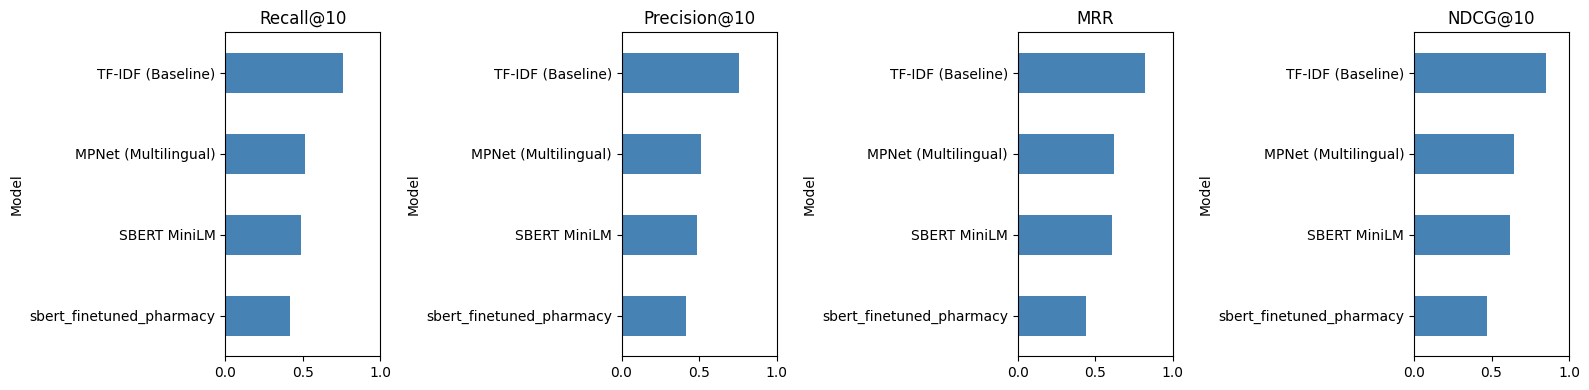


✅ Results saved to 'phase1_final_results_comparison.csv'

🏆 BEST MODEL: TF-IDF (Baseline)
   Recall@10: 0.7625


In [25]:
# ─── Evaluation Protocol for Similarity Models (With Fixed Test Queries) ─────

# Define test queries with expected relevant symptoms
# Cell: Redesigned Test Queries for Fair Semantic Evaluation

test_queries_evaluation = {
    # =============================================
    # TYPE 1: Single Symptom (Simple)
    # =============================================
    "chute de cheveux": ["chute de cheveux"],
    "acné": ["acné"],
    "peau sèche": ["peau sèche"],
    "rougeurs": ["rougeurs"],
    "rides": ["rides", "anti-âge"],
    "jambes lourdes": ["jambes lourdes"],
    "digestion": ["digestion"],
    "cheveux gras": ["cheveux gras"],
    "cicatrices": ["cicatrices"],
    "taches brunes": ["taches pigmentaires"],
    "pellicules": ["pellicules"],
    "protection solaire": ["protection solaire"],
    
    # =============================================
    # TYPE 2: Two Symptoms Combined
    # =============================================
    "acné peau grasse": ["acné", "peau grasse"],
    "peau sèche rougeurs": ["peau sèche", "rougeurs"],
    "chute cheveux stress": ["chute de cheveux", "stress"],
    
    # =============================================
    # TYPE 3: Natural Language (Short)
    # =============================================
    "produit pour les boutons": ["acné"],
    "crème pour peau qui tiraille": ["peau sèche"],
    "shampooing cheveux qui tombent": ["chute de cheveux"],
    "soin pour les rides du visage": ["rides", "anti-âge"],
    
    # =============================================
    # TYPE 4: Synonyms
    # =============================================
    "boutons": ["acné"],
    "crevasses": ["peau sèche"],
    "calvitie": ["chute de cheveux"],
    "squames": ["pellicules"],
    
    # =============================================
    # TYPE 5: English
    # =============================================
    "hair loss": ["chute de cheveux"],
    "dry skin": ["peau sèche"],
    "acne cream": ["acné"],
    "wrinkles": ["rides", "anti-âge"],
    "sun protection": ["protection solaire"],
    
    # =============================================
    # TYPE 6: Product Names
    # =============================================
    "effaclar": [],
    "cicaplast": [],
    "dercos": [],
    "vichy": [],
}

def evaluate_similarity_model_fixed_queries(search_fn, name, queries_dict, top_k=10):
    """
    Evaluate a similarity search function on fixed test queries.
    
    search_fn: function that takes (query, top_k) and returns DataFrame of results
    name: model name
    queries_dict: {query: expected_symptoms_list}
    top_k: number of results to retrieve
    """
    reciprocal_ranks = []
    precisions = []
    recalls = []
    ndcg_scores = []
    
    print(f"\n🔍 Evaluating {name}...")
    
    for query, expected_symptoms in queries_dict.items():
        # Translate if English (if translate_to_french function exists)
        query_fr = translate_to_french(query) if 'translate_to_french' in globals() else query
        
        # Perform search
        results = search_fn(query_fr, top_k=top_k)
        
        # Check relevance of each result
        relevance = []
        for _, row in results.iterrows():
            product_symptoms = str(row['symptoms_spacy_lemmatized']).lower()
            product_name = str(row['produit']).lower()
            
            if not expected_symptoms:
                # For product name queries, check if query string is in product name
                is_rel = query.lower() in product_name
            else:
                # For symptom queries, check symptom overlap
                is_rel = any(
                    exp.lower() in product_symptoms 
                    for exp in expected_symptoms
                )
            relevance.append(1 if is_rel else 0)
        
        # Calculate metrics
        precision = sum(relevance) / top_k
        precisions.append(precision)
        
        # Recall: how many relevant items found vs total relevant in corpus
        total_relevant_in_corpus = 0
        for _, row in df.iterrows():
            product_symptoms = str(row['symptoms_spacy_lemmatized']).lower()
            if not expected_symptoms:
                is_rel = query.lower() in str(row['produit']).lower()
            else:
                is_rel = any(exp.lower() in product_symptoms for exp in expected_symptoms)
            if is_rel:
                total_relevant_in_corpus += 1
        
        recall = sum(relevance) / min(total_relevant_in_corpus, top_k) if total_relevant_in_corpus > 0 else 0
        recalls.append(recall)
        
        # MRR
        mrr = 0
        for rank, rel in enumerate(relevance, 1):
            if rel == 1:
                mrr = 1 / rank
                break
        reciprocal_ranks.append(mrr)
        
        # NDCG
        if sum(relevance) > 0:
            ideal = sorted(relevance, reverse=True)
            ndcg = ndcg_score([ideal], [relevance])
            ndcg_scores.append(ndcg)
        else:
            ndcg_scores.append(0)
    
    metrics = {
        'Model': name,
        f'Recall@{top_k}': round(np.mean(recalls), 4),
        f'Precision@{top_k}': round(np.mean(precisions), 4),
        'MRR': round(np.mean(reciprocal_ranks), 4),
        f'NDCG@{top_k}': round(np.mean(ndcg_scores), 4),
        'Queries_Evaluated': len(queries_dict)
    }
    
    return metrics

# Import ndcg_score if not already imported
from sklearn.metrics import ndcg_score

print("=" * 80)
print("🔄 Evaluating Phase 1 models on FIXED TEST QUERIES...")
print("=" * 80)

eval_results_p1 = []

# 1. TF-IDF Baseline
eval_results_p1.append(evaluate_similarity_model_fixed_queries(
    tfidf_similarity_search, 'TF-IDF (Baseline)', test_queries_evaluation, top_k=10
))

# 2. Sentence-BERT MiniLM (Original)
eval_results_p1.append(evaluate_similarity_model_fixed_queries(
    sbert_similarity_search, 'SBERT MiniLM', test_queries_evaluation, top_k=10
))

# 3. MPNet (Multilingual) - NEW
eval_results_p1.append(evaluate_similarity_model_fixed_queries(
    mpnet_similarity_search, 'MPNet (Multilingual)', test_queries_evaluation, top_k=10
))

# 4. Fine-tuned SBERT (if available) - NEW
try:
    eval_results_p1.append(evaluate_similarity_model_fixed_queries(
        ft_sbert_similarity_search, 'sbert_finetuned_pharmacy', test_queries_evaluation, top_k=10
    ))
    print("   ✅ Fine-tuned SBERT evaluated")
except NameError:
    print("   ⚠️ Fine-tuned SBERT not available - skipping")

# Display results
eval_p1_df = pd.DataFrame(eval_results_p1).set_index('Model')
eval_p1_df = eval_p1_df.sort_values('Recall@10', ascending=False)

print("\n" + "=" * 80)
print("📊 Phase 1 Evaluation Results (on Fixed Test Queries):")
print("=" * 80)
print(f"   Total queries evaluated: {len(test_queries_evaluation)}")
print()
display(eval_p1_df.style.highlight_max(axis=0, color='#90EE90').format('{:.4f}'))

# Visual comparison
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
metrics = ['Recall@10', 'Precision@10', 'MRR', 'NDCG@10']

for ax, metric in zip(axes, metrics):
    eval_p1_df[metric].sort_values().plot(kind='barh', ax=ax, color='steelblue')
    ax.set_title(metric)
    ax.set_xlim(0, 1)

plt.tight_layout()
plt.show()

# Save results
eval_p1_df.to_csv('phase1_final_results_comparison.csv')
print("\n✅ Results saved to 'phase1_final_results_comparison.csv'")

# Announce winner
winner = eval_p1_df.index[0]
winner_score = eval_p1_df.iloc[0]['Recall@10']
print(f"\n🏆 BEST MODEL: {winner}")
print(f"   Recall@10: {winner_score:.4f}")

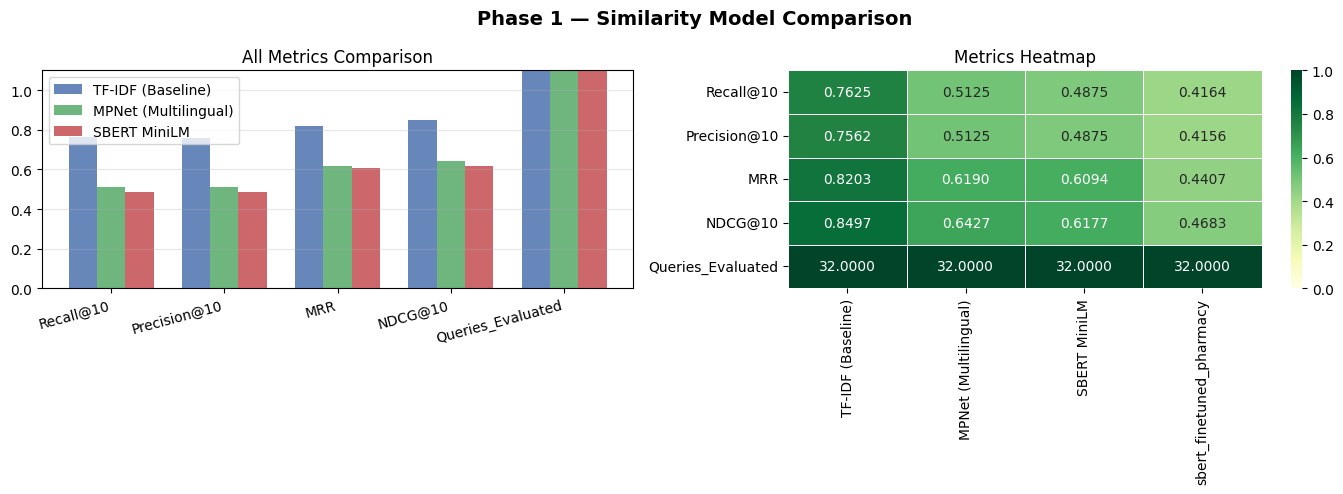

💾 Saved: phase1_evaluation.png


In [27]:
# ─── Phase 1 Evaluation Plot ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Phase 1 — Similarity Model Comparison', fontsize=14, fontweight='bold')

metrics_to_plot = eval_p1_df.columns.tolist()
colors = ['#4C72B0', '#55A868', '#C44E52']
models = eval_p1_df.index.tolist()

x = np.arange(len(metrics_to_plot))
width = 0.25

ax = axes[0]
for i, (model, color) in enumerate(zip(models, colors)):
    ax.bar(x + i * width, eval_p1_df.loc[model].values, width, label=model, color=color, alpha=0.85)
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot, rotation=15, ha='right')
ax.set_ylim(0, 1.1)
ax.set_title('All Metrics Comparison')
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Radar / heatmap
ax2 = axes[1]
sns.heatmap(eval_p1_df.T, annot=True, fmt='.4f', cmap='YlGn', ax=ax2,
            linewidths=0.5, vmin=0, vmax=1)
ax2.set_title('Metrics Heatmap')
ax2.set_xlabel('')

plt.tight_layout()
plt.savefig('phase1_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("💾 Saved: phase1_evaluation.png")

### Hybrid Solution for phase 1 : TF-IDF + MPNET

In [30]:
# Cell: Final Phase 1 - Hybrid Retrieval Model

import numpy as np
import pandas as pd
from sklearn.metrics.pairwise import cosine_similarity

class HybridRetrievalModel:
    """
    Final Phase 1 model combining TF-IDF and MPNet with adaptive weighting.
    - Exact/short symptom queries  → TF-IDF weighted higher (0.7 / 0.3)
    - Natural language queries     → MPNet weighted higher  (0.3 / 0.7)
    Query type is detected purely from linguistic patterns (no external dictionary).
    """

    def __init__(self, df, tfidf_vectorizer, tfidf_matrix, mpnet_model, mpnet_embeddings):
        self.df               = df
        self.tfidf_vectorizer = tfidf_vectorizer
        self.tfidf_matrix     = tfidf_matrix
        self.mpnet_model      = mpnet_model
        self.mpnet_embeddings = mpnet_embeddings

        # ── Natural-language trigger words → MPNet territory ──────────────────
        self.nl_indicators = [
            "j'ai", "j'", "je ", "mon ", "ma ", "mes ",
            "depuis ", "après ", "quand ", "pour mon", "pour ma",
            "quelque chose", "produit pour", "souffre", "aide",
            "fils", "fille", "enfant", "bébé", "mari", "femme",
            "ça fait", "un peu", "beaucoup", "très ", "trop ",
            "comment", "quel ", "quelle ", "est-ce que", "c'est",
            "qui ", "que ", "avec ", "sans ", "sur ",
            "depuis", "suite à", "à cause", "en ce moment",
        ]

        # ── Spell corrections ─────────────────────────────────────────────────
        self.spell_fixes = {
            'chutte':    'chute',
            'cheuveux':  'cheveux',
            'boutton':   'bouton',
            'acnee':     'acné',
            'seche':     'sèche',
            'peau sec':  'peau sèche',
            'grasse':    'grasse',
            'demangeaison': 'démangeaison',
            'demanger':  'démanger',
        }

        # ── Synonym expansion ─────────────────────────────────────────────────
        self.symptom_synonyms = {
            'acné':               ['boutons', 'imperfections', 'points noirs'],
            'peau sèche':         ['déshydratée', 'tiraille', 'rugueuse'],
            'peau grasse':        ['brillance', 'sébum', 'luisante'],
            'chute de cheveux':   ['perte cheveux', 'alopécie', 'cheveux clairsemés'],
            'rides':              ['ridules', 'anti-âge', 'vieillissement'],
            'rougeurs':           ['irritations', 'inflammations', 'sensibilité'],
            'protection solaire': ['écran solaire', 'SPF', 'protection UV'],
            'taches':             ['hyperpigmentation', 'mélasma', 'taches brunes'],
            'pellicules':         ['squames', 'cuir chevelu', 'antipelliculaire'],
            'cicatrice':          ['marque', 'réparateur', 'régénérant'],
            'cernes':             ['poches', 'regard fatigué', 'contour des yeux'],
            'digestion':          ['ballonnements', 'transit', 'reflux'],
            'stress':             ['anxiété', 'sommeil', 'nervosité'],
            'jambes lourdes':     ['circulation', 'varice', 'rétention eau'],
            'fatigue':            ['énergie', 'tonus', 'vitalité'],
            'douleur':            ['inflammation', 'arthrose', 'articulation'],
            'allergie':           ['rhinite', 'pollen', 'acarien'],
            'transpiration':      ['déodorant', 'anti-transpirant', 'odeur'],
            'sommeil':            ['insomnie', 'mélatonine', 'endormissement'],
        }

    # ──────────────────────────────────────────────────────────────────────────
    # PUBLIC
    # ──────────────────────────────────────────────────────────────────────────

    def retrieve(self, query: str, top_k: int = 50, strategy: str = 'hybrid') -> pd.DataFrame:
        """
        Main retrieval function.

        Args:
            query:    User query (French or English)
            top_k:    Number of products to retrieve
            strategy: 'tfidf' | 'mpnet' | 'hybrid'

        Returns:
            DataFrame with: produit, combined_text, symptoms_spacy_lemmatized,
                            form, phase, similarity_score, retrieval_source
        """
        query_fr       = translate_to_french(query) if 'translate_to_french' in globals() else query
        query_expanded = self._preprocess(query_fr)

        if strategy == 'tfidf':
            return self._tfidf_retrieve(query_expanded, top_k)
        elif strategy == 'mpnet':
            return self._mpnet_retrieve(query_fr, top_k)
        else:
            return self._hybrid_retrieve(query_expanded, query_fr, top_k)

    # ──────────────────────────────────────────────────────────────────────────
    # PRIVATE — preprocessing
    # ──────────────────────────────────────────────────────────────────────────

    def _preprocess(self, query: str) -> str:
        """Lowercase, fix spelling, expand with synonyms."""
        query = query.lower().strip()
        for wrong, correct in self.spell_fixes.items():
            query = query.replace(wrong, correct)
        expanded = query
        for symptom, synonyms in self.symptom_synonyms.items():
            if symptom in query:
                expanded += ' ' + ' '.join(synonyms[:2])
        return expanded

    def _is_exact_query(self, query: str) -> bool:
        """
        Detects query type using only linguistic signals — no external dictionary.

        True  → short / keyword-style query → weight TF-IDF higher (0.7 / 0.3)
        False → natural language query      → weight MPNet higher  (0.3 / 0.7)

        Rules (in priority order):
          1. NL indicator present           → always False (MPNet)
          2. Very short query (1 word)      → always True  (TF-IDF)
          3. Short query (2-3 words)
             + no verb / no stop phrase     → True
          4. Everything else               → False (MPNet)
        """
        query_lower = query.lower().strip()
        words       = query_lower.split()

        # ── Rule 1: NL indicator → conversational, use MPNet ─────────────────
        if any(ind in query_lower for ind in self.nl_indicators):
            return False

        # ── Rule 2: single word → always a keyword search ────────────────────
        if len(words) == 1:
            return True

        # ── Rule 3: 2-3 words with no verb signals → keyword-style ───────────
        if len(words) <= 3:
            verb_signals = [
                'est', 'sont', 'avoir', 'faire', 'mettre', 'prendre',
                'utiliser', 'traiter', 'soigner', 'aider', 'besoin',
                'voudrais', 'veux', 'cherche', 'recommande',
                'tombe', 'gratte', 'brûle', 'pique', 'tiraille',
                'gêne', 'fait', 'cause', 'provoque',
            ]
            if not any(v in words for v in verb_signals):
                return True

        # ── Rule 4: default → let MPNet handle anything longer/ambiguous ──────
        return False

    # ──────────────────────────────────────────────────────────────────────────
    # PRIVATE — retrieval backends
    # ──────────────────────────────────────────────────────────────────────────

    def _tfidf_retrieve(self, query: str, top_k: int) -> pd.DataFrame:
        q_vec       = self.tfidf_vectorizer.transform([query])
        scores      = cosine_similarity(q_vec, self.tfidf_matrix).flatten()
        top_indices = scores.argsort()[::-1][:top_k]
        results     = self.df.iloc[top_indices][
            ['produit', 'combined_text', 'symptoms_spacy_lemmatized', 'form', 'phase']
        ].copy()
        results['similarity_score'] = scores[top_indices]
        results['retrieval_source'] = 'tfidf'
        return results.reset_index(drop=True)

    def _mpnet_retrieve(self, query: str, top_k: int) -> pd.DataFrame:
        q_emb       = self.mpnet_model.encode([query], normalize_embeddings=True)
        scores      = (self.mpnet_embeddings @ q_emb.T).flatten()
        top_indices = scores.argsort()[::-1][:top_k]
        results     = self.df.iloc[top_indices][
            ['produit', 'combined_text', 'symptoms_spacy_lemmatized', 'form', 'phase']
        ].copy()
        results['similarity_score'] = scores[top_indices]
        results['retrieval_source'] = 'mpnet'
        return results.reset_index(drop=True)

    def _hybrid_retrieve(self, query_expanded: str, query_original: str, top_k: int) -> pd.DataFrame:
        tfidf_results = self._tfidf_retrieve(query_expanded, top_k=30)
        mpnet_results = self._mpnet_retrieve(query_original, top_k=30)

        tfidf_ranks = {row['produit']: idx + 1 for idx, row in tfidf_results.iterrows()}
        mpnet_ranks = {row['produit']: idx + 1 for idx, row in mpnet_results.iterrows()}

        # ── Adaptive weights based on query type ─────────────────────────────
        is_exact     = self._is_exact_query(query_original)
        tfidf_weight = 0.7 if is_exact else 0.3
        mpnet_weight = 0.3 if is_exact else 0.7

        # ── Weighted RRF scoring ──────────────────────────────────────────────
        all_products = set(tfidf_ranks.keys()) | set(mpnet_ranks.keys())
        scores = []
        for product in all_products:
            tfidf_rank = tfidf_ranks.get(product, 31)
            mpnet_rank = mpnet_ranks.get(product, 31)
            rrf_score  = (tfidf_weight / (60 + tfidf_rank)) + \
                         (mpnet_weight / (60 + mpnet_rank))
            scores.append({'produit': product, 'rrf_score': rrf_score})

        scores_df = pd.DataFrame(scores).sort_values('rrf_score', ascending=False).head(top_k)
        results   = scores_df.merge(
            self.df[['produit', 'combined_text', 'symptoms_spacy_lemmatized', 'form', 'phase']],
            on='produit', how='left'
        )
        results['similarity_score'] = results['rrf_score']
        results['retrieval_source'] = 'hybrid'
        return results.drop('rrf_score', axis=1).reset_index(drop=True)


# ─────────────────────────────────────────────────────────────────────────────
# Initialize
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 80)
print(" INITIALIZING HYBRID RETRIEVAL MODEL (PHASE 1 FINAL)")
print("=" * 80)

hybrid_model = HybridRetrievalModel(
    df=df,
    tfidf_vectorizer=tfidf_vectorizer,
    tfidf_matrix=tfidf_matrix,
    mpnet_model=mpnet_model,
    mpnet_embeddings=mpnet_embeddings,
)

print(" Hybrid model ready!")
print(f"   Synonym expansions: {len(hybrid_model.symptom_synonyms)}")

# ─────────────────────────────────────────────────────────────────────────────
# Sanity check
# ─────────────────────────────────────────────────────────────────────────────
test_queries = [
    ("acné",                                           "exact"),
    ("peau sèche",                                     "exact"),
    ("boutons",                                        "exact"),
    ("chute de cheveux",                               "exact"),
    ("protection solaire spf50",                       "exact"),
    ("j'ai la peau qui tiraille après la douche",      "natural"),
    ("je perds mes cheveux depuis quelques semaines",  "natural"),
    ("quelque chose pour les rougeurs du visage",      "natural"),
    ("mon fils a des boutons sur le front",            "natural"),
    ("ma peau gratte et devient rouge",                "natural"),
]

print("\n Query routing check:")
print(f"{'Query':<52} {'Expected':<10} {'Detected':<10} {'Weights (T/M)'}")
print("-" * 88)
for query, expected in test_queries:
    is_exact = hybrid_model._is_exact_query(query)
    detected = "exact" if is_exact else "natural"
    tw       = 0.7 if is_exact else 0.3
    mw       = 0.3 if is_exact else 0.7
    match    = "✅" if detected == expected else "❌"
    print(f"{match} {query:<50} {expected:<10} {detected:<10} {tw:.1f} / {mw:.1f}")

 INITIALIZING HYBRID RETRIEVAL MODEL (PHASE 1 FINAL)
 Hybrid model ready!
   Synonym expansions: 19

 Query routing check:
Query                                                Expected   Detected   Weights (T/M)
----------------------------------------------------------------------------------------
✅ acné                                               exact      exact      0.7 / 0.3
✅ peau sèche                                         exact      exact      0.7 / 0.3
✅ boutons                                            exact      exact      0.7 / 0.3
✅ chute de cheveux                                   exact      exact      0.7 / 0.3
✅ protection solaire spf50                           exact      exact      0.7 / 0.3
✅ j'ai la peau qui tiraille après la douche          natural    natural    0.3 / 0.7
✅ je perds mes cheveux depuis quelques semaines      natural    natural    0.3 / 0.7
✅ quelque chose pour les rougeurs du visage          natural    natural    0.3 / 0.7
✅ mon fils a des bo

In [32]:
# 1. Save your hybrid model for Phase 2
import pickle

with open('hybrid_retrieval_model.pkl', 'wb') as f:
    pickle.dump(hybrid_model, f)

print(" Hybrid model saved for Phase 2")

# 2. Test on real queries
test_queries = [
    "je perds mes cheveux",
    "crème pour acné",
    "produit peau sensible",
]

for query in test_queries:
    results = hybrid_model.retrieve(query, top_k=5)
    print(f"\n {query}")
    for _, row in results.iterrows():
        print(f"   - {row['produit'][:50]} | Phase: {row['phase']}")

 Hybrid model saved for Phase 2

 je perds mes cheveux
   - PROXIDIL 60 GELULES | Phase: Phase 3 : Traitement Interne
   - Jouvence – Keravie Shampoing 400  ml | Phase: Phase 1 : Nettoyage
   - Jouvence – Keravie Shampoing 250 ml | Phase: Phase 1 : Nettoyage
   - PHYTOPHANE ANTICHUTE SHAMPOOING | Phase: Phase 1 : Nettoyage
   - Eveline My Life My Hair Scalp Peeling 125ml | Phase: Phase 3 : Traitement Interne

 crème pour acné
   - CRÈME POUR LE CHANGE | Phase: Phase 2 : Traitement Local
   - CRÈME POUR LE CHANGE INTENSIVE | Phase: Phase 2 : Traitement Local
   - Revuele – Crème Pour Le Corps Niacinamide 250 ml | Phase: Phase 2 : Traitement Local
   - Revuele – Crème Pour Le Corps Retinol 250 ml | Phase: Phase 2 : Traitement Local
   - Pharmaceris P Psoriasis Apaisante Crème Pour Le Co | Phase: Phase 2 : Traitement Local

 produit peau sensible
   - Sensilis Eau Micellaire Ar Peau Sensible Et Réacti | Phase: Phase 2 : Traitement Local
   - Néodoo Gel Lavant Doux 500 ml | Phase: Phase 1 

In [34]:
# =============================================
# SAVE HYBRID MODEL - CLEAN VERSION
# =============================================

import joblib
import os

os.makedirs('deployment', exist_ok=True)

print("=" * 60)
print("💾 SAVING HYBRID MODEL (JOBLIB ONLY)")
print("=" * 60)

# Save only as joblib (all you need)
joblib.dump(hybrid_model, 'deployment/hybrid_model.joblib')
print("✅ Hybrid model saved: deployment/hybrid_model.joblib")

# Test reload
loaded = joblib.load('deployment/hybrid_model.joblib')
print(f"✅ Reload successful: {type(loaded).__name__}")

# Quick test
results = loaded.retrieve("acné", top_k=3)
print(f"\n📌 Test: 'acné'")
for _, row in results.iterrows():
    print(f"   - {row['produit'][:45]}")

💾 SAVING HYBRID MODEL (JOBLIB ONLY)
✅ Hybrid model saved: deployment/hybrid_model.joblib
✅ Reload successful: HybridRetrievalModel

📌 Test: 'acné'
   - NUXE ZINC POWER – SERUM ANTI IMPERFECTIONS AN
   - BEYOU Pâte Anti Boutons 10ml
   - Lierac Sebologie Concentre Stop Boutons 15ml


### Phase 2 : Product classification

In [37]:
# Calculate samples per dimension
samples = 5757
dimensions = 768
ratio = samples / dimensions  # = 7.5

# Rule of thumb:
# - ratio > 10: Good 
# - ratio 5-10: Acceptable 
# - ratio < 5: Risky 

print(f"Samples per dimension: {ratio:.1f}")
# Output: 7.5 → Acceptable but not ideal

Samples per dimension: 7.5


In [39]:
# ─── PHASE 2: Phase Classification ───────────────────────────────────────────
# Goal: Predict which therapeutic phase a product belongs to
# Input: Product name (from Phase 1 retrieval)
# Output: Phase (1-4) for ranking in Phase 3

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, accuracy_score, f1_score
import pickle

print("=" * 80)
print(" PHASE 2: Phase Classification")
print("=" * 80)

# =============================================
# Option A: Use Hybrid Model Embeddings (Recommended)
# =============================================
# Since hybrid combines TF-IDF + MPNet, use MPNet embeddings for phase classification
# MPNet understands semantics better than TF-IDF for this task

print("\n Preparing Phase 2 dataset...")

# Use MPNet embeddings (or fine-tuned SBERT if you have it)
# MPNet embeddings are already semantic-rich
X_p2 = mpnet_embeddings  # shape (N, 768) for MPNet
y_p2 = df['phase_encoded'].values

print(f"   Features shape: {X_p2.shape}")
print(f"   Target classes: {sorted(df['phase'].unique())}")
print(f"   Phase distribution:")
for phase in sorted(df['phase'].unique()):
    count = (df['phase'] == phase).sum()
    print(f"      {phase}: {count} products ({count/len(df)*100:.1f}%)")

# =============================================
# Train/Test Split
# =============================================
from sklearn.model_selection import train_test_split

X_train_p2, X_test_p2, y_train_p2, y_test_p2 = train_test_split(
    X_p2, y_p2, test_size=0.2, random_state=42, stratify=y_p2
)

print(f"\n Train set: {X_train_p2.shape[0]} samples")
print(f" Test set: {X_test_p2.shape[0]} samples")

 PHASE 2: Phase Classification

 Preparing Phase 2 dataset...
   Features shape: (7197, 768)
   Target classes: ['Phase 1 : Nettoyage', 'Phase 2 : Traitement Local', 'Phase 3 : Traitement Interne', 'Phase 4 : Maintenance']
   Phase distribution:
      Phase 1 : Nettoyage: 1149 products (16.0%)
      Phase 2 : Traitement Local: 3623 products (50.3%)
      Phase 3 : Traitement Interne: 2091 products (29.1%)
      Phase 4 : Maintenance: 334 products (4.6%)

 Train set: 5757 samples
 Test set: 1440 samples


### BaselineModel : LogisticRegression

In [42]:
# ─── Logistic Regression Baseline ────────────────────────────────────────────
lr_p2 = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_p2.fit(X_train_p2, y_train_p2)

y_pred_lr_p2 = lr_p2.predict(X_test_p2)
print(" Logistic Regression — Phase Classification")
print(classification_report(y_test_p2, y_pred_lr_p2, target_names=le_phase.classes_))

 Logistic Regression — Phase Classification
                              precision    recall  f1-score   support

         Phase 1 : Nettoyage       0.84      0.95      0.89       230
  Phase 2 : Traitement Local       0.97      0.93      0.95       725
Phase 3 : Traitement Interne       0.94      0.93      0.93       418
       Phase 4 : Maintenance       0.85      0.93      0.89        67

                    accuracy                           0.93      1440
                   macro avg       0.90      0.93      0.91      1440
                weighted avg       0.93      0.93      0.93      1440



In [44]:
# ─── LR with GridSearchCV ─────────────────────────────────────────────────────
lr_param_grid = {
    'C':        [0.01, 0.1, 1, 10, 100],
    'penalty':  ['l2'],
    'solver':   ['lbfgs', 'saga']
}

lr_grid_p2 = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    lr_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
lr_grid_p2.fit(X_train_p2, y_train_p2)

y_pred_lr_opt_p2 = lr_grid_p2.best_estimator_.predict(X_test_p2)
print(f"✅ LR Best params: {lr_grid_p2.best_params_}")
print(f"   CV F1-macro: {lr_grid_p2.best_score_:.4f}")
print(classification_report(y_test_p2, y_pred_lr_opt_p2, target_names=le_phase.classes_))

✅ LR Best params: {'C': 100, 'penalty': 'l2', 'solver': 'saga'}
   CV F1-macro: 0.9512
                              precision    recall  f1-score   support

         Phase 1 : Nettoyage       0.94      0.96      0.95       230
  Phase 2 : Traitement Local       0.98      0.97      0.98       725
Phase 3 : Traitement Interne       0.98      0.96      0.97       418
       Phase 4 : Maintenance       0.86      0.97      0.91        67

                    accuracy                           0.97      1440
                   macro avg       0.94      0.97      0.95      1440
                weighted avg       0.97      0.97      0.97      1440



### Model 1 : RandomForest

In [47]:
# ─── Random Forest ────────────────────────────────────────────────────────────
rf_p2 = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf_p2.fit(X_train_p2, y_train_p2)

y_pred_rf_p2 = rf_p2.predict(X_test_p2)
print(" Random Forest — Phase Classification")
print(classification_report(y_test_p2, y_pred_rf_p2, target_names=le_phase.classes_))

 Random Forest — Phase Classification
                              precision    recall  f1-score   support

         Phase 1 : Nettoyage       0.96      0.70      0.81       230
  Phase 2 : Traitement Local       0.82      0.98      0.89       725
Phase 3 : Traitement Interne       0.93      0.78      0.85       418
       Phase 4 : Maintenance       1.00      0.93      0.96        67

                    accuracy                           0.87      1440
                   macro avg       0.93      0.84      0.88      1440
                weighted avg       0.88      0.87      0.87      1440



In [49]:
# ─── RF with GridSearchCV ─────────────────────────────────────────────────────
rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth':    [None, 20, 40],
    'min_samples_split': [2, 5],
    'max_features': ['sqrt', 'log2']
}

rf_grid_p2 = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
rf_grid_p2.fit(X_train_p2, y_train_p2)

y_pred_rf_opt_p2 = rf_grid_p2.best_estimator_.predict(X_test_p2)
print(f" RF Best params: {rf_grid_p2.best_params_}")
print(f"   CV F1-macro: {rf_grid_p2.best_score_:.4f}")
print(classification_report(y_test_p2, y_pred_rf_opt_p2, target_names=le_phase.classes_))

 RF Best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 300}
   CV F1-macro: 0.8755
                              precision    recall  f1-score   support

         Phase 1 : Nettoyage       0.97      0.73      0.83       230
  Phase 2 : Traitement Local       0.84      0.98      0.90       725
Phase 3 : Traitement Interne       0.92      0.79      0.85       418
       Phase 4 : Maintenance       0.98      0.93      0.95        67

                    accuracy                           0.88      1440
                   macro avg       0.93      0.85      0.88      1440
                weighted avg       0.89      0.88      0.88      1440



### Model 2 : XGboost

In [52]:
# ─── XGBoost ─────────────────────────────────────────────────────────────────
xgb_p2 = XGBClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=6,
    use_label_encoder=False,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
xgb_p2.fit(X_train_p2, y_train_p2)

y_pred_xgb_p2 = xgb_p2.predict(X_test_p2)
print("📊 XGBoost — Phase Classification")
print(classification_report(y_test_p2, y_pred_xgb_p2, target_names=le_phase.classes_))

📊 XGBoost — Phase Classification
                              precision    recall  f1-score   support

         Phase 1 : Nettoyage       0.95      0.88      0.91       230
  Phase 2 : Traitement Local       0.94      0.97      0.95       725
Phase 3 : Traitement Interne       0.94      0.92      0.93       418
       Phase 4 : Maintenance       0.98      0.93      0.95        67

                    accuracy                           0.94      1440
                   macro avg       0.95      0.92      0.94      1440
                weighted avg       0.94      0.94      0.94      1440



In [54]:
# ─── XGBoost with GridSearchCV ────────────────────────────────────────────────
xgb_param_grid = {
    'n_estimators': [200],  # Fixed
    'learning_rate': [0.1],  # Fixed (good default)
    'max_depth': [6, 8],     # Only 2 options
    'subsample': [0.8],      # Fixed
    'colsample_bytree': [0.8] # Fixed
}

xgb_grid_p2 = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, n_jobs=-1),
    xgb_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
xgb_grid_p2.fit(X_train_p2, y_train_p2)

y_pred_xgb_opt_p2 = xgb_grid_p2.best_estimator_.predict(X_test_p2)
print(f"✅ XGBoost Best params: {xgb_grid_p2.best_params_}")
print(f"   CV F1-macro: {xgb_grid_p2.best_score_:.4f}")
print(classification_report(y_test_p2, y_pred_xgb_opt_p2, target_names=le_phase.classes_))

✅ XGBoost Best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 6, 'n_estimators': 200, 'subsample': 0.8}
   CV F1-macro: 0.9353
                              precision    recall  f1-score   support

         Phase 1 : Nettoyage       0.95      0.86      0.90       230
  Phase 2 : Traitement Local       0.93      0.98      0.95       725
Phase 3 : Traitement Interne       0.95      0.93      0.94       418
       Phase 4 : Maintenance       1.00      0.94      0.97        67

                    accuracy                           0.94      1440
                   macro avg       0.96      0.93      0.94      1440
                weighted avg       0.94      0.94      0.94      1440



### Phase 2 : Evaluation

In [57]:
# ─── Phase 2 Evaluation Summary ───────────────────────────────────────────────
def classification_summary(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1-Macro':  round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1-Weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='macro'), 4)
    }

eval_results_p2 = [
    classification_summary('LR (Baseline)',    y_test_p2, y_pred_lr_p2),
    classification_summary('LR (Optimized)',   y_test_p2, y_pred_lr_opt_p2),
    classification_summary('RF',               y_test_p2, y_pred_rf_p2),
    classification_summary('RF (Optimized)',   y_test_p2, y_pred_rf_opt_p2),
    classification_summary('XGBoost',          y_test_p2, y_pred_xgb_p2),
    classification_summary('XGBoost (Optimized)', y_test_p2, y_pred_xgb_opt_p2)
]

eval_p2_df = pd.DataFrame(eval_results_p2).set_index('Model')
print(" Phase 2 — Classification Results:")
display(eval_p2_df.style.highlight_max(axis=0, color='#d5f5d5').format('{:.4f}'))

best_p2_model_name = eval_p2_df['F1-Macro'].idxmax()
print(f"\n Best Phase 2 Model: {best_p2_model_name}  (F1-Macro: {eval_p2_df.loc[best_p2_model_name, 'F1-Macro']:.4f})")# ─── Phase 2 Evaluation Summary ───────────────────────────────────────────────
def classification_summary(name, y_true, y_pred):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1-Macro':  round(f1_score(y_true, y_pred, average='macro'), 4),
        'F1-Weighted': round(f1_score(y_true, y_pred, average='weighted'), 4),
        'Precision': round(precision_score(y_true, y_pred, average='macro'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='macro'), 4)
    }

eval_results_p2 = [
    classification_summary('LR (Baseline)',    y_test_p2, y_pred_lr_p2),
    classification_summary('LR (Optimized)',   y_test_p2, y_pred_lr_opt_p2),
    classification_summary('RF',               y_test_p2, y_pred_rf_p2),
    classification_summary('RF (Optimized)',   y_test_p2, y_pred_rf_opt_p2),
    classification_summary('XGBoost',          y_test_p2, y_pred_xgb_p2),
    classification_summary('XGBoost (Optimized)', y_test_p2, y_pred_xgb_opt_p2)
]

eval_p2_df = pd.DataFrame(eval_results_p2).set_index('Model')
print(" Phase 2 — Classification Results:")
display(eval_p2_df.style.highlight_max(axis=0, color='#d5f5d5').format('{:.4f}'))

best_p2_model_name = eval_p2_df['F1-Macro'].idxmax()
print(f"\n Best Phase 2 Model: {best_p2_model_name}  (F1-Macro: {eval_p2_df.loc[best_p2_model_name, 'F1-Macro']:.4f})")

 Phase 2 — Classification Results:


,Accuracy,F1-Macro,F1-Weighted,Precision,Recall
Model,,,,,
LR (Baseline),0.9299,0.9135,0.9306,0.8983,0.9315
LR (Optimized),0.9674,0.9516,0.9676,0.9393,0.9658
RF,0.8722,0.8772,0.8693,0.9292,0.8439
RF (Optimized),0.8792,0.8830,0.8767,0.9263,0.8538
XGBoost,0.9403,0.9374,0.9400,0.9522,0.9240
XGBoost (Optimized),0.9431,0.9416,0.9426,0.9586,0.9266



 Best Phase 2 Model: LR (Optimized)  (F1-Macro: 0.9516)
 Phase 2 — Classification Results:


,Accuracy,F1-Macro,F1-Weighted,Precision,Recall
Model,,,,,
LR (Baseline),0.9299,0.9135,0.9306,0.8983,0.9315
LR (Optimized),0.9674,0.9516,0.9676,0.9393,0.9658
RF,0.8722,0.8772,0.8693,0.9292,0.8439
RF (Optimized),0.8792,0.8830,0.8767,0.9263,0.8538
XGBoost,0.9403,0.9374,0.9400,0.9522,0.9240
XGBoost (Optimized),0.9431,0.9416,0.9426,0.9586,0.9266



 Best Phase 2 Model: LR (Optimized)  (F1-Macro: 0.9516)


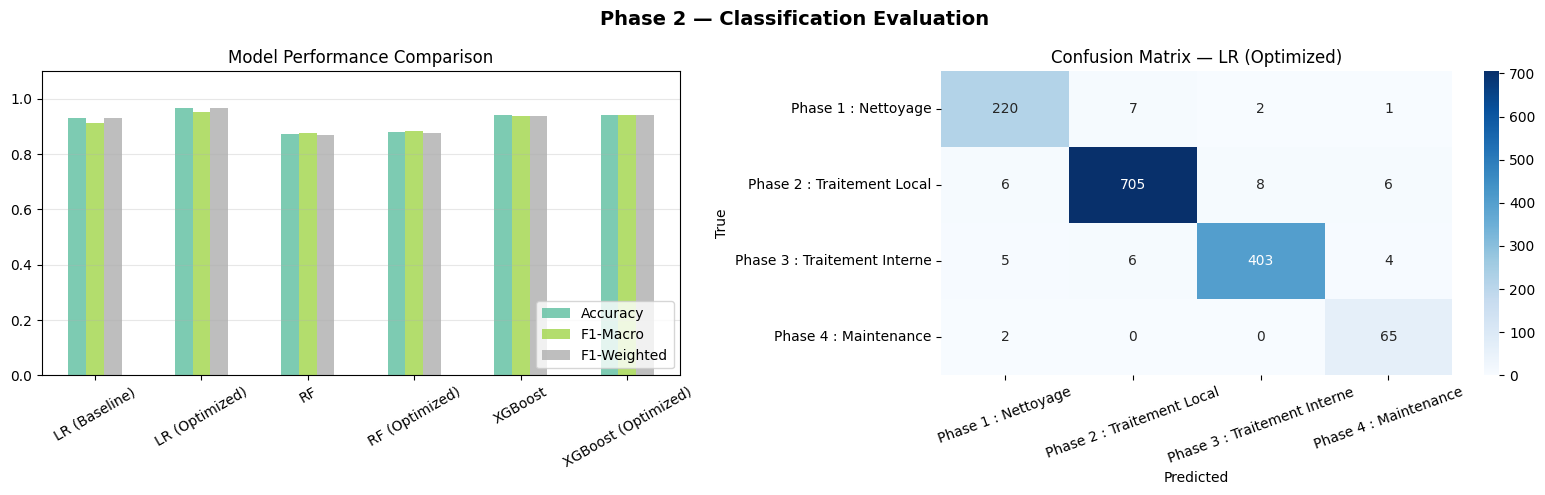

 Saved: phase2_evaluation.png


In [59]:
# ─── Confusion Matrix for best model ─────────────────────────────────────────
model_pred_map_p2 = {
    'LR (Baseline)':         y_pred_lr_p2,
    'LR (Optimized)':        y_pred_lr_opt_p2,
    'RF':                    y_pred_rf_p2,
    'RF (Optimized)':        y_pred_rf_opt_p2,
    'XGBoost':               y_pred_xgb_p2,
    'XGBoost (Optimized)':   y_pred_xgb_opt_p2
}

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 2 — Classification Evaluation', fontsize=14, fontweight='bold')

# Bar chart
ax1 = axes[0]
eval_p2_df[['Accuracy', 'F1-Macro', 'F1-Weighted']].plot(kind='bar', ax=ax1, colormap='Set2', alpha=0.85)
ax1.set_ylim(0, 1.1)
ax1.set_title('Model Performance Comparison')
ax1.set_xlabel('')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='lower right')

# Confusion matrix of best model
ax2 = axes[1]
best_preds_p2 = model_pred_map_p2[best_p2_model_name]
cm = confusion_matrix(y_test_p2, best_preds_p2)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax2,
            xticklabels=le_phase.classes_, yticklabels=le_phase.classes_)
ax2.set_title(f'Confusion Matrix — {best_p2_model_name}')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('True')
ax2.tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig('phase2_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: phase2_evaluation.png")

In [61]:
# ─── Select best Phase 2 model object ────────────────────────────────────────
model_obj_map_p2 = {
    'LR (Baseline)':         lr_p2,
    'LR (Optimized)':        lr_grid_p2.best_estimator_,
    'RF':                    rf_p2,
    'RF (Optimized)':        rf_grid_p2.best_estimator_,
    'XGBoost':               xgb_p2,
    'XGBoost (Optimized)':   xgb_grid_p2.best_estimator_
}
best_phase_clf = model_obj_map_p2[best_p2_model_name]
print(f" Best Phase 2 classifier selected: {best_p2_model_name}")

 Best Phase 2 classifier selected: LR (Optimized)


In [63]:
# =============================================
# 💾 SAVE PHASE 2 MODEL (LOGISTIC REGRESSION)
# =============================================

import joblib
import os

# Create deployment folder
os.makedirs('deployment', exist_ok=True)

print("=" * 60)
print("💾 SAVING PHASE 2 MODEL")
print("=" * 60)

# =============================================
# Save the best Logistic Regression model
# =============================================
joblib.dump(lr_grid_p2.best_estimator_, 'deployment/phase2_classifier.joblib')
print("✅ Phase 2 classifier saved: deployment/phase2_classifier.joblib")

# =============================================
# Save the label encoder (phase names)
# =============================================
joblib.dump(le_phase, 'deployment/phase2_label_encoder.joblib')
print("✅ Label encoder saved: deployment/phase2_label_encoder.joblib")

# =============================================
# Save PCA if you used it (optional)
# =============================================
if 'pca' in dir() and pca is not None:
    joblib.dump(pca, 'deployment/phase2_pca.joblib')
    print("✅ PCA saved: deployment/phase2_pca.joblib")

# =============================================
# Test reload
# =============================================
print("\n" + "-" * 40)
print("🔧 TESTING RELOAD")
print("-" * 40)

# Test classifier
loaded_clf = joblib.load('deployment/phase2_classifier.joblib')
print(f"✅ Classifier loaded: {type(loaded_clf).__name__}")

# Test label encoder
loaded_le = joblib.load('deployment/phase2_label_encoder.joblib')
print(f"✅ Label encoder loaded: {type(loaded_le).__name__}")
print(f"   Classes: {loaded_le.classes_.tolist()}")

print("\n✅ Phase 2 models saved successfully!")

💾 SAVING PHASE 2 MODEL
✅ Phase 2 classifier saved: deployment/phase2_classifier.joblib
✅ Label encoder saved: deployment/phase2_label_encoder.joblib

----------------------------------------
🔧 TESTING RELOAD
----------------------------------------
✅ Classifier loaded: LogisticRegression
✅ Label encoder loaded: LabelEncoder
   Classes: ['Phase 1 : Nettoyage', 'Phase 2 : Traitement Local', 'Phase 3 : Traitement Interne', 'Phase 4 : Maintenance']

✅ Phase 2 models saved successfully!


### Phase 3 : Product Ranking 

In [66]:
# =============================================
# Build Ranking Dataset (Using Hybrid Model)
# =============================================

def build_ranking_dataset_hybrid(df, hybrid_model, mpnet_embeddings, le_phase, 
                                  n_queries=800, top_k=20):
    """
    Build pointwise ranking dataset using Phase 1 Hybrid Model.
    
    Features:
    - q_emb - prod_emb: Difference embedding (768 dims)
    - q_emb * prod_emb: Interaction embedding (768 dims)
    - similarity_score: Phase 1 hybrid score (1 dim)
    - rank: Position in initial retrieval (1 dim)
    - phase: Candidate product phase (1 dim)
    
    Total features: 768 + 768 + 1 + 1 + 1 = 1539 dims
    """
    sample_idx = df.sample(n=min(n_queries, len(df)), random_state=42).index.tolist()
    rows = []
    
    print(f" Building ranking dataset with {len(sample_idx)} queries...")
    
    for progress, idx in enumerate(sample_idx):
        if progress % 100 == 0:
            print(f"   Processing query {progress}/{len(sample_idx)}...")
        
        row = df.loc[idx]
        query_syms = set(str(row['symptoms_spacy_lemmatized']).split(','))
        
        # Use Hybrid Model for retrieval (Phase 1)
        results = hybrid_model.retrieve(row['symptoms_spacy_lemmatized'], top_k=top_k)
        
        q_emb = mpnet_embeddings[idx]  # Use MPNet (consistent with Phase 1)
        
        for rank, (_, res) in enumerate(results.iterrows()):
            prod_idx = df[df['produit'] == res['produit']].index
            if len(prod_idx) == 0:
                continue
            prod_idx = prod_idx[0]
            prod_emb = mpnet_embeddings[prod_idx]
            
            # Ground truth: shares at least one symptom
            ret_syms = set(str(res['symptoms_spacy_lemmatized']).split(','))
            label = 1 if len(query_syms & ret_syms) > 0 else 0
            
            # Feature vector
            feat = np.concatenate([
                q_emb - prod_emb,                      # 768 dims
                q_emb * prod_emb,                      # 768 dims
                [res['similarity_score']],             # 1 dim
                [rank / top_k],                        # 1 dim (normalized rank)
                [le_phase.transform([res['phase']])[0] / 3]  # 1 dim (normalized phase)
            ])
            rows.append((*feat, label))
    
    # Create DataFrame
    n_features = len(rows[0]) - 1
    feature_cols = [f'f{i}' for i in range(n_features)] + ['label']
    ranking_df = pd.DataFrame(rows, columns=feature_cols)
    
    return ranking_df

# Build the dataset
print("\n Building ranking dataset using Hybrid Model...")
ranking_df = build_ranking_dataset_hybrid(
    df=df,
    hybrid_model=hybrid_model,
    mpnet_embeddings=mpnet_embeddings,
    le_phase=le_phase,
    n_queries=800,
    top_k=20
)

print(f"\n Ranking dataset: {ranking_df.shape}")
print(f"   Label distribution: {ranking_df['label'].value_counts().to_dict()}")
print(f"   Positive ratio: {ranking_df['label'].mean():.3f}")



 Building ranking dataset using Hybrid Model...
 Building ranking dataset with 800 queries...
   Processing query 0/800...
   Processing query 100/800...
   Processing query 200/800...
   Processing query 300/800...
   Processing query 400/800...
   Processing query 500/800...
   Processing query 600/800...
   Processing query 700/800...

 Ranking dataset: (16122, 1540)
   Label distribution: {1: 12772, 0: 3350}
   Positive ratio: 0.792


In [68]:
X = ranking_df.drop('label', axis=1).values
y = ranking_df['label'].values

print(f"📊 Dataset shape: {X.shape}")
print(f"   Positive samples: {y.sum()} ({y.mean()*100:.1f}%)")
print(f"   Negative samples: {len(y) - y.sum()} ({(1-y.mean())*100:.1f}%)")

# =============================================
# Train/Test Split
# =============================================
from sklearn.model_selection import train_test_split

X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\n📊 Train set: {X_train_r.shape[0]} samples")
print(f"   Test set: {X_test_r.shape[0]} samples")

📊 Dataset shape: (16122, 1539)
   Positive samples: 12772 (79.2%)
   Negative samples: 3350 (20.8%)

📊 Train set: 12897 samples
   Test set: 3225 samples


### Baseline Model (Logistic Regression ):

In [71]:
# ─── LR Ranking Baseline ─────────────────────────────────────────────────────
lr_rank = LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced')
lr_rank.fit(X_train_r, y_train_r)

y_pred_lr_r = lr_rank.predict(X_test_r)
y_prob_lr_r = lr_rank.predict_proba(X_test_r)[:, 1]
print("📊 LR Ranking Baseline")
print(classification_report(y_test_r, y_pred_lr_r, target_names=['Not Relevant', 'Relevant']))

📊 LR Ranking Baseline
              precision    recall  f1-score   support

Not Relevant       0.41      0.69      0.51       670
    Relevant       0.90      0.74      0.81      2555

    accuracy                           0.73      3225
   macro avg       0.65      0.71      0.66      3225
weighted avg       0.80      0.73      0.75      3225



In [73]:
# ─── LR Ranking with GridSearchCV ─────────────────────────────────────────────
lr_rank_grid = GridSearchCV(
    LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'saga']},
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)
lr_rank_grid.fit(X_train_r, y_train_r)

y_pred_lr_rank_opt = lr_rank_grid.best_estimator_.predict(X_test_r)
y_prob_lr_rank_opt = lr_rank_grid.best_estimator_.predict_proba(X_test_r)[:, 1]
print(f"✅ LR Ranking best params: {lr_rank_grid.best_params_}")
print(classification_report(y_test_r, y_pred_lr_rank_opt, target_names=['Not Relevant', 'Relevant']))

✅ LR Ranking best params: {'C': 10, 'solver': 'saga'}
              precision    recall  f1-score   support

Not Relevant       0.45      0.74      0.56       670
    Relevant       0.92      0.77      0.84      2555

    accuracy                           0.76      3225
   macro avg       0.69      0.75      0.70      3225
weighted avg       0.82      0.76      0.78      3225



### Model 1 : Random Forest

In [76]:
# ─── RF Ranking ───────────────────────────────────────────────────────────────
rf_rank = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)
rf_rank.fit(X_train_r, y_train_r)

y_pred_rf_r = rf_rank.predict(X_test_r)
y_prob_rf_r = rf_rank.predict_proba(X_test_r)[:, 1]
print("📊 Random Forest Ranking")
print(classification_report(y_test_r, y_pred_rf_r, target_names=['Not Relevant', 'Relevant']))

📊 Random Forest Ranking
              precision    recall  f1-score   support

Not Relevant       0.96      0.14      0.24       670
    Relevant       0.82      1.00      0.90      2555

    accuracy                           0.82      3225
   macro avg       0.89      0.57      0.57      3225
weighted avg       0.84      0.82      0.76      3225



In [78]:
# ─── RF Ranking with GridSearchCV ─────────────────────────────────────────────
rf_rank_grid = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    {
        'n_estimators': [100, 300],
        'max_depth': [None, 20],
        'min_samples_split': [2, 5],
        'max_features': ['sqrt', 'log2']
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)
rf_rank_grid.fit(X_train_r, y_train_r)

y_pred_rf_rank_opt = rf_rank_grid.best_estimator_.predict(X_test_r)
y_prob_rf_rank_opt = rf_rank_grid.best_estimator_.predict_proba(X_test_r)[:, 1]
print(f"✅ RF Ranking best params: {rf_rank_grid.best_params_}")
print(classification_report(y_test_r, y_pred_rf_rank_opt, target_names=['Not Relevant', 'Relevant']))

✅ RF Ranking best params: {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_split': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

Not Relevant       0.92      0.16      0.27       670
    Relevant       0.82      1.00      0.90      2555

    accuracy                           0.82      3225
   macro avg       0.87      0.58      0.58      3225
weighted avg       0.84      0.82      0.77      3225



### Model 2 : XGboost

In [81]:
# ─── XGBoost Ranking ──────────────────────────────────────────────────────────
xgb_rank = XGBClassifier(
    n_estimators=300, learning_rate=0.1, max_depth=6,
    use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1
)
xgb_rank.fit(X_train_r, y_train_r)

y_pred_xgb_r = xgb_rank.predict(X_test_r)
y_prob_xgb_r = xgb_rank.predict_proba(X_test_r)[:, 1]
print("📊 XGBoost Ranking")
print(classification_report(y_test_r, y_pred_xgb_r, target_names=['Not Relevant', 'Relevant']))

📊 XGBoost Ranking
              precision    recall  f1-score   support

Not Relevant       0.90      0.53      0.67       670
    Relevant       0.89      0.98      0.93      2555

    accuracy                           0.89      3225
   macro avg       0.89      0.76      0.80      3225
weighted avg       0.89      0.89      0.88      3225



In [83]:
# ─── XGBoost Ranking with GridSearchCV ────────────────────────────────────────
xgb_rank_grid = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),
    {
        'n_estimators': [200],      # Fixed
        'learning_rate': [0.1],     # Fixed  
        'max_depth': [6, 8],        # 2 options
        'subsample': [0.8]          # Fixed
    },
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1',
    n_jobs=-1
)
xgb_rank_grid.fit(X_train_r, y_train_r)

y_pred_xgb_rank_opt = xgb_rank_grid.best_estimator_.predict(X_test_r)
y_prob_xgb_rank_opt = xgb_rank_grid.best_estimator_.predict_proba(X_test_r)[:, 1]
print(f"✅ XGBoost Ranking best params: {xgb_rank_grid.best_params_}")
print(classification_report(y_test_r, y_pred_xgb_rank_opt, target_names=['Not Relevant', 'Relevant']))

✅ XGBoost Ranking best params: {'learning_rate': 0.1, 'max_depth': 8, 'n_estimators': 200, 'subsample': 0.8}
              precision    recall  f1-score   support

Not Relevant       0.91      0.49      0.64       670
    Relevant       0.88      0.99      0.93      2555

    accuracy                           0.88      3225
   macro avg       0.89      0.74      0.79      3225
weighted avg       0.89      0.88      0.87      3225



### Phase 3 : Evaluation

In [86]:
# ─── Phase 3 Evaluation Summary ───────────────────────────────────────────────
def ranking_summary(name, y_true, y_pred, y_prob):
    return {
        'Model':     name,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'F1':        round(f1_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred), 4),
        'Recall':    round(recall_score(y_true, y_pred), 4),
        'ROC-AUC':   round(roc_auc_score(y_true, y_prob), 4)
    }

eval_results_p3 = [
    ranking_summary('LR (Baseline)',      y_test_r, y_pred_lr_r,         y_prob_lr_r),
    ranking_summary('LR (Optimized)',     y_test_r, y_pred_lr_rank_opt,  y_prob_lr_rank_opt),
    ranking_summary('RF',                 y_test_r, y_pred_rf_r,         y_prob_rf_r),
    ranking_summary('RF (Optimized)',     y_test_r, y_pred_rf_rank_opt,  y_prob_rf_rank_opt),
    ranking_summary('XGBoost',            y_test_r, y_pred_xgb_r,        y_prob_xgb_r),
    ranking_summary('XGBoost (Optimized)',y_test_r, y_pred_xgb_rank_opt, y_prob_xgb_rank_opt)
]

eval_p3_df = pd.DataFrame(eval_results_p3).set_index('Model')
print(" Phase 3 — Ranking Results:")
display(eval_p3_df.style.highlight_max(axis=0, color='#d5f5d5').format('{:.4f}'))

best_p3_model_name = eval_p3_df['ROC-AUC'].idxmax()
print(f"\n Best Phase 3 Model: {best_p3_model_name}  (ROC-AUC: {eval_p3_df.loc[best_p3_model_name, 'ROC-AUC']:.4f})")

 Phase 3 — Ranking Results:


,Accuracy,F1,Precision,Recall,ROC-AUC
Model,,,,,
LR (Baseline),0.7281,0.8114,0.9003,0.7386,0.7621
LR (Optimized),0.7609,0.8356,0.9180,0.7667,0.8201
RF,0.8192,0.8974,0.8150,0.9984,0.9155
RF (Optimized),0.8217,0.8985,0.8181,0.9965,0.9003
XGBoost,0.8902,0.9343,0.8887,0.9847,0.9388
XGBoost (Optimized),0.8843,0.9311,0.8815,0.9867,0.9384



 Best Phase 3 Model: XGBoost  (ROC-AUC: 0.9388)


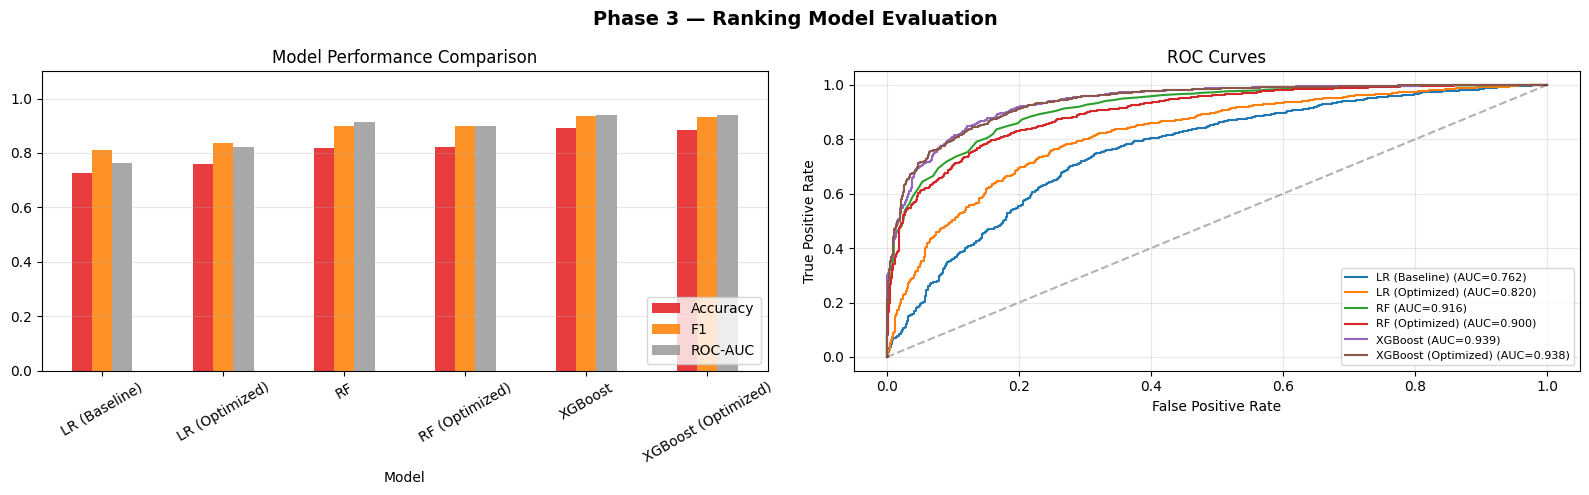

 Saved: phase3_evaluation.png


In [88]:
# ─── Phase 3 Evaluation Plots ─────────────────────────────────────────────────
from sklearn.metrics import roc_curve, auc

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Phase 3 — Ranking Model Evaluation', fontsize=14, fontweight='bold')

# Bar chart
ax1 = axes[0]
eval_p3_df[['Accuracy', 'F1', 'ROC-AUC']].plot(kind='bar', ax=ax1, colormap='Set1', alpha=0.85)
ax1.set_ylim(0, 1.1)
ax1.set_title('Model Performance Comparison')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='y', alpha=0.3)
ax1.legend(loc='lower right')

# ROC curves
ax2 = axes[1]
prob_map = {
    'LR (Baseline)':       y_prob_lr_r,
    'LR (Optimized)':      y_prob_lr_rank_opt,
    'RF':                  y_prob_rf_r,
    'RF (Optimized)':      y_prob_rf_rank_opt,
    'XGBoost':             y_prob_xgb_r,
    'XGBoost (Optimized)': y_prob_xgb_rank_opt
}
for model_name, probs in prob_map.items():
    fpr, tpr, _ = roc_curve(y_test_r, probs)
    auc_score = auc(fpr, tpr)
    ax2.plot(fpr, tpr, label=f"{model_name} (AUC={auc_score:.3f})")

ax2.plot([0,1], [0,1], 'k--', alpha=0.3)
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('ROC Curves')
ax2.legend(loc='lower right', fontsize=8)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('phase3_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print(" Saved: phase3_evaluation.png")

In [90]:
# ─── Select best Phase 3 model ────────────────────────────────────────────────
model_obj_map_p3 = {
    'LR (Baseline)':        lr_rank,
    'LR (Optimized)':       lr_rank_grid.best_estimator_,
    'RF':                   rf_rank,
    'RF (Optimized)':       rf_rank_grid.best_estimator_,
    'XGBoost':              xgb_rank,
    'XGBoost (Optimized)':  xgb_rank_grid.best_estimator_
}
best_ranking_clf = model_obj_map_p3[best_p3_model_name]
print(f"✅ Best Phase 3 classifier selected: {best_p3_model_name}")

✅ Best Phase 3 classifier selected: XGBoost


In [96]:
# =============================================
# 💾 SAVE PHASE 3 MODEL (XGBoost - NO SCALER NEEDED)
# =============================================

import joblib
import os

os.makedirs('deployment', exist_ok=True)

print("=" * 60)
print("💾 SAVING PHASE 3 MODEL")
print("=" * 60)

# Save the best ranking model (XGBoost from GridSearch)
joblib.dump(xgb_rank_grid.best_estimator_, 'deployment/phase3_ranker.joblib')
print(f"✅ Phase 3 ranker saved: XGBoost")

# Note: XGBoost doesn't require feature scaling!
print("ℹ️  XGBoost is tree-based → no scaler needed")

print("\n✅ Phase 3 model saved successfully!")

💾 SAVING PHASE 3 MODEL
✅ Phase 3 ranker saved: XGBoost
ℹ️  XGBoost is tree-based → no scaler needed

✅ Phase 3 model saved successfully!


## DSO2

In [1]:
pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 32.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=f830f21e5601b4f27ac0d625b2cb4fd7b98b7f1af148b65d7c9f41e7662da825
  Stored in directory: /root/.cache/pip/wheels/c1/67/88/e844b5b022812e15a52e4eaa38a1e709e99f06f6639d7e3ba7
Successfully built langdetect


In [26]:
"""
AVATAR DSO2 - Model 1: Intent Classification (LLM + RAG) - ENHANCED v2
Addresses: other intent failure, question over-prediction, closing recall,
            objection boundary, confidence-based post-processing
"""

import requests
import json
import re
import time
import math
import pandas as pd
from langdetect import detect


# -------------------------------
# 1. LOAD PRODUCTS FROM EXCEL
# -------------------------------
def load_products_cleaned(path="produits_final_complet.xlsx"):
    df = pd.read_excel(path)

    product_col = None
    for col in df.columns:
        if str(col).strip().lower() in ["produit", "product", "nom", "name"]:
            product_col = col
            break

    if product_col is None:
        raise ValueError(f"Could not find product name column. Available columns: {list(df.columns)}")

    product_info = {}

    for _, row in df.iterrows():
        product = str(row.get(product_col, "")).strip().upper()
        if not product or product == "NAN":
            continue

        product_info[product] = {
            str(col).strip(): str(row.get(col, "")).strip()
            for col in df.columns
        }

    print(f"Loaded {len(product_info)} products with columns: {list(df.columns)}")
    return product_info


# -------------------------------
# 2. ENHANCED MODEL 1 CLASS
# -------------------------------
class Model1_LLM_RAG_Enhanced:
    def __init__(self, api_key, product_info):
        self.api_key = api_key
        self.api_url = "https://api.groq.com/openai/v1/chat/completions"
        self.product_info = product_info

        # === CLOSING PATTERNS (DIRECT + INDIRECT) ===
        self.closing_direct = [
            "voulez-vous", "souhaitez-vous", "puis-je", "shall we",
            "would you like", "can i leave", "do you want", "can we add",
            "essayer", "prescrire", "prescription", "échantillons", "samples",
            "want to try", "leave you with", "start with", "begin with",
            "voulez", "souhaitez", "puis"
        ]
        self.closing_indirect = [
            "don't you think", "n'est-ce pas", "ne pensez-vous pas",
            "ready to try", "prêt à essayer", "shall we start",
            "ready to start", "commençons", "shall we proceed"
        ]
        self.closing_action_verbs = [
            "start", "begin", "commencer", "order", "commander",
            "sign", "signer", "try", "essayer", "proceed", "continuer"
        ]
        # Wh-questions that imply commitment intent (closing, not question)
        self.closing_wh = [
            "when can we", "when should we", "where do i", "where can i",
            "who should i contact", "qui dois-je contacter",
            "how do we start", "comment commencer"
        ]

        # === OBJECTION PATTERNS (DIRECT + DISGUISED) ===
        self.objection_direct = [
            "trop cher", "too expensive", "cheaper", "generic", "générique",
            "effets secondaires", "side effects", "pas sûr", "not sure",
            "doute", "doubt", "tolerance", "tolérance", "safety", "sécurité",
            "risk", "risque", "dangerous", "dangereux", "contraindicated",
            "contraindication", "hésitant", "hesitant", "préfère", "prefer",
            "concerned", "inquiétude", "worried", "préoccupé", "allergies",
            "allergic", "allergique"
        ]
        self.objection_disguised_starters = [
            "how come", "why is", "why should i", "pourquoi",
            "why would i", "why change"
        ]
        self.objection_comparative = [
            "worse than", "better than", "compared to", "versus", "vs",
            "more than", "less than", "autre produit", "other product",
            "current treatment", "traitement actuel", "déjà utilisé", "already use"
        ]

        # === "OTHER" DETECTION ===
        self.other_min_length = 4  # Minimum word count for non-other
        self.other_ambiguous = [
            "ok", "okay", "d'accord", "bien", "hm", "hmm", "uh",
            "ah", "oh", "euh", "ben", "alors", "bon", "maybe",
            "peut-être", "perhaps", "possibly", "i see", "je vois",
            "interesting", "intéressant", "not now", "pas maintenant",
            "later", "plus tard", "we'll see", "on verra"
        ]
        self.other_starters = [
            "ok", "okay", "hm", "hmm", "uh", "ah", "oh", "euh",
            "maybe", "perhaps", "not now", "we'll see", "i see",
            "interesting", "intéressant"
        ]

        # === EVIDENCE KEYWORDS ===
        self.evidence_keywords = [
            "étude", "study", "clinical", "clinique", "lancet", "jama",
            "nejm", "pubmed", "phase", "trial", "research", "publication",
            "data", "données", "résultats", "results", "prouve", "proves",
            "démontré", "demonstrated", "show", "montrent", "versus",
            "vs", "comparative", "comparatif", "meta-analysis", "méta-analyse",
            "cohorte", "cohort", "randomized", "randomisé", "p value",
            "significant", "significatif", "efficacy", "efficacité",
            "superior", "supérieur", "non-inferior", "non-inférieur"
        ]

    # -------------------------------
    # 3. RAG RETRIEVAL
    # -------------------------------
    def retrieve_product_context(self, text):
        text_lower = text.lower()
        context = []
        for product, info in self.product_info.items():
            if product.lower() in text_lower:
                context.append({"name": product, **info})
        return context

    # -------------------------------
    # 4. ENHANCED PROMPT WITH FEW-SHOT EXAMPLES
    # -------------------------------
    def build_prompt(self, text, context):
        return f"""You are an expert medical sales conversation analyzer. Classify delegate message intent precisely and conservatively.

Message: "{text}"

Available product data (RAG):
{json.dumps(context, indent=2, ensure_ascii=False)}

INTENT DEFINITIONS:
1. introduction → Presenting a product for the first time to this doctor
2. benefit → Explaining advantages, results, effects, or patient outcomes
3. evidence → Citing studies, clinical trials, publications, or comparative data
4. objection → Doctor expresses concern, doubt, resistance, price issue, comparison, safety worry, or preference for alternative
5. question → Neutral request for factual information WITHOUT expressing doubt or resistance
6. closing → Asking for commitment, prescription, trial, next step, or any action/decision from doctor
7. other → Message too short, ambiguous, non-committal (ok, hmm, maybe, not now, we'll see), or unclear intent

CRITICAL DISTINCTIONS:
- "Are you sure...?" / "Can you guarantee...?" → question (neutral verification, no resistance expressed)
- "Why is this more expensive...?" / "How come results are worse...?" → objection (resistance + comparison)
- "When can we start?" / "Where do I sign?" → closing (action/commitment implied)
- "Don't you think this would help?" → closing (seeking agreement/commitment)
- "Hmm", "OK", "Maybe", "I see", "Not now" → other (ambiguous/short)
- Messages with "why" + comparison/alternative → objection, NOT question
- Messages with "when/where/who" + action verb → closing, NOT question

RULES:
- If message asks for ANY action/decision from doctor → closing
- If message expresses doubt/concern/resistance/comparison → objection (NOT question)
- If message asks neutral facts without resistance → question
- If message cites data/studies → evidence
- If message explains product effects → benefit
- If message presents product for first time → introduction
- If message is <4 words OR ambiguous/non-committal → other

FEW-SHOT EXAMPLES:
Message: "Are you sure this won't cause allergies?"
→ {{"intent": "question", "product": null, "claims": [], "language": "en"}}

Message: "Why is this more expensive than the generic?"
→ {{"intent": "objection", "product": null, "claims": ["price concern"], "language": "en"}}

Message: "When can we start the trial?"
→ {{"intent": "closing", "product": null, "claims": [], "language": "en"}}

Message: "Your patients would love the results, shall we start?"
→ {{"intent": "closing", "product": null, "claims": [], "language": "en"}}

Message: "Ok..."
→ {{"intent": "other", "product": null, "claims": [], "language": "en"}}

Message: "Hmm, interesting"
→ {{"intent": "other", "product": null, "claims": [], "language": "en"}}

Message: "Not now"
→ {{"intent": "other", "product": null, "claims": [], "language": "en"}}

Message: "A 2023 study in JAMA proves it reduces inflammation by 50%"
→ {{"intent": "evidence", "product": null, "claims": ["reduces inflammation by 50%"], "language": "en"}}

Return ONLY valid JSON. No explanation. No markdown code blocks.

Output format:
{{"intent": "one of: introduction, benefit, evidence, objection, question, closing, other", "product": "... or null", "claims": [], "language": "fr or en"}}"""

    # -------------------------------
    # 5. CALL LLM WITH RETRY & RATE LIMITING
    # -------------------------------
    def call_llm(self, prompt, max_retries=3):
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        payload = {
            "model": "llama-3.1-8b-instant",
            "messages": [
                {"role": "system", "content": "You are a precise intent classifier. You always return ONLY valid JSON. Never explain. Never use markdown code blocks."},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0.0,
            "max_tokens": 200
        }

        for attempt in range(max_retries):
            try:
                response = requests.post(self.api_url, headers=headers, json=payload, timeout=15)

                if response.status_code == 200:
                    result = response.json()
                    return result["choices"][0]["message"]["content"]

                elif response.status_code == 429:
                    # Exponential backoff with jitter
                    wait_time = (2 ** attempt) * 2 + (attempt * 0.5)
                    print(f"   Rate limited (429). Waiting {wait_time:.1f}s before retry {attempt+1}/{max_retries}...")
                    time.sleep(wait_time)
                    continue

                else:
                    print(f"   API Error {response.status_code}: {response.text[:150]}")
                    return None

            except requests.exceptions.Timeout:
                print(f"   Request timeout. Retry {attempt+1}/{max_retries}...")
                time.sleep(2 ** attempt)
                continue
            except Exception as e:
                print(f"   Request failed: {e}")
                time.sleep(1)
                continue

        print("   Max retries reached. Returning None.")
        return None

    # -------------------------------
    # 6. SAFE JSON PARSING
    # -------------------------------
    def safe_parse(self, text):
        if not text:
            return self._default_response()

        # Clean common LLM formatting issues
        text = text.strip()
        if text.startswith("```json"):
            text = text[7:]
        if text.startswith("```"):
            text = text[3:]
        if text.endswith("```"):
            text = text[:-3]
        text = text.strip()

        try:
            return json.loads(text)
        except:
            pass

        try:
            match = re.search(r"\{[^{}]*\}", text, re.DOTALL)
            if match:
                return json.loads(match.group())
        except:
            pass

        try:
            match = re.search(r"\{.*\}", text, re.DOTALL)
            if match:
                return json.loads(match.group())
        except:
            pass

        return self._default_response()

    def _default_response(self):
        return {"intent": "other", "product": None, "claims": [], "language": "en"}

    # -------------------------------
    # 7. SMART POST-PROCESSING WITH CONFIDENCE SCORING
    # -------------------------------

    def _is_likely_other(self, text):
        """Detect ambiguous/short messages that should be 'other'."""
        text_lower = text.lower().strip()
        words = text_lower.split()

        # Very short messages (< 4 words)
        if len(words) < self.other_min_length:
            # Check if it's a known ambiguous phrase
            if any(text_lower.startswith(phrase) for phrase in self.other_starters):
                return True
            # Single-word or very short non-substantive responses
            if len(words) <= 2 and not any(
                text_lower.startswith(q) for q in [
                    "what", "how", "why", "when", "where", "who",
                    "quel", "quelle", "comment", "pourquoi", "quand", "où", "qui"
                ]
            ):
                return True

        # Known ambiguous phrases anywhere in short messages
        if len(words) <= 5:
            for phrase in self.other_ambiguous:
                if phrase in text_lower:
                    return True

        return False

    def _is_closing(self, text):
        """Detect closing intent including indirect patterns."""
        text_lower = text.lower()

        # Direct closing keywords with action verbs
        if any(kw in text_lower for kw in self.closing_direct):
            return True

        # Ind closing patterns (tag questions seeking commitment)
        if any(kw in text_lower for kw in self.closing_indirect):
            return True

        # Wh-words + action verbs = commitment questions (closing)
        if any(kw in text_lower for kw in self.closing_wh):
            return True

        return False

    def _is_objection(self, text):
        """Detect objection including disguised forms."""
        text_lower = text.lower()

        # Direct objection keywords
        if any(kw in text_lower for kw in self.objection_direct):
            return True

        # Disguised objections: "Why is X worse/expensive...?" or "How come...?"
        if any(kw in text_lower for kw in self.objection_disguised_starters):
            if any(comp in text_lower for comp in self.objection_comparative):
                return True
            # Even without explicit comparison, "why is/should" often signals resistance
            if "why should i" in text_lower or "why would i" in text_lower:
                return True

        # Objection through comparison
        if any(comp in text_lower for comp in self.objection_comparative):
            # Check if it's a delegate making comparison (benefit) or doctor resisting
            doctor_indicators = ["i ", "my ", "mes ", "je ", "mon ", "moi"]
            if any(ind in text_lower for ind in doctor_indicators):
                return True

        return False

    def _is_evidence(self, text):
        """Detect evidence intent."""
        text_lower = text.lower()
        return any(kw in text_lower for kw in self.evidence_keywords)

    def post_process_intent(self, text, llm_intent):
        """
        Enhanced post-processing that respects LLM decisions unless
        there is strong contradictory evidence.
        Priority: other > closing > objection > evidence > llm_intent
        """
        text_lower = text.lower()

        # === PRIORITY 1: "OTHER" DETECTION ===
        # Override everything for ambiguous/short messages
        if self._is_likely_other(text):
            # Only keep non-ambiguous intents if LLM is very confident
            if llm_intent in ["introduction", "benefit", "evidence"]:
                # Check if there's actual substance
                words = text_lower.split()
                if len(words) >= 4 and not any(p in text_lower for p in self.other_ambiguous):
                    return llm_intent
            return "other"

        # === PRIORITY 2: CLOSING DETECTION ===
        if self._is_closing(text):
            # Strong closing signal overrides question/benefit/other
            if llm_intent in ["question", "benefit", "other"]:
                return "closing"
            # If LLM said objection but it's a closing pattern, respect closing
            if llm_intent == "objection":
                # Only override objection if clear action verb present
                if any(v in text_lower for v in self.closing_action_verbs):
                    return "closing"

        # === PRIORITY 3: OBJECTION DETECTION ===
        if self._is_objection(text):
            # Strong objection signal overrides question/introduction/benefit
            if llm_intent in ["question", "introduction", "benefit"]:
                return "objection"

        # === PRIORITY 4: EVIDENCE CHECK ===
        if self._is_evidence(text):
            # Only upgrade benefit/introduction to evidence
            if llm_intent in ["benefit", "introduction"]:
                return "evidence"

        # === DEFAULT: Trust the LLM ===
        return llm_intent

    # -------------------------------
    # 8. LANGUAGE DETECTION
    # -------------------------------
    def detect_language(self, text):
        try:
            lang = detect(text)
            return "fr" if lang == "fr" else "en"
        except:
            return "en"

    # -------------------------------
    # 9. MAIN ANALYSIS FUNCTION
    # -------------------------------
    def analyze_message(self, text):
        # Step 1: RAG retrieval
        context = self.retrieve_product_context(text)

        # Step 2: Build enhanced prompt
        prompt = self.build_prompt(text, context)

        # Step 3: Call LLM
        raw_output = self.call_llm(prompt)

        # Step 4: Parse response
        parsed = self.safe_parse(raw_output)

        # Step 5: Smart post-processing
        llm_intent = parsed.get("intent", "other")
        corrected_intent = self.post_process_intent(text, llm_intent)
        parsed["intent"] = corrected_intent

        # Step 6: Language validation
        if not parsed.get("language"):
            parsed["language"] = self.detect_language(text)

        return {
            "text": text,
            "intent": parsed.get("intent", "other"),
            "product": parsed.get("product"),
            "claims": parsed.get("claims", []),
            "language": parsed.get("language"),
            "rag_context_count": len(context),
            "llm_raw_intent": llm_intent  # Debug: what LLM originally said
        }


# -------------------------------
# 10. BATCH PROCESSING WITH RATE LIMITING
# -------------------------------
def analyze_batch(model, messages, delay_between_calls=1.5):
    """
    Process multiple messages with built-in rate limiting.
    Returns list of results.
    """
    results = []
    for i, msg in enumerate(messages):
        result = model.analyze_message(msg)
        results.append(result)
        # Respectful delay between API calls
        if i < len(messages) - 1:
            time.sleep(delay_between_calls)
    return results


# -------------------------------
# 11. USAGE EXAMPLE
# -------------------------------
if __name__ == "__main__":

    # Load products
    product_info = load_products_cleaned("produits_final_complet.xlsx")

    # Initialize enhanced model
    model1 = Model1_LLM_RAG_Enhanced(
        api_key=os.getenv("GROQ_API_KEY"),
        product_info=product_info
    )

    # Test cases covering previous failure modes
    test_cases = [
        # Previous failures that should now be fixed
        ("Ok...", "other"),
        ("Hmm, interesting", "other"),
        ("I see", "other"),
        ("Maybe", "other"),
        ("Not now", "other"),
        ("Are you sure this won't cause allergies?", "question"),
        ("Why is this more expensive than the generic?", "objection"),
        ("How come the results are worse than amlodipine?", "objection"),
        ("Why should I switch when my current treatment works?", "objection"),
        ("When can we start the trial?", "closing"),
        ("Who should I contact to order?", "closing"),
        ("This would really help your diabetic patients, don't you think?", "closing"),
        # Standard cases
        ("Je vous présente notre nouveau sérum anti-âge", "introduction"),
        ("Voulez-vous l'essayer avec vos patients?", "closing"),
    ]

    print("=" * 70)
    print("ENHANCED MODEL 1 - QUICK VALIDATION")
    print("=" * 70)

    correct = 0
    for msg, expected in test_cases:
        result = model1.analyze_message(msg)
        pred = result["intent"]
        status = "✅" if pred == expected else "❌"
        if pred == expected:
            correct += 1
        print(f"{status} Expected: {expected:12s} | Got: {pred:12s} | {msg[:50]}...")
        time.sleep(1.5)  # Rate limiting between calls

    print(f"\nQuick validation: {correct}/{len(test_cases)} passed")

Loaded 7179 products with columns: ['gamme', 'produit', 'indication', 'posologie', 'symptoms_spacy_lemmatized', 'form', 'phase']
ENHANCED MODEL 1 - QUICK VALIDATION
✅ Expected: other        | Got: other        | Ok......
✅ Expected: other        | Got: other        | Hmm, interesting...
✅ Expected: other        | Got: other        | I see...
✅ Expected: other        | Got: other        | Maybe...
✅ Expected: other        | Got: other        | Not now...
❌ Expected: question     | Got: objection    | Are you sure this won't cause allergies?...
✅ Expected: objection    | Got: objection    | Why is this more expensive than the generic?...
   Rate limited (429). Waiting 2.0s before retry 1/3...
✅ Expected: objection    | Got: objection    | How come the results are worse than amlodipine?...
   Rate limited (429). Waiting 2.0s before retry 1/3...
   Rate limited (429). Waiting 4.5s before retry 2/3...
✅ Expected: objection    | Got: objection    | Why should I switch when my current treatme

EVALUATION FOR MODEL 1

Loaded 7179 products with columns: ['gamme', 'produit', 'indication', 'posologie', 'symptoms_spacy_lemmatized', 'form', 'phase']
 MODEL 1 ENHANCED EVALUATION - INTENT CLASSIFICATION
 Test set size: 48 messages
 Clean examples: 20 | Edge cases: 28

Running predictions...
    1. CORRECT True: introduction    | Pred: introduction    | LLM: introduction    | Je vous presente notre nouveau serum ant...
    2. CORRECT True: introduction    | Pred: introduction    | LLM: introduction    | Aujourd'hui je vais vous parler de Ferbi...
    3. CORRECT True: introduction    | Pred: introduction    | LLM: introduction    | Let me introduce our new vitamin D suppl...
    4. CORRECT True: benefit         | Pred: benefit         | LLM: benefit         | Il aide a reduire la fatigue en 2 semain...
    5. CORRECT True: benefit         | Pred: benefit         | LLM: benefit         | Ce produit hydrate intensivement la peau...
    6. FALSE True: benefit         | Pred: evidence        | LLM: benefit      

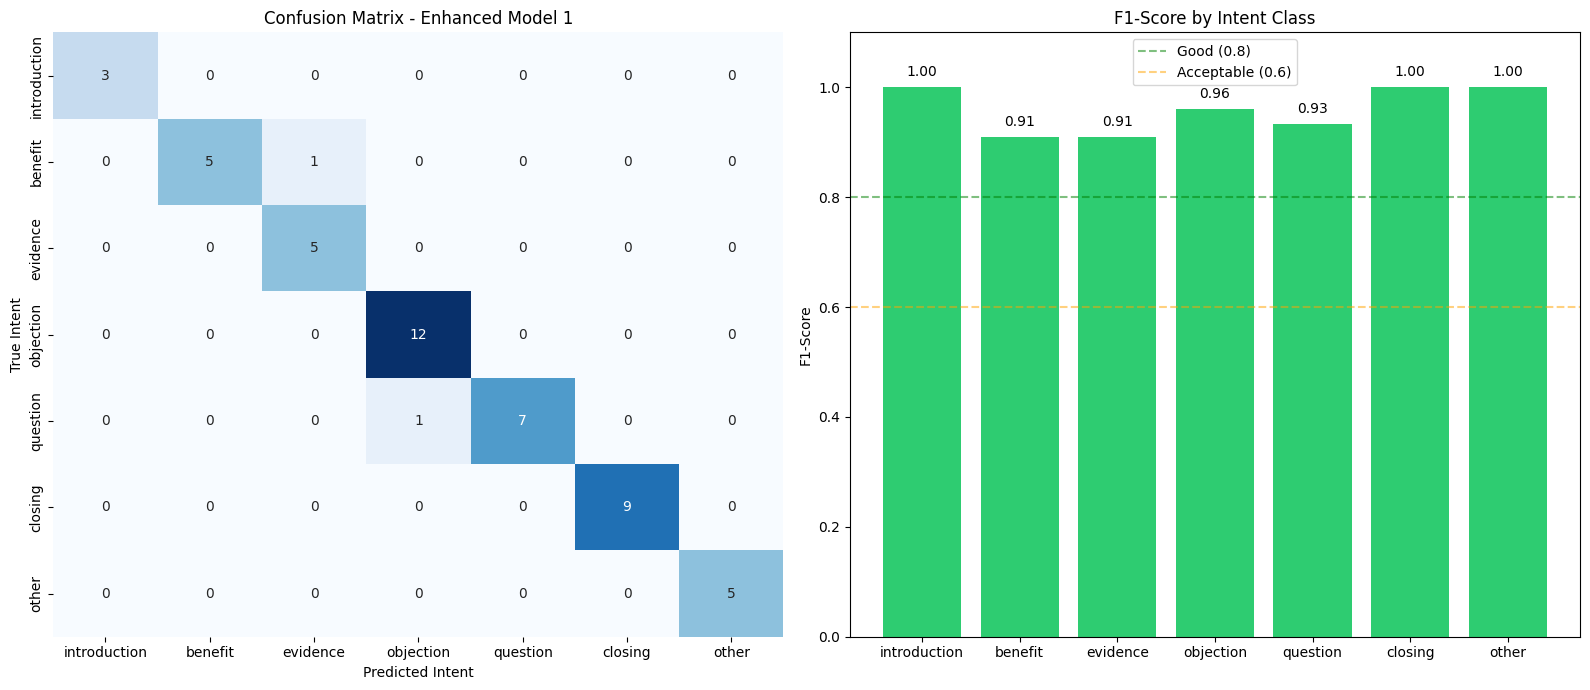

In [27]:
# ============================================================
# CELL 2: EVALUATION (run after the model cell above)
# Model1_LLM_RAG_Enhanced and load_products_cleaned
# are already in memory from Cell 1
# ============================================================

import pandas as pd
import numpy as np
import time
from sklearn.metrics import (
    classification_report, confusion_matrix, f1_score,
    accuracy_score, precision_score, recall_score
)
import seaborn as sns
import matplotlib.pyplot as plt


# -------------------------------
# TEST SET: 48 Messages (Clean + Edge Cases)
# -------------------------------
test_set = [
    # === CLEAN / PROTOTYPICAL (20 messages) ===
    {"text": "Je vous presente notre nouveau serum anti-age", "true_intent": "introduction", "category": "clean"},
    {"text": "Aujourd'hui je vais vous parler de Ferbiotic", "true_intent": "introduction", "category": "clean"},
    {"text": "Let me introduce our new vitamin D supplement", "true_intent": "introduction", "category": "clean"},
    {"text": "Il aide a reduire la fatigue en 2 semaines", "true_intent": "benefit", "category": "clean"},
    {"text": "Ce produit hydrate intensivement la peau", "true_intent": "benefit", "category": "clean"},
    {"text": "It improves skin elasticity by 40%", "true_intent": "benefit", "category": "clean"},
    {"text": "Cette creme protege contre les UV et nourrit en profondeur", "true_intent": "benefit", "category": "clean"},
    {"text": "Une etude clinique de 500 patients le prouve", "true_intent": "evidence", "category": "clean"},
    {"text": "Selon le Lancet, l'efficacite est demontree", "true_intent": "evidence", "category": "clean"},
    {"text": "Clinical trial results show significant improvement", "true_intent": "evidence", "category": "clean"},
    {"text": "C'est trop cher compare a l'ancien produit", "true_intent": "objection", "category": "clean"},
    {"text": "Mes patients ont eu des effets secondaires", "true_intent": "objection", "category": "clean"},
    {"text": "Je ne suis pas sur de la tolerance cutanee", "true_intent": "objection", "category": "clean"},
    {"text": "The generic version is cheaper", "true_intent": "objection", "category": "clean"},
    {"text": "Quelle est la posologie exacte?", "true_intent": "question", "category": "clean"},
    {"text": "Est-ce compatible avec les anticoagulants?", "true_intent": "question", "category": "clean"},
    {"text": "How long should the treatment last?", "true_intent": "question", "category": "clean"},
    {"text": "Voulez-vous l'essayer avec vos patients?", "true_intent": "closing", "category": "clean"},
    {"text": "Puis-je vous laisser des echantillons?", "true_intent": "closing", "category": "clean"},
    {"text": "Shall we add this to your prescription list?", "true_intent": "closing", "category": "clean"},

    # === EDGE CASES / AMBIGUOUS (28 messages) ===
    {"text": "Are you sure this won't cause allergies?", "true_intent": "question", "category": "edge_question_like_objection"},
    {"text": "Can you guarantee there are no interactions?", "true_intent": "question", "category": "edge_question_like_objection"},
    {"text": "Is it really safe for pregnant women?", "true_intent": "question", "category": "edge_question_like_objection"},
    {"text": "Why is this more expensive than the generic?", "true_intent": "objection", "category": "edge_objection_like_question"},
    {"text": "How come the results are worse than amlodipine?", "true_intent": "objection", "category": "edge_objection_like_question"},
    {"text": "Why should I switch when my current treatment works?", "true_intent": "objection", "category": "edge_objection_like_question"},
    {"text": "This would really help your diabetic patients, don't you think?", "true_intent": "closing", "category": "edge_closing_disguised"},
    {"text": "Your patients would love the results, shall we start?", "true_intent": "closing", "category": "edge_closing_disguised"},
    {"text": "It fits perfectly with your practice, ready to try?", "true_intent": "closing", "category": "edge_closing_disguised"},
    {"text": "The study looks good but I'm worried about liver toxicity what do you think?", "true_intent": "objection", "category": "edge_mixed"},
    {"text": "Interesting benefits, though the price is concerning", "true_intent": "objection", "category": "edge_mixed"},
    {"text": "My colleagues like it but I had a bad experience before", "true_intent": "objection", "category": "edge_mixed"},
    {"text": "Ok...", "true_intent": "other", "category": "edge_short"},
    {"text": "Hmm, interesting", "true_intent": "other", "category": "edge_short"},
    {"text": "I see", "true_intent": "other", "category": "edge_short"},
    {"text": "Maybe", "true_intent": "other", "category": "edge_short"},
    {"text": "Not now", "true_intent": "other", "category": "edge_short"},
    {"text": "Le price est too high pour mes patients", "true_intent": "objection", "category": "edge_codeswitch"},
    {"text": "C'est trop expensive compare au generic", "true_intent": "objection", "category": "edge_codeswitch"},
    {"text": "When can we start the trial?", "true_intent": "closing", "category": "edge_closing_indirect"},
    {"text": "Where do I sign for the samples?", "true_intent": "closing", "category": "edge_closing_indirect"},
    {"text": "Who should I contact to order?", "true_intent": "closing", "category": "edge_closing_indirect"},
    {"text": "A 2023 study in JAMA proves it reduces inflammation by 50%", "true_intent": "evidence", "category": "edge_evidence_benefit"},
    {"text": "Research from CHU Lyon shows superior hydration versus competitors", "true_intent": "evidence", "category": "edge_evidence_benefit"},
    {"text": "Patients report feeling more energetic after just one week", "true_intent": "benefit", "category": "edge_benefit_subtle"},
    {"text": "The skin looks visibly younger within 14 days", "true_intent": "benefit", "category": "edge_benefit_subtle"},
    {"text": "What happens if the patient misses a dose?", "true_intent": "question", "category": "edge_question_neutral"},
    {"text": "Do I need to monitor anything during treatment?", "true_intent": "question", "category": "edge_question_neutral"},
]

INTENT_LABELS = ["introduction", "benefit", "evidence", "objection", "question", "closing", "other"]


# -------------------------------
# EVALUATION FUNCTION
# -------------------------------
def evaluate_model(model, test_set, intent_labels, delay_between_calls=1.5):
    print("=" * 70)
    print(" MODEL 1 ENHANCED EVALUATION - INTENT CLASSIFICATION")
    print("=" * 70)

    clean_items = [t for t in test_set if t["category"] == "clean"]
    edge_items = [t for t in test_set if t["category"] != "clean"]
    print(f" Test set size: {len(test_set)} messages")
    print(f" Clean examples: {len(clean_items)} | Edge cases: {len(edge_items)}\n")

    y_true = []
    y_pred = []
    results_detail = []

    print("Running predictions...")
    for i, item in enumerate(test_set, 1):
        text = item["text"]
        true_intent = item["true_intent"]
        category = item.get("category", "unknown")

        result = model.analyze_message(text)
        pred_intent = result.get("intent", "other")
        llm_intent = result.get("llm_raw_intent", "unknown")

        y_true.append(true_intent)
        y_pred.append(pred_intent)

        match = "CORRECT" if pred_intent == true_intent else "FALSE"
        is_edge = " [EDGE]" if category != "clean" else ""
        results_detail.append({
            "msg": text[:55] + "..." if len(text) > 55 else text,
            "true": true_intent,
            "pred": pred_intent,
            "llm_raw": llm_intent,
            "match": match,
            "category": category
        })
        print(f"   {i:2d}.{is_edge} {match} True: {true_intent:15s} | Pred: {pred_intent:15s} | LLM: {llm_intent:15s} | {text[:40]}...")

        if i < len(test_set):
            time.sleep(delay_between_calls)

    # 1. OVERALL METRICS
    print(f"\n{'='*70}")
    print(" OVERALL METRICS")
    print(f"{'='*70}")

    accuracy = accuracy_score(y_true, y_pred)
    macro_f1 = f1_score(y_true, y_pred, average='macro', labels=intent_labels, zero_division=0)
    weighted_f1 = f1_score(y_true, y_pred, average='weighted', labels=intent_labels, zero_division=0)

    print(f" Accuracy:      {accuracy:.2%}")
    print(f" Macro F1:      {macro_f1:.3f}")
    print(f" Weighted F1:   {weighted_f1:.3f}")

    # 2. CLEAN vs EDGE
    print(f"\n{'='*70}")
    print(" CLEAN vs EDGE CASE BREAKDOWN")
    print(f"{'='*70}")

    clean_correct = sum(1 for r in results_detail if r["match"] == "CORRECT" and r["category"] == "clean")
    edge_correct = sum(1 for r in results_detail if r["match"] == "CORRECT" and r["category"] != "clean")

    print(f" Clean set:          {clean_correct}/{len(clean_items)} = {clean_correct/len(clean_items):.1%}")
    print(f" Edge cases:         {edge_correct}/{len(edge_items)} = {edge_correct/len(edge_items):.1%}")

    # 3. EDGE SUBCATEGORIES
    print(f"\n{'='*70}")
    print(" EDGE CASE DETAIL (by subcategory)")
    print(f"{'='*70}")

    edge_categories = {}
    for r in results_detail:
        if r["category"] != "clean":
            cat = r["category"]
            if cat not in edge_categories:
                edge_categories[cat] = {"total": 0, "correct": 0}
            edge_categories[cat]["total"] += 1
            if r["match"] == "CORRECT":
                edge_categories[cat]["correct"] += 1

    for cat, stats in sorted(edge_categories.items()):
        acc = stats["correct"] / stats["total"] if stats["total"] > 0 else 0
        print(f"   {cat:35s}: {stats['correct']:2d}/{stats['total']:2d} = {acc:.1%}")

    # 4. PER-CLASS METRICS
    print(f"\n{'='*70}")
    print(" PER-CLASS METRICS")
    print(f"{'='*70}")
    print(classification_report(y_true, y_pred, labels=intent_labels, digits=3, zero_division=0))

    # 5. CRITICAL INTENTS
    print(f"{'='*70}")
    print(" CRITICAL INTENT ANALYSIS")
    print(f"{'='*70}")

    for intent in ["objection", "closing", "other"]:
        true_binary = [1 if y == intent else 0 for y in y_true]
        pred_binary = [1 if y == intent else 0 for y in y_pred]
        rec = recall_score(true_binary, pred_binary, zero_division=0)
        prec = precision_score(true_binary, pred_binary, zero_division=0)
        f1 = f1_score(true_binary, pred_binary, zero_division=0)
        support = sum(true_binary)
        print(f"\n {intent.upper()}")
        print(f"   Precision: {prec:.2%}")
        print(f"   Recall:    {rec:.2%}")
        print(f"   F1-Score:  {f1:.3f}")
        print(f"   Support:   {support}")

    # 6. LLM vs POST-PROCESSING
    print(f"\n{'='*70}")
    print(" LLM vs POST-PROCESSING ANALYSIS")
    print(f"{'='*70}")

    llm_correct = sum(1 for r, t in zip(results_detail, y_true) if r["llm_raw"] == t)
    post_correct = sum(1 for r in results_detail if r["match"] == "CORRECT")
    overrides_helpful = sum(1 for r, t in zip(results_detail, y_true) if r["llm_raw"] != t and r["pred"] == t)
    overrides_harmful = sum(1 for r, t in zip(results_detail, y_true) if r["llm_raw"] == t and r["pred"] != t)

    print(f" LLM-only accuracy:      {llm_correct}/{len(test_set)} = {llm_correct/len(test_set):.1%}")
    print(f" With post-processing:   {post_correct}/{len(test_set)} = {post_correct/len(test_set):.1%}")
    print(f" Helpful overrides:      {overrides_helpful}")
    print(f" Harmful overrides:      {overrides_harmful}")

    # 7. CONFUSION MATRIX
    print(f"\n{'='*70}")
    print(" CONFUSION MATRIX")
    print(f"{'='*70}")

    cm = confusion_matrix(y_true, y_pred, labels=intent_labels)
    cm_df = pd.DataFrame(cm, index=intent_labels, columns=intent_labels)
    print(cm_df)

    # 8. ERROR ANALYSIS
    print(f"\n{'='*70}")
    print(" ERROR ANALYSIS")
    print(f"{'='*70}")

    errors = [r for r in results_detail if r["match"] == "FALSE"]
    if errors:
        print(f"Total errors: {len(errors)}/{len(test_set)}")
        clean_errors = [e for e in errors if e["category"] == "clean"]
        edge_errors = [e for e in errors if e["category"] != "clean"]

        if clean_errors:
            print(f"\nClean set errors:")
            for err in clean_errors:
                print(f"   - True: {err['true']:12s} | Pred: {err['pred']:12s} | LLM: {err['llm_raw']:12s} | {err['msg']}")

        if edge_errors:
            print(f"\nEdge case errors:")
            for err in edge_errors:
                print(f"   - True: {err['true']:12s} | Pred: {err['pred']:12s} | LLM: {err['llm_raw']:12s} | {err['msg']}")
    else:
        print(" Perfect score! No errors.")

    # 9. VISUALIZATION
    try:
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))

        sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0])
        axes[0].set_title('Confusion Matrix - Enhanced Model 1')
        axes[0].set_ylabel('True Intent')
        axes[0].set_xlabel('Predicted Intent')

        f1_scores = []
        for label in intent_labels:
            true_bin = [1 if y == label else 0 for y in y_true]
            pred_bin = [1 if y == label else 0 for y in y_pred]
            f1_scores.append(f1_score(true_bin, pred_bin, zero_division=0))

        colors = ['#2ecc71' if f >= 0.8 else '#f39c12' if f >= 0.6 else '#e74c3c' for f in f1_scores]
        axes[1].bar(intent_labels, f1_scores, color=colors)
        axes[1].set_title('F1-Score by Intent Class')
        axes[1].set_ylabel('F1-Score')
        axes[1].set_ylim(0, 1.1)
        axes[1].axhline(y=0.8, color='green', linestyle='--', alpha=0.5, label='Good (0.8)')
        axes[1].axhline(y=0.6, color='orange', linestyle='--', alpha=0.5, label='Acceptable (0.6)')
        axes[1].legend()
        for i, v in enumerate(f1_scores):
            axes[1].text(i, v + 0.02, f'{v:.2f}', ha='center', fontsize=10)

        plt.tight_layout()
        plt.savefig('confusion_matrix_enhanced_v2.png', dpi=150)
        print(f"\n Visualization saved to confusion_matrix_enhanced_v2.png")
    except Exception as e:
        print(f"\n Could not plot: {e}")

    return {
        "accuracy": accuracy,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "clean_accuracy": clean_correct / len(clean_items) if clean_items else 0,
        "edge_accuracy": edge_correct / len(edge_items) if edge_items else 0,
        "errors": len(errors),
        "total": len(test_set),
    }


# -------------------------------
# RUN
# -------------------------------
# Load products
product_info = load_products_cleaned("produits_final_complet.xlsx")

# Initialize model (already defined from Cell 1)
model1 = Model1_LLM_RAG_Enhanced(
    api_key=os.getenv("GROQ_API_KEY"),
    product_info=product_info
)

# Run evaluation
metrics = evaluate_model(model1, test_set, INTENT_LABELS, delay_between_calls=1.5)

print(f"\n{'='*70}")
print(" EVALUATION COMPLETE")
print(f"{'='*70}")
print(f"Overall:      Macro F1 = {metrics['macro_f1']:.3f}")
print(f"Clean set:    Accuracy = {metrics['clean_accuracy']:.1%}")
print(f"Edge cases:   Accuracy = {metrics['edge_accuracy']:.1%}")
print(f"Total errors: {metrics['errors']}/{metrics['total']}")

In [31]:
class DialogueStateTracker:
    def __init__(self):
        self.state = {
            "product": None,
            "claims_made": [],
            "evidence_shown": [],
            "objections": [],
            "questions_asked": [],
            "stage": "start",
            "turn_count": 0,
            "last_intent": None,
            "language": "en"
        }

    def update(self, model1_output):
        intent = model1_output.get("intent", "other")
        text = model1_output.get("text", "")
        product = model1_output.get("product")
        claims = model1_output.get("claims", [])
        language = model1_output.get("language", "en")

        # Update turn count
        self.state["turn_count"] += 1

        # Update product
        if product:
            self.state["product"] = product

        # Update language
        self.state["language"] = language

        # Update claims
        for claim in claims:
            if claim not in self.state["claims_made"]:
                self.state["claims_made"].append(claim)

        # Track intent
        self.state["last_intent"] = intent

        # Update stage
        self._update_stage(intent)

        # Track evidence
        if intent == "evidence":
            snippet = text[:100]
            if snippet not in self.state["evidence_shown"]:
                self.state["evidence_shown"].append(snippet)

        # Track objections
        elif intent == "objection":
            snippet = text[:100]
            if snippet not in self.state["objections"]:
                self.state["objections"].append(snippet)

        # Track questions
        elif intent == "question":
            snippet = text[:100]
            if snippet not in self.state["questions_asked"]:
                self.state["questions_asked"].append(snippet)

        return self.state

    def _update_stage(self, intent):
        current = self.state["stage"]

        if intent == "introduction":
            self.state["stage"] = "product_introduction"

        elif intent == "benefit" and current in ["start", "product_introduction"]:
            self.state["stage"] = "benefit_discussion"

        elif intent == "evidence":
            self.state["stage"] = "evidence_presentation"

        elif intent == "objection":
            self.state["stage"] = "objection_handling"

        elif intent == "closing":
            self.state["stage"] = "closing"

    def get_state(self):
        return self.state

    def reset(self):
        self.__init__()
        return self.state

In [32]:
# ============================================================
# PIPELINE TEST: Model 1 + Model 2 (Intent → State Tracking)
# Run this after both Model 1 and DialogueStateTracker are loaded
# ============================================================

tracker = DialogueStateTracker()

messages = [
    "Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss",
    "Calmoss aide à réduire le stress et améliore le sommeil",
    "Des études cliniques ont montré son efficacité chez les patients anxieux",
    "Est-ce qu'il y a un risque de dépendance ?",
    "Quelle est la posologie recommandée ?",
    "Pensez-vous le prescrire à vos patients ?"
]

print("=" * 70)
print(" PIPELINE TEST: Model 1 → Model 2")
print("=" * 70)

for msg in messages:
    # Step 1: Model 1 - Intent Classification
    model1_output = model1.analyze_message(msg)

    # Step 2: Model 2 - Dialogue State Tracking
    state = tracker.update(model1_output)

    print(f"\n{'─' * 60}")
    print(f"📝 Message: {msg}")
    print(f"🎯 Intent:  {model1_output['intent']}")
    print(f"📦 Product: {model1_output.get('product', 'N/A')}")
    print(f"🗣️  Language: {model1_output.get('language', 'N/A')}")
    print(f"📊 State:   {json.dumps(state, indent=2, ensure_ascii=False)}")

print(f"\n{'=' * 70}")
print(" FINAL STATE:")
print("=" * 70)
print(json.dumps(tracker.get_state(), indent=2, ensure_ascii=False))

 PIPELINE TEST: Model 1 → Model 2

────────────────────────────────────────────────────────────
📝 Message: Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss
🎯 Intent:  introduction
📦 Product: Vital Calmoss
🗣️  Language: fr
📊 State:   {
  "product": "Vital Calmoss",
  "claims_made": [],
  "evidence_shown": [],
  "objections": [],
  "questions_asked": [],
  "stage": "product_introduction",
  "turn_count": 1,
  "last_intent": "introduction",
  "language": "fr"
}

────────────────────────────────────────────────────────────
📝 Message: Calmoss aide à réduire le stress et améliore le sommeil
🎯 Intent:  benefit
📦 Product: None
🗣️  Language: fr
📊 State:   {
  "product": "Vital Calmoss",
  "claims_made": [],
  "evidence_shown": [],
  "objections": [],
  "questions_asked": [],
  "stage": "benefit_discussion",
  "turn_count": 2,
  "last_intent": "benefit",
  "language": "fr"
}

────────────────────────────────────────────────────────────
📝 Message: Des études cliniques ont montré 

In [33]:
pip install requests

In [ ]:
pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 141.7/141.7 kB 4.4 MB/s eta 0:00:00


In [40]:
"""
AVATAR DSO2 - Model 3: AI Doctor Response Generator + Metrics Tracker
Generates realistic doctor responses AND evaluates delegate performance
"""

import requests
import json
import re
import time
from groq import Groq
from dotenv import load_dotenv
load_dotenv()


class AIDoctorGenerator:
    def __init__(self, api_key):
        self.api_key = api_key
        self.api_url = "https://api.groq.com/openai/v1/chat/completions"

        # ===============================
        # PERSONAS (18 DOCTOR TYPES)
        # ===============================
        self.personas = {
            "dermatologist_aesthetic": {
                "name": "Dr. Leila",
                "specialty": "Dermatologue Esthetique",
                "personality": "Exigeante sur les actifs et concentrations. Veut voir les etudes d'efficacite in vivo."
            },
            "dermatologist_medical": {
                "name": "Dr. Karim",
                "specialty": "Dermatologue Medical",
                "personality": "Prudent avec les peaux sensibles et atopiques. Focus sur la tolerance et les allergenes."
            },
            "aesthetic_doctor": {
                "name": "Dr. Sophie",
                "specialty": "Medecin Esthetique",
                "personality": "Orientee resultats rapides. Interessee par les protocoles combines (creme + acte)."
            },
            "pharmacist_skincare": {
                "name": "Mme. Nadia",
                "specialty": "Pharmacienne Conseil",
                "personality": "Connait bien la concurrence (CeraVe, La Roche-Posay). Compare les prix et les compositions."
            },
            "pharmacist_supplements": {
                "name": "M. Ahmed",
                "specialty": "Pharmacien Nutrition",
                "personality": "Mefiant des allegations sante non validees. Verifie les certifications (ANSM, EFSA)."
            },
            "parapharmacist": {
                "name": "Mme. Yasmina",
                "specialty": "Conseillere Parapharmacie",
                "personality": "Proche des clients, connait les tendances (clean beauty, vegan). Oriente vers le 'best-seller'."
            },
            "general_practitioner": {
                "name": "Dr. Mohamed",
                "specialty": "Medecin Generaliste",
                "personality": "Pragmatique. Prescrit peu de cosmetiques mais recommande les complements pour carences."
            },
            "nutritionist": {
                "name": "Dr. Ines",
                "specialty": "Nutritionniste",
                "personality": "Analyse la biodisponibilite et les interactions alimentaires. Mefiante des 'superfoods'."
            },
            "naturopath": {
                "name": "Mme. Fatima",
                "specialty": "Naturopathe",
                "personality": "Favorable aux actifs naturels et plantes. Critique des conservateurs chimiques."
            },
            "endocrinologist": {
                "name": "Dr. Samira",
                "specialty": "Endocrinologue",
                "personality": "Interessee par les complements metaboliques (vitamine D, omega-3). Surveille les interactions."
            },
            "gastroenterologist": {
                "name": "Dr. Youssef",
                "specialty": "Gastro-enterologue",
                "personality": "Recommande les probiotiques cibles. Exige les souches documentees (CFU, souche specifique)."
            },
            "sports_doctor": {
                "name": "Dr. Djamel",
                "specialty": "Medecine du Sport",
                "personality": "Interesse par la recuperation musculaire et l'hydratation. Ouvert aux complements proteines."
            },
            "esthetician": {
                "name": "Mme. Aicha",
                "specialty": "Estheticienne",
                "personality": "Manuelle, connait les textures et les routines. Recommande ce qui 'fonctionne sur le client'."
            },
            "makeup_artist": {
                "name": "M. Karim",
                "specialty": "Maquilleur Pro",
                "personality": "Focus sur la tenue et la compatibilite maquillage. Veut des bases hydratantes non grasses."
            },
            "spa_director": {
                "name": "Mme. Lamia",
                "specialty": "Directrice de Spa",
                "personality": "Cherche l'experience client et les marges. Interessee par les protocoles 'rituels'."
            },
            "influencer": {
                "name": "Lina",
                "specialty": "Influenceuse Beaute",
                "personality": "Exigeante sur l'INCI, les avis clients, et l'emballage Instagrammable. Critique des greenwashing."
            },
            "patient_advocate": {
                "name": "Mme. Amel",
                "specialty": "Association de Patients (Acne)",
                "personality": "Defend les prix accessibles et les formules non comedogenes. Partage les retours de sa communaute."
            }
        }

        # ===============================
        # METRICS: KEYWORD SIGNALS
        # ===============================
        self.scientific_keywords = [
            "etude", "etude", "clinical", "clinique", "randomise", "randomized",
            "phase", "trial", "pubmed", "lancet", "jama", "nejm", "research",
            "recherche", "publication", "meta-analyse", "meta-analysis",
            "efficacite", "efficacy", "resultats", "results", "prouve", "proven",
            "data", "donnees", "p value", "statistically", "statistiquement",
            "pourcent", "percent", "%", "mg", "mcg", "ui", "cfu", "dosage",
            "posologie", "biodisponibilite", "bioavailability"
        ]

        self.objection_handling_keywords = [
            "comprendre", "understand", "je comprends", "i understand",
            "effectivement", "indeed", "c'est vrai", "that's true",
            "toutefois", "cependant", "however", "nevertheless",
            "mais", "but", "pourtant", "bien que",
            "soulevez un point", "raise a valid", "legitime", "legitimate",
            "etude montre", "study shows", "donnees prouvent", "data proves",
            "experience clinique", "clinical experience", "retour de",
            "feedback from", "cas similaire", "similar case"
        ]

        self.clarity_structures = [
            r"\bd'abord\b.*\bensuite\b.*\benfin\b",
            r"\bfirst\b.*\bthen\b.*\bfinally\b",
            r"\b1[.)]\b.*\b2[.)]\b",
            r"\bstep \d\b",
            r"\bpremierement\b.*\bdeuxiemement\b",
            r"\bfirstly\b.*\bsecondly\b",
        ]

        self.engagement_keywords = [
            "qu'en pensez-vous", "what do you think", "n'est-ce pas",
            "avez-vous deja", "have you ever",
            "avez-vous remarque", "have you noticed", "chez vos patients",
            "with your patients", "avez-vous observe", "have you observed",
            "comment trouvez-vous", "how do you find", "selon vous",
            "in your opinion", "pensez-vous", "do you think",
            "votre experience", "your experience"
        ]

        self.confidence_markers = [
            "je recommande", "i recommend", "nous savons que",
            "we know that", "il est etabli que", "it is established that",
            "les donnees montrent", "data shows", "l'evidence suggere",
            "evidence suggests", "je suis convaincu", "i am convinced",
            "resultats probants", "strong results", "efficacite prouvee",
            "proven efficacy", "recommande par", "recommended by"
        ]
        self.hesitant_markers = [
            "peut-etre", "maybe", "je ne suis pas sur", "i'm not sure",
            "euh", "uhm", "en fait", "actually", "je pense que",
            "i think", "probablement", "probably", "je crois",
            "i believe", "normalement", "normally", "si vous voulez",
            "if you want", "si ca vous convient", "if it suits you"
        ]

    # ===============================
    # DOCTOR RESPONSE GENERATION
    # ===============================
    def generate_response(self, delegate_text, dialogue_state, persona="general_practitioner"):
        persona_info = self.personas.get(persona, self.personas["general_practitioner"])
        language = dialogue_state.get("language", "en")
        product = dialogue_state.get("product", "ce produit")
        stage = dialogue_state.get("stage", "start")

        if language == "fr":
            prompt = (
                f"Tu es {persona_info['name']}, {persona_info['specialty']}.\n"
                f"{persona_info['personality']}\n\n"
                f"Delegue: '{delegate_text}'\n"
                f"Produit discute: {product}\n"
                f"Etape: {stage}\n\n"
                f"Reponds de maniere naturelle, concise (1-2 phrases)."
            )
        else:
            prompt = (
                f"You are {persona_info['name']}, a {persona_info['specialty']}.\n"
                f"{persona_info['personality']}\n\n"
                f"Delegate: '{delegate_text}'\n"
                f"Product: {product}\n"
                f"Stage: {stage}\n\n"
                f"Respond naturally in 1-2 sentences."
            )

        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json"
        }

        payload = {
            "model": "llama-3.1-8b-instant",
            "messages": [
                {"role": "system", "content": "You are a helpful medical assistant."},
                {"role": "user", "content": prompt}
            ],
            "temperature": 0.7,
            "max_tokens": 150
        }

        try:
            response = requests.post(self.api_url, headers=headers, json=payload, timeout=15)
            if response.status_code == 200:
                result = response.json()
                reply = result["choices"][0]["message"]["content"]
            elif response.status_code == 429:
                time.sleep(2)
                response = requests.post(self.api_url, headers=headers, json=payload, timeout=15)
                if response.status_code == 200:
                    result = response.json()
                    reply = result["choices"][0]["message"]["content"]
                else:
                    reply = f"[API Error {response.status_code}]"
            else:
                reply = f"[API Error {response.status_code}]"
        except Exception:
            reply = "[API Timeout/Error]"

        return reply[:200]

    # ===============================
    # METRICS: EVALUATE DELEGATE MESSAGE
    # ===============================
    def evaluate_metrics(self, delegate_text, model1_output, dialogue_state):
        text_lower = delegate_text.lower()
        intent = model1_output.get("intent", "other")
        previous_intent = dialogue_state.get("last_intent", "start")
        objections_raised = dialogue_state.get("objections", [])
        turn_count = dialogue_state.get("turn_count", 0)

        # --- 1. SCIENTIFIC ACCURACY ---
        sci_matches = sum(1 for kw in self.scientific_keywords if kw in text_lower)

        if intent in ["introduction", "closing"]:
            sci_score = 40
        elif intent == "evidence":
            sci_score = min(50 + sci_matches * 10, 95)
        elif sci_matches >= 2:
            sci_score = min(30 + sci_matches * 8, 75)
        elif sci_matches >= 1:
            sci_score = 25
        else:
            sci_score = 15

        # --- 2. OBJECTION HANDLING (FULLY FIXED) ---
        if turn_count <= 1 or len(objections_raised) == 0:
            obj_score = 50
        elif previous_intent == "objection" and intent in ["benefit", "evidence"]:
            # Good: actively addressing the objection with data/benefits
            obj_matches = sum(1 for kw in self.objection_handling_keywords if kw in text_lower)
            if obj_matches >= 3:
                obj_score = 90
            elif obj_matches >= 1:
                obj_score = 65
            else:
                obj_score = 45
        elif intent == "closing" and len(objections_raised) > 0:
            # Bad: trying to close while objections are still unresolved
            obj_score = max(20, 40 - len(objections_raised) * 10)
        elif previous_intent == "objection" and intent in ["question", "objection"]:
            # Dodging the objection or stuck on it
            obj_score = 30
        else:
            # Objections exist but this turn doesn't address them
            obj_score = max(35, 55 - len(objections_raised) * 10)

        # --- 3. COMMUNICATION CLARITY ---
        clarity_score = 50
        word_count = len(delegate_text.split())
        if 5 <= word_count <= 40:
            clarity_score += 20
        elif word_count > 40:
            clarity_score += 5
        elif word_count < 5:
            clarity_score -= 15

        for pattern in self.clarity_structures:
            if re.search(pattern, text_lower):
                clarity_score += 15
                break

        filler_count = text_lower.count("euh") + text_lower.count("uhm") + text_lower.count("hum")
        clarity_score -= filler_count * 5
        clarity_score = max(0, min(100, clarity_score))

        # --- 4. ENGAGEMENT ---
        eng_score = 30
        eng_matches = sum(1 for kw in self.engagement_keywords if kw in text_lower)
        eng_score += eng_matches * 12

        if intent == "closing":
            eng_score += 15
        if intent == "question":
            eng_score += 10
        if turn_count <= 1:
            eng_score = max(eng_score, 40)

        eng_score = min(100, eng_score)

        # --- 5. CONFIDENCE ---
        conf_score = 50
        confident_matches = sum(1 for kw in self.confidence_markers if kw in text_lower)
        hesitant_matches = sum(1 for kw in self.hesitant_markers if kw in text_lower)

        conf_score += confident_matches * 12
        conf_score -= hesitant_matches * 8

        if text_lower.endswith("?") and intent == "closing":
            conf_score -= 5
        if "!" in delegate_text and confident_matches >= 1:
            conf_score += 5

        conf_score = max(10, min(100, conf_score))

        # --- COMPILED METRICS ---
        metrics = {
            "scientific_accuracy": round(sci_score, 1),
            "objection_handling": round(obj_score, 1),
            "communication_clarity": round(clarity_score, 1),
            "engagement": round(eng_score, 1),
            "confidence": round(conf_score, 1),
            "overall_score": round((sci_score + obj_score + clarity_score + eng_score + conf_score) / 5, 1)
        }

        # --- FEEDBACK PER DIMENSION ---
        feedback = []

        if sci_score >= 80:
            feedback.append("Excellent use of clinical data and scientific terminology.")
        elif sci_score >= 60:
            feedback.append("Good scientific grounding. Could add more specific study references.")
        elif sci_score >= 40:
            feedback.append("Limited scientific backing. Mention studies, dosages, or clinical data.")
        else:
            feedback.append("No scientific evidence presented. Doctors need data to trust claims.")

        if obj_score >= 80:
            feedback.append("Excellent objection handling: acknowledged concern and provided counter-evidence.")
        elif obj_score >= 60:
            feedback.append("Good response to objection. Try acknowledging the doctor's concern more explicitly.")
        elif obj_score >= 40:
            feedback.append("Partial objection handling. Use 'I understand, however...' structure.")
        elif previous_intent == "objection" and obj_score < 40:
            feedback.append("Objection dodged or unresolved. Always acknowledge concerns before moving on.")
        else:
            feedback.append("Objection handling opportunity missed. Prepare evidence-based counter-arguments.")

        if clarity_score >= 80:
            feedback.append("Very clear and well-structured message.")
        elif clarity_score >= 60:
            feedback.append("Message is understandable. Avoid fillers and structure your points.")
        else:
            feedback.append("Message unclear or too brief/verbose. Use structured arguments.")

        if eng_score >= 80:
            feedback.append("Highly engaging: good use of questions and doctor involvement.")
        elif eng_score >= 60:
            feedback.append("Moderate engagement. Ask for the doctor's opinion or experience.")
        else:
            feedback.append("Low engagement. Turn monologue into dialogue.")

        if conf_score >= 80:
            feedback.append("Confident and assertive delivery.")
        elif conf_score >= 60:
            feedback.append("Reasonably confident. Reduce filler words and hesitant language.")
        else:
            feedback.append("Appears uncertain. Use evidence-based statements instead of 'maybe/I think'.")

        metrics["feedback"] = feedback

        # --- ACCUMULATE IN STATE ---
        if "metrics_history" not in dialogue_state:
            dialogue_state["metrics_history"] = []
        dialogue_state["metrics_history"].append({
            "turn": turn_count,
            "message": delegate_text[:80],
            **metrics
        })

        # Running averages
        history = dialogue_state["metrics_history"]
        dialogue_state["avg_scientific_accuracy"] = round(sum(m["scientific_accuracy"] for m in history) / len(history), 1)
        dialogue_state["avg_objection_handling"] = round(sum(m["objection_handling"] for m in history) / len(history), 1)
        dialogue_state["avg_communication_clarity"] = round(sum(m["communication_clarity"] for m in history) / len(history), 1)
        dialogue_state["avg_engagement"] = round(sum(m["engagement"] for m in history) / len(history), 1)
        dialogue_state["avg_confidence"] = round(sum(m["confidence"] for m in history) / len(history), 1)
        dialogue_state["avg_overall_score"] = round(sum(m["overall_score"] for m in history) / len(history), 1)

        # Identify weakest/strongest skill for Model 5
        dimensions = {
            "scientific_accuracy": dialogue_state["avg_scientific_accuracy"],
            "objection_handling": dialogue_state["avg_objection_handling"],
            "communication_clarity": dialogue_state["avg_communication_clarity"],
            "engagement": dialogue_state["avg_engagement"],
            "confidence": dialogue_state["avg_confidence"]
        }
        dialogue_state["weakest_skill"] = min(dimensions, key=dimensions.get)
        dialogue_state["strongest_skill"] = max(dimensions, key=dimensions.get)

        return metrics


# ===============================
# PIPELINE: Model 1 -> Model 2 -> Model 3 (Response + Metrics)
# ===============================

if __name__ == "__main__":

    # Initialize Model 2 (Dialogue State Tracker)
    tracker = DialogueStateTracker()

    # Initialize Model 3 (Doctor + Metrics)
    doctor = AIDoctorGenerator(api_key=os.getenv("GROQ_API_KEY"))

    messages = [
        "Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss",
        "Calmoss aide a reduire le stress et ameliore le sommeil",
        "Des etudes cliniques ont montre son efficacite chez les patients anxieux",
        "Pensez-vous le prescrire a vos patients ?"
    ]

    print("=" * 70)
    print(" PIPELINE: Model 1 -> Model 2 -> Model 3 (Response + Metrics)")
    print("=" * 70)

    for msg in messages:
        # Step 1: Model 1 - Intent Classification
        m1_out = model1.analyze_message(msg)

        # Step 2: Model 2 - Dialogue State Tracking
        state = tracker.update(m1_out)

        # Step 3: Model 3a - Doctor Response
        response = doctor.generate_response(msg, state, persona="general_practitioner")

        # Step 3b: Model 3b - Metrics Evaluation
        metrics = doctor.evaluate_metrics(msg, m1_out, state)

        print(f"\n{'─' * 60}")
        print(f"📝 Delegate: {msg}")
        print(f"🎯 Intent:   {m1_out['intent']}")
        print(f"👨‍⚕️ Doctor:   {response}")
        print(f"📊 Metrics:  {json.dumps({k: v for k, v in metrics.items() if k != 'feedback'}, indent=2, ensure_ascii=False)}")

    # Final Summary
    print(f"\n{'=' * 70}")
    print(" SESSION METRICS SUMMARY")
    print(f"{'=' * 70}")
    final_state = tracker.get_state()
    print(f"Turns:              {final_state.get('turn_count', 0)}")
    print(f"Product:            {final_state.get('product', 'N/A')}")
    print(f"Stage:              {final_state.get('stage', 'N/A')}")
    print(f"Overall Score:      {final_state.get('avg_overall_score', 0)}/100")
    print(f"Scientific Acc:     {final_state.get('avg_scientific_accuracy', 0)}/100")
    print(f"Objection Handling: {final_state.get('avg_objection_handling', 0)}/100")
    print(f"Communication:      {final_state.get('avg_communication_clarity', 0)}/100")
    print(f"Engagement:         {final_state.get('avg_engagement', 0)}/100")
    print(f"Confidence:         {final_state.get('avg_confidence', 0)}/100")
    print(f"Strongest Skill:    {final_state.get('strongest_skill', 'N/A')}")
    print(f"Weakest Skill:      {final_state.get('weakest_skill', 'N/A')} -> feeds into Model 5 recommendations")

 PIPELINE: Model 1 -> Model 2 -> Model 3 (Response + Metrics)

────────────────────────────────────────────────────────────
📝 Delegate: Bonjour docteur, aujourd'hui je vais vous parler de Vital Calmoss
🎯 Intent:   introduction
👨‍⚕️ Doctor:   Vital Calmoss, c'est déjà un nom que je connais. Il s'agit d'un complément alimentaire destiné à soutenir l'équilibre hormonal et la gestion du stress, n'est-ce pas ?
📊 Metrics:  {
  "scientific_accuracy": 40,
  "objection_handling": 50,
  "communication_clarity": 70,
  "engagement": 40,
  "confidence": 50,
  "overall_score": 50.0
}

────────────────────────────────────────────────────────────
📝 Delegate: Calmoss aide a reduire le stress et ameliore le sommeil
🎯 Intent:   benefit
👨‍⚕️ Doctor:   Oui, j'ai lu le profil du Vital Calmoss. Il peut aider à réduire les niveaux de cortisol et à améliorer la qualité du sommeil, ce qui est essentiel pour la santé globale.
📊 Metrics:  {
  "scientific_accuracy": 25,
  "objection_handling": 50,
  "communication

In [41]:
# ===============================
# MODEL 4: Performance Scoring Model (IMPROVED with Semantic Similarity)
# ===============================

from sentence_transformers import SentenceTransformer, util

class PerformanceScorer:
    def __init__(self, product_catalog, product_details=None, wiki_claims=None, pubmed_claims=None):
        """
        Initialize scorer with semantic similarity model
        """
        self.products = [p.lower() for p in product_catalog]
        self.product_details = product_details or {}

        # 🔥 Load embedding model (only once)
        self.model = SentenceTransformer('all-MiniLM-L6-v2')

        # Build medical knowledge base
        self.medical_claims = []

        if product_details:
            for product, details in product_details.items():
                indication = details.get("indication", "")
                if indication:
                    self.medical_claims.append(indication)

        if wiki_claims:
            self.medical_claims.extend(wiki_claims)

        if pubmed_claims:
            self.medical_claims.extend(pubmed_claims)

        # Precompute embeddings (OPTIMIZATION 🚀)
        if self.medical_claims:
            self.medical_embeddings = self.model.encode(self.medical_claims, convert_to_tensor=True)
        else:
            self.medical_embeddings = None

        # Weights
        self.weights = {
            "accuracy": 0.4,
            "product_knowledge": 0.3,
            "evidence_usage": 0.2,
            "objection_handling": 0.1
        }

    # -------------------------------
    # 🔹 SEMANTIC SIMILARITY FUNCTION
    # -------------------------------
    def is_similar(self, claim, threshold=0.6):
        if not self.medical_claims:
            return False

        claim_emb = self.model.encode(claim, convert_to_tensor=True)
        scores = util.cos_sim(claim_emb, self.medical_embeddings)

        return scores.max().item() > threshold

    # -------------------------------
    # 🔹 ACCURACY SCORE (FIXED 🔥)
    # -------------------------------
    def score_claim_accuracy(self, claims):
        if not claims:
            return 0

        matches = 0

        for claim in claims:
            if self.is_similar(claim):
                matches += 1

        return round(100 * matches / len(claims))

    # -------------------------------
    # 🔹 PRODUCT KNOWLEDGE (IMPROVED)
    # -------------------------------
    def score_product_knowledge(self, claims, product_name=None):
        if not claims:
            return 0

        if product_name and product_name in self.product_details:
            indication = self.product_details[product_name].get("indication", "")

            if indication:
                indication_emb = self.model.encode(indication, convert_to_tensor=True)

                relevant = 0
                for claim in claims:
                    claim_emb = self.model.encode(claim, convert_to_tensor=True)
                    score = util.cos_sim(claim_emb, indication_emb).item()

                    if score > 0.5:
                        relevant += 1

                return round(100 * relevant / len(claims))

        return 0

    # -------------------------------
    def score_evidence_usage(self, evidence_list):
        if not evidence_list:
            return 0
        return min(len(evidence_list) * 20, 100)

    # -------------------------------
    def score_objection_handling(self, objections_raised, objections_handled):
        if not objections_raised:
            return 100
        if not objections_handled:
            return 0
        return round(100 * len(objections_handled) / len(objections_raised))

    # -------------------------------
    # 🔹 FINAL EVALUATION
    # -------------------------------
    def evaluate(self, dialogue_state):

        claims = dialogue_state.get("claims_made", [])
        evidence = dialogue_state.get("evidence_shown", [])
        objections_raised = dialogue_state.get("objections", [])
        objections_handled = dialogue_state.get("objections_handled", [])
        product_name = dialogue_state.get("product", None)

        accuracy_score = self.score_claim_accuracy(claims)
        product_score = self.score_product_knowledge(claims, product_name)
        evidence_score = self.score_evidence_usage(evidence)
        objection_score = self.score_objection_handling(objections_raised, objections_handled)

        final_score = (
            accuracy_score * self.weights["accuracy"] +
            product_score * self.weights["product_knowledge"] +
            evidence_score * self.weights["evidence_usage"] +
            objection_score * self.weights["objection_handling"]
        )

        # Level
        if final_score >= 85:
            level = "Expert"
        elif final_score >= 70:
            level = "Proficient"
        elif final_score >= 50:
            level = "Intermediate"
        else:
            level = "Beginner"

        # Feedback
        feedback = []
        if accuracy_score < 70:
            feedback.append("Use more scientifically valid claims.")
        if product_score < 70:
            feedback.append("Improve product-specific arguments.")
        if evidence_score < 50:
            feedback.append("Add more clinical evidence.")
        if objection_score < 70:
            feedback.append("Handle objections better.")

        return {
            "final_score": round(final_score, 1),
            "level": level,
            "accuracy_score": accuracy_score,
            "product_knowledge_score": product_score,
            "evidence_score": evidence_score,
            "objection_score": objection_score,
            "feedback": " ".join(feedback) if feedback else "Good job!",
            "language": dialogue_state.get("language", "fr")
        }


# ===============================
# ✅ TEST
# ===============================
if __name__ == "__main__":

    product_info = {
        "CALMOSS": {
            "indication": "Soulagement du stress et de l'anxiété"
        }
    }

    scorer = PerformanceScorer(
        product_catalog=["CALMOSS"],
        product_details=product_info,
        wiki_claims=[
            "réduit le stress",
            "améliore le sommeil",
            "réduit l'anxiété"
        ]
    )

    dialogue_state = {
        "product": "CALMOSS",
        "claims_made": ["réduit le stress", "améliore le sommeil"],
        "evidence_shown": ["Une étude clinique montre son efficacité"],
        "objections": ["Est-ce qu’il y a un risque de dépendance ?"],
        "objections_handled": [],
        "language": "fr"
    }

    result = scorer.evaluate(dialogue_state)

    print("\nRESULT:")
    for k, v in result.items():
        print(k, ":", v)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]


RESULT:
final_score : 59.0
level : Intermediate
accuracy_score : 100
product_knowledge_score : 50
evidence_score : 20
objection_score : 0
feedback : Improve product-specific arguments. Add more clinical evidence. Handle objections better.
language : fr


In [43]:
# ===============================
# MODEL 5: Adaptive Learning Recommendation Model
# ===============================

import json
import numpy as np
import pandas as pd
from collections import defaultdict
import random
from typing import Dict, List, Tuple, Optional

# -------------------------------
# 1. LEARNING MODULE CATALOG
# -------------------------------

LEARNING_MODULES = {
    "product_knowledge": {
        "name": "Product Knowledge Mastery",
        "description": "Learn product composition, indications, dosage, and positioning",
        "difficulty": "beginner",
        "category": "knowledge",
        "estimated_time": 45,
        "prerequisites": []
    },
    "clinical_evidence": {
        "name": "Clinical Evidence & Studies",
        "description": "Review clinical trials, efficacy data, and scientific publications",
        "difficulty": "intermediate",
        "category": "knowledge",
        "estimated_time": 60,
        "prerequisites": ["product_knowledge"]
    },
    "objection_handling": {
        "name": "Objection Handling Techniques",
        "description": "Learn to address common doctor concerns about safety, efficacy, and cost",
        "difficulty": "intermediate",
        "category": "skills",
        "estimated_time": 50,
        "prerequisites": ["product_knowledge"]
    },
    "benefit_statement": {
        "name": "Benefits Communication",
        "description": "Master articulating product benefits clearly and persuasively",
        "difficulty": "beginner",
        "category": "skills",
        "estimated_time": 40,
        "prerequisites": []
    },
    "scientific_accuracy": {
        "name": "Scientific Communication",
        "description": "Improve scientific terminology and accurate claim presentation",
        "difficulty": "advanced",
        "category": "skills",
        "estimated_time": 55,
        "prerequisites": ["clinical_evidence"]
    },
    "question_techniques": {
        "name": "Effective Questioning",
        "description": "Learn to ask probing questions to uncover doctor needs",
        "difficulty": "intermediate",
        "category": "skills",
        "estimated_time": 35,
        "prerequisites": []
    },
    "closing_techniques": {
        "name": "Closing Strategies",
        "description": "Master techniques to secure commitment and next steps",
        "difficulty": "advanced",
        "category": "skills",
        "estimated_time": 45,
        "prerequisites": ["objection_handling"]
    },
    "communication_clarity": {
        "name": "Communication Clarity",
        "description": "Enhance message clarity, conciseness, and impact",
        "difficulty": "beginner",
        "category": "soft_skills",
        "estimated_time": 30,
        "prerequisites": []
    },
    "engagement_techniques": {
        "name": "Engagement Strategies",
        "description": "Techniques to maintain doctor engagement throughout the conversation",
        "difficulty": "intermediate",
        "category": "soft_skills",
        "estimated_time": 40,
        "prerequisites": ["communication_clarity"]
    },
    "confidence_building": {
        "name": "Confidence Building",
        "description": "Develop presence, assertiveness, and confident delivery",
        "difficulty": "advanced",
        "category": "soft_skills",
        "estimated_time": 50,
        "prerequisites": ["objection_handling", "communication_clarity"]
    },
    "role_play_scenarios": {
        "name": "Role-Play Scenarios",
        "description": "Practice with realistic doctor personas and challenging situations",
        "difficulty": "intermediate",
        "category": "practice",
        "estimated_time": 90,
        "prerequisites": ["product_knowledge", "objection_handling"]
    }
}

# -------------------------------
# 2. RECOMMENDATION STRATEGIES
# -------------------------------

class AdaptiveLearningRecommender:

    def __init__(self, learning_modules: Dict = None):
        self.modules = learning_modules or LEARNING_MODULES
        self.user_history = defaultdict(list)
        self.user_performance = defaultdict(dict)
        self.module_popularity = defaultdict(int)
        self.exploration_rate = 0.3

    def _map_performance_to_weaknesses(self, performance_score: Dict) -> List[str]:
        """
        Map performance scores to specific weaknesses
        """
        weaknesses = []

        if performance_score.get("product_knowledge_score", 100) < 70:
            weaknesses.append("product_knowledge")

        if performance_score.get("accuracy_score", 100) < 70:
            weaknesses.append("scientific_accuracy")

        if performance_score.get("evidence_score", 100) < 60:
            weaknesses.append("clinical_evidence")

        if performance_score.get("objection_score", 100) < 70:
            weaknesses.append("objection_handling")

        # Check feedback for additional insights
        feedback = performance_score.get("feedback", "").lower()
        if "preuves" in feedback or "etudes" in feedback or "etude" in feedback:
            weaknesses.append("clinical_evidence")
        if "connaissance" in feedback or "produits" in feedback:
            weaknesses.append("product_knowledge")
        if "preoccupations" in feedback or "inquiet" in feedback:
            weaknesses.append("objection_handling")

        # If no specific weaknesses, recommend improvement modules
        if not weaknesses:
            weaknesses = ["communication_clarity", "engagement_techniques"]

        # REMOVE DUPLICATES while preserving order
        seen = set()
        unique_weaknesses = []
        for w in weaknesses:
            if w not in seen:
                seen.add(w)
                unique_weaknesses.append(w)

        return unique_weaknesses

    def _analyze_intent_patterns(self, dialogue_state: Dict) -> Dict:
        """
        Analyze intent patterns to identify skill gaps
        """
        intents = dialogue_state.get("intent_history", [])

        if not intents:
            return {}

        intent_counts = defaultdict(int)
        for intent in intents:
            intent_counts[intent] += 1

        analysis = {
            "has_introduction": intent_counts.get("introduction", 0) > 0,
            "has_benefits": intent_counts.get("benefit", 0) > 0,
            "has_evidence": intent_counts.get("evidence", 0) > 0,
            "has_objection_handling": intent_counts.get("objection", 0) > 0,
            "has_question": intent_counts.get("question", 0) > 0,
            "has_closing": intent_counts.get("closing", 0) > 0,
        }

        missing = []
        if not analysis["has_benefits"]:
            missing.append("benefit_statement")
        if not analysis["has_evidence"]:
            missing.append("clinical_evidence")
        if not analysis["has_objection_handling"] and intent_counts.get("objection", 0) > 0:
            missing.append("objection_handling")
        if not analysis["has_closing"]:
            missing.append("closing_techniques")

        return {"missing_skills": missing, "intent_distribution": dict(intent_counts)}

    def _collaborative_filtering(self, user_id: str, k: int = 3) -> List[str]:
        """
        Find similar users and recommend what they liked
        """
        if user_id not in self.user_history or len(self.user_history) < 2:
            return []

        user_modules = set(self.user_history[user_id])

        similar_users = []
        for other_user, modules in self.user_history.items():
            if other_user == user_id:
                continue
            overlap = len(user_modules.intersection(modules))
            if overlap > 0:
                similar_users.append((other_user, overlap))

        similar_users.sort(key=lambda x: x[1], reverse=True)

        recommendations = []
        for other_user, _ in similar_users[:k]:
            for module in self.user_history[other_user]:
                if module not in user_modules and module not in recommendations:
                    recommendations.append(module)

        return recommendations[:3]

    def _multi_armed_bandit(self, candidates: List[str], user_id: str) -> str:
        """
        Use epsilon-greedy strategy for exploration/exploitation
        """
        if random.random() < self.exploration_rate:
            return random.choice(candidates)

        best_module = None
        best_score = -float('inf')

        for module in candidates:
            popularity_score = self.module_popularity[module] / (max(1, len(self.user_history)))
            recency_bonus = 0.1 if module not in self.user_history[user_id] else 0
            score = popularity_score + recency_bonus

            if score > best_score:
                best_score = score
                best_module = module

        return best_module

    def _generate_learning_path(self, weaknesses: List[str], difficulty_pref: str = None) -> List[str]:
        """
        Generate a coherent learning path based on prerequisites
        """
        target_modules = []
        for weakness in weaknesses:
            if weakness in self.modules:
                target_modules.append(weakness)

        learning_path = []
        completed = set()

        def add_with_prerequisites(module_id):
            if module_id in completed:
                return

            module = self.modules.get(module_id, {})
            prerequisites = module.get("prerequisites", [])

            for prereq in prerequisites:
                if prereq not in completed:
                    add_with_prerequisites(prereq)

            if module_id not in learning_path:
                learning_path.append(module_id)
            completed.add(module_id)

        for module in target_modules:
            add_with_prerequisites(module)

        if difficulty_pref:
            filtered_path = []
            for module_id in learning_path:
                module = self.modules.get(module_id, {})
                if module.get("difficulty") == difficulty_pref:
                    filtered_path.append(module_id)
            return filtered_path if filtered_path else learning_path

        return learning_path

    def recommend(self,
                  user_id: str,
                  performance_score: Dict,
                  dialogue_state: Dict,
                  previous_recommendations: List[str] = None,
                  n_recommendations: int = 3) -> Dict:
        """
        Generate personalized learning recommendations
        """
        # 1. Rule-based: Map performance to weaknesses
        weaknesses = self._map_performance_to_weaknesses(performance_score)

        # 2. Analyze conversation patterns
        intent_analysis = self._analyze_intent_patterns(dialogue_state)
        weaknesses.extend(intent_analysis.get("missing_skills", []))

        # 3. Collaborative filtering
        collaborative_recs = self._collaborative_filtering(user_id)

        # 4. Generate learning path
        learning_path = self._generate_learning_path(weaknesses)

        # 5. Combine recommendations
        candidates = list(set(learning_path + collaborative_recs))

        # Remove already completed modules
        completed = self.user_history.get(user_id, [])
        candidates = [c for c in candidates if c not in completed]

        # Remove previous recommendations if already suggested
        if previous_recommendations:
            candidates = [c for c in candidates if c not in previous_recommendations]

        # 6. Use multi-armed bandit for selection
        final_recommendations = []
        for _ in range(min(n_recommendations, len(candidates))):
            selected = self._multi_armed_bandit(candidates, user_id)
            if selected:
                final_recommendations.append(selected)
                candidates.remove(selected)

        # 7. If not enough recommendations, add default modules
        if len(final_recommendations) < n_recommendations:
            default_modules = ["communication_clarity", "product_knowledge", "role_play_scenarios"]
            for module in default_modules:
                if module not in final_recommendations and module not in completed:
                    final_recommendations.append(module)
                    if len(final_recommendations) >= n_recommendations:
                        break

        # 8. Build response with module details
        recommendations = []
        for module_id in final_recommendations:
            module = self.modules.get(module_id, {
                "name": module_id.replace("_", " ").title(),
                "description": "Module description",
                "difficulty": "intermediate",
                "estimated_time": 45
            })

            recommendations.append({
                "id": module_id,
                "name": module.get("name"),
                "description": module.get("description"),
                "difficulty": module.get("difficulty"),
                "estimated_time": module.get("estimated_time"),
                "reason": self._get_recommendation_reason(module_id, weaknesses, performance_score)
            })

        return {
            "user_id": user_id,
            "recommendations": recommendations,
            "weaknesses_identified": weaknesses,
            "skill_gaps": intent_analysis.get("missing_skills", []),
            "performance_summary": {
                "score": performance_score.get("final_score"),
                "level": performance_score.get("level")
            },
            "learning_path_complexity": "advanced" if len(learning_path) > 3 else "standard",
            "estimated_total_time": sum(m.get("estimated_time", 0) for m in recommendations)
        }

    def _get_recommendation_reason(self, module_id: str, weaknesses: List[str], performance: Dict) -> str:
        """
        Generate human-readable reason for recommendation
        """
        reasons = {
            "product_knowledge": "Your product knowledge score was low. Improve understanding of product details.",
            "clinical_evidence": "You need to cite more clinical studies and scientific evidence.",
            "objection_handling": "Improve your ability to address doctor concerns effectively.",
            "scientific_accuracy": "Enhance scientific accuracy in your claims and terminology.",
            "benefit_statement": "Develop clearer and more persuasive benefit statements.",
            "closing_techniques": "Practice closing techniques to secure commitments.",
            "communication_clarity": "Improve clarity and conciseness in your communication.",
            "engagement_techniques": "Learn strategies to maintain doctor engagement.",
            "confidence_building": "Build confidence in your delivery and presence.",
            "role_play_scenarios": "Practice with realistic scenarios to reinforce your skills."
        }

        if module_id in reasons:
            return reasons[module_id]
        return f"Recommended based on your performance in {module_id.replace('_', ' ')}."

    def update_user_progress(self, user_id: str, completed_module: str, module_score: float = None):
        """
        Update user's learning history after completing a module
        """
        if user_id not in self.user_history:
            self.user_history[user_id] = []

        if completed_module not in self.user_history[user_id]:
            self.user_history[user_id].append(completed_module)
            self.module_popularity[completed_module] += 1

        if module_score and user_id in self.user_performance:
            self.user_performance[user_id][completed_module] = module_score

    def get_next_learning_objective(self, user_id: str, performance_score: Dict) -> Dict:
        """
        Get the single most important next learning objective
        """
        recommendations = self.recommend(user_id, performance_score, {}, n_recommendations=1)

        if recommendations["recommendations"]:
            top_rec = recommendations["recommendations"][0]
            return {
                "priority": "high",
                "objective": top_rec["name"],
                "reason": top_rec["reason"],
                "estimated_time": top_rec["estimated_time"],
                "difficulty": top_rec["difficulty"]
            }

        return {
            "priority": "medium",
            "objective": "General Practice",
            "reason": "Continue practicing with various scenarios",
            "estimated_time": 30,
            "difficulty": "intermediate"
        }


# -------------------------------
# 3. INTEGRATION WITH EXISTING PIPELINE
# -------------------------------

class LearningRecommendationPipeline:

    def __init__(self):
        self.recommender = AdaptiveLearningRecommender()
        self.session_history = defaultdict(list)

    def process_complete_session(self,
                                  user_id: str,
                                  messages: List[str],
                                  models_1_4_outputs: Dict) -> Dict:
        """
        Process a complete conversation session through all models
        """
        performance = models_1_4_outputs.get("performance", {})
        dialogue_state = models_1_4_outputs.get("dialogue_state", {})

        recommendations = self.recommender.recommend(
            user_id=user_id,
            performance_score=performance,
            dialogue_state=dialogue_state
        )

        self.session_history[user_id].append({
            "timestamp": pd.Timestamp.now(),
            "performance": performance,
            "recommendations": recommendations
        })

        return recommendations

    def adaptive_learning_loop(self, user_id: str, max_iterations: int = 5) -> List[Dict]:
        """
        Simulate adaptive learning loop where user improves over time
        """
        learning_path = []
        current_performance = {"final_score": 50, "level": "Beginner"}

        for i in range(max_iterations):
            # Get recommendations based on current performance
            recs = self.recommender.recommend(
                user_id=user_id,
                performance_score=current_performance,
                dialogue_state={},
                n_recommendations=3
            )

            # FIX: Ensure recommendations are never empty
            if not recs["recommendations"]:
                fallback = [
                    {
                        "name": self.recommender.modules["role_play_scenarios"]["name"],
                        "id": "role_play_scenarios",
                        "estimated_time": self.recommender.modules["role_play_scenarios"]["estimated_time"]
                    },
                    {
                        "name": self.recommender.modules["communication_clarity"]["name"],
                        "id": "communication_clarity",
                        "estimated_time": self.recommender.modules["communication_clarity"]["estimated_time"]
                    }
                ]
                recs["recommendations"] = fallback

            learning_path.append({
                "iteration": i + 1,
                "performance_before": current_performance["final_score"],
                "recommendations": recs["recommendations"]
            })

            # Simulate improvement after completing modules
            improvement = min(15, 30 - i * 5)
            current_performance["final_score"] = min(95, current_performance["final_score"] + improvement)

            if current_performance["final_score"] >= 85:
                current_performance["level"] = "Expert"
            elif current_performance["final_score"] >= 70:
                current_performance["level"] = "Proficient"
            elif current_performance["final_score"] >= 50:
                current_performance["level"] = "Intermediate"

            # Mark modules as completed
            for rec in recs["recommendations"]:
                self.recommender.update_user_progress(user_id, rec["id"])

        return learning_path


# -------------------------------
# 4. EXAMPLE USAGE
# -------------------------------

if __name__ == "__main__":

    # Mock outputs from previous models
    mock_performance = {
        "final_score": 62.5,
        "level": "Intermediate",
        "accuracy_score": 55,
        "product_knowledge_score": 60,
        "evidence_score": 40,
        "objection_score": 65,
        "feedback": "Citez plus de preuves scientifiques pour vos arguments.",
        "language": "fr"
    }

    mock_dialogue_state = {
        "product": "ferbiotic",
        "claims_made": ["reduit la fatigue", "ameliore l'immunite"],
        "evidence_shown": [],
        "objections": ["effets secondaires", "prix"],
        "intent_history": ["introduction", "benefit", "benefit", "objection", "question", "benefit"],
        "stage": "objection_handling",
        "turn_count": 6,
        "language": "fr"
    }

    # Initialize recommender
    recommender = AdaptiveLearningRecommender()

    # Get recommendations
    recommendations = recommender.recommend(
        user_id="delegate_001",
        performance_score=mock_performance,
        dialogue_state=mock_dialogue_state,
        n_recommendations=3
    )

    # Print results
    print("\n" + "="*60)
    print("MODEL 5: ADAPTIVE LEARNING RECOMMENDATIONS")
    print("="*60)

    print(f"\nUser: {recommendations['user_id']}")
    print(f"Performance Score: {recommendations['performance_summary']['score']}")
    print(f"Performance Level: {recommendations['performance_summary']['level']}")
    print(f"\nWeaknesses Identified: {', '.join(recommendations['weaknesses_identified'])}")

    print("\n" + "-"*40)
    print("RECOMMENDED LEARNING MODULES:")
    print("-"*40)

    for i, rec in enumerate(recommendations['recommendations'], 1):
        print(f"\n{i}. {rec['name']}")
        print(f"   Difficulty: {rec['difficulty']}")
        print(f"   Time: {rec['estimated_time']} minutes")
        print(f"   Reason: {rec['reason']}")

    print(f"\nTotal estimated time: {recommendations['estimated_total_time']} minutes")

    # Test adaptive learning loop
    print("\n" + "="*60)
    print("ADAPTIVE LEARNING SIMULATION")
    print("="*60)

    pipeline = LearningRecommendationPipeline()
    learning_path = pipeline.adaptive_learning_loop("delegate_002", max_iterations=3)

    for iteration in learning_path:
        print(f"\nIteration {iteration['iteration']}:")
        print(f"  Performance before: {iteration['performance_before']}")
        print(f"  Recommended: {[r['name'] for r in iteration['recommendations']]}")


MODEL 5: ADAPTIVE LEARNING RECOMMENDATIONS

User: delegate_001
Performance Score: 62.5
Performance Level: Intermediate

Weaknesses Identified: product_knowledge, scientific_accuracy, clinical_evidence, objection_handling, clinical_evidence, closing_techniques

----------------------------------------
RECOMMENDED LEARNING MODULES:
----------------------------------------

1. Objection Handling Techniques
   Difficulty: intermediate
   Time: 50 minutes
   Reason: Improve your ability to address doctor concerns effectively.

2. Scientific Communication
   Difficulty: advanced
   Time: 55 minutes
   Reason: Enhance scientific accuracy in your claims and terminology.

3. Product Knowledge Mastery
   Difficulty: beginner
   Time: 45 minutes
   Reason: Your product knowledge score was low. Improve understanding of product details.

Total estimated time: 150 minutes

ADAPTIVE LEARNING SIMULATION

Iteration 1:
  Performance before: 50
  Recommended: ['Communication Clarity', 'Engagement Strate

## DSO3

In [7]:
"""
DSO3: Compliant Indication Rewriter + Presentation Generator
Version for French Products - On-Demand with Excel Summary
"""

import json
import re
import os
import pandas as pd
from datetime import datetime
from typing import Dict, Optional
from groq import Groq
from dotenv import load_dotenv

load_dotenv()

# ============================================
# CONFIGURATION
# ============================================

class DSO3Config:
    """Configuration for DSO3 Engine"""
    load_dotenv()
    GROQ_API_KEY = os.getenv("GROQ_API_KEY")
    MODEL = "llama-3.3-70b-versatile"  # Best for French/English
    TEMPERATURE = 0.1
    MAX_TOKENS = 2048

# ============================================
# EXCEL SUMMARY MANAGER
# ============================================

class ExcelSummaryManager:
    """Manages the summary Excel file with all generated products"""
    
    def __init__(self, excel_path: str = "produits.xlsx"):
        self.excel_path = excel_path
        self.load_or_create()
    
    def load_or_create(self):
        """Load existing Excel or create new one with headers"""
        if os.path.exists(self.excel_path):
            self.df = pd.read_excel(self.excel_path)
            print(f"📊 Excel existant chargé: {len(self.df)} produits déjà générés")
        else:
            # Create new DataFrame with correct columns
            self.df = pd.DataFrame(columns=[
                'Produit',
                'Gamme',
                'Indication_originale',
                'Indication_conforme',
                'Mention_legale_complete',
                'Fichier_PowerPoint',
                'Rapport_fichier',
                'Risques_detectes',
                'Date_generation'
            ])
            print(f"📊 Nouveau fichier Excel créé: {self.excel_path}")
    
    def product_exists(self, product_name: str) -> bool:
        """Check if product already exists in summary"""
        return product_name in self.df['Produit'].values
    
    def add_or_update(self, product_data: Dict):
        """Add new product or update existing one"""
        product_name = product_data['produit']
        
        # Prepare row data
        new_row = {
            'Produit': product_name,
            'Gamme': product_data.get('gamme', ''),
            'Indication_originale': product_data.get('indication', ''),
            'Indication_conforme': product_data.get('compliant_indication', ''),
            'Mention_legale_complete': product_data.get('full_statement', ''),
            'Fichier_PowerPoint': product_data.get('pptx_path', ''),
            'Rapport_fichier': product_data.get('report_path', ''),
            'Risques_detectes': json.dumps(product_data.get('risk_detection', {}), ensure_ascii=False),
            'Date_generation': datetime.now().strftime('%Y-%m-%d %H:%M:%S')
        }
        
        if self.product_exists(product_name):
            # Update existing row
            idx = self.df[self.df['Produit'] == product_name].index[0]
            for key, value in new_row.items():
                self.df.at[idx, key] = value
            print(f"🔄 Produit mis à jour: {product_name}")
        else:
            # Add new row
            self.df = pd.concat([self.df, pd.DataFrame([new_row])], ignore_index=True)
            print(f"✅ Nouveau produit ajouté: {product_name}")
        
        # Save to Excel
        self.df.to_excel(self.excel_path, index=False)
        print(f"💾 Excel sauvegardé: {self.excel_path}")
    
    def get_all_products(self) -> pd.DataFrame:
        """Return all products in summary"""
        return self.df

# ============================================
# THE COMPLIANCE PROMPT
# ============================================

def get_compliance_prompt(product_data: Dict) -> str:
    """Build the RAG prompt with French product data"""
    
    return f"""Vous êtes un expert en conformité réglementaire pour les compléments alimentaires et les produits cosmétiques (directives FDA/EMA et réglementation française).

Voici les données du produit:

NOM DU PRODUIT: {product_data.get('produit', 'Inconnu')}
GAMME: {product_data.get('gamme', 'Non spécifié')}
INDICATION ORIGINALE: {product_data.get('indication', '')}
COMPOSITION: {product_data.get('composition', 'Non spécifiée')}
POSOLOGIE: {product_data.get('posologie', 'Suivre les instructions sur l\'emballage')}

---

TÂCHE 1: DÉTECTER LES PHRASES RISQUÉES
Analysez l'INDICATION ORIGINALE et identifiez:
- Verbes interdits (traite, guérit, prévient, élimine, soigne, combat, détruit)
- Allégations de maladie (acné, eczéma, infection, inflammation, douleur, mycose, constipation, anémie, stress, anxiété, migraine, insomnie)
- Superlatifs/absolus (meilleur, parfait, 100%, garanti, tous, jamais)
- Absence de qualificatifs (devrait avoir "peut aider", "contribue à", "soutient", "maintient")

TÂCHE 2: RÉÉCRIRE EN INDICATION CONFORME
Règles:
- Remplacer les allégations de maladie par des descriptions de fonction corporelle
- Ajouter des qualificatifs: "peut aider", "contribue à", "soutient", "favorise", "maintient"
- Supprimer toutes les allégations absolues
- Pour les compléments alimentaires: aucune mention de maladie
- Pour les cosmétiques: aucune allégation de traitement de maladie

TÂCHE 3: AJOUTER LES MENTIONS LÉGALES OBLIGATOIRES

Pour les COMPLÉMENTS ALIMENTAIRES (produits à avaler):
"⚠️ Ce produit ne peut pas diagnostiquer, traiter, guérir ou prévenir une quelconque maladie. Consultez votre médecin avant utilisation si vous êtes enceinte, allaitez, prenez des médicaments ou avez un problème médical. Ne pas dépasser la dose recommandée."

Pour les PRODUITS COSMÉTIQUES (application sur la peau):
"⚠️ Usage externe uniquement. En cas d'irritation, arrêtez l'utilisation. Évitez le contact avec les yeux. Ce produit n'est pas destiné à traiter des maladies de la peau."

Pour les PRODUITS ANTI-MOUSTIQUES/INSECTES:
"⚠️ Usage externe uniquement. Ne pas appliquer sur les muqueuses ou les plaies. Tenir hors de portée des enfants."

TÂCHE 4: CRÉER UNE PRÉSENTATION DE 7 DIAPOSITIVES
Générez ces diapositives exactement en FRANÇAIS:

1. TITRE: [Nom du produit] — [Catégorie de bénéfice]
2. INTRODUCTION: À qui s'adresse ce produit
3. BÉNÉFICE PRINCIPAL: L'indication conforme
4. COMMENT ÇA MARCHE: Basé sur la composition
5. MODE D'EMPLOI: La posologie
6. SÉCURITÉ: Les mentions légales
7. CONCLUSION: Avertissement légal complet

---

RETOURNEZ UNIQUEMENT DU JSON VALIDE avec cette structure:

{{
  "product_name": "string",
  "risk_detection": {{
    "forbidden_verbs": [],
    "disease_claims": [],
    "superlatives": [],
    "missing_qualifiers": false
  }},
  "compliant_indication": "string",
  "full_compliant_statement": "string",
  "presentation": {{
    "slide1_title": "string",
    "slide2_introduction": "string",
    "slide3_key_benefit": "string",
    "slide4_how_it_works": "string",
    "slide5_usage": "string",
    "slide6_safety": "string",
    "slide7_closing": "string"
  }}
}}"""

# ============================================
# DSO3 ENGINE CLASS
# ============================================

class DSO3Engine:
    """Main engine for compliance rewriting and presentation generation"""
    
    def __init__(self, api_key: str = None):
        self.client = Groq(api_key=api_key or DSO3Config.GROQ_API_KEY)
        self.model = DSO3Config.MODEL
        self.temperature = DSO3Config.TEMPERATURE
        self.max_tokens = DSO3Config.MAX_TOKENS
        self.summary_manager = ExcelSummaryManager()
    
    def process_product(self, product_data: Dict) -> Dict:
        """Process a single product through the entire DSO3 pipeline"""
        
        if not product_data.get('indication'):
            return {
                "error": "Aucune indication fournie",
                "product_name": product_data.get('produit', 'Inconnu')
            }
        
        prompt = get_compliance_prompt(product_data)
        
        try:
            response = self.client.chat.completions.create(
                model=self.model,
                messages=[
                    {
                        "role": "system", 
                        "content": "Vous êtes un expert en conformité réglementaire. Retournez uniquement du JSON valide."
                    },
                    {
                        "role": "user", 
                        "content": prompt
                    }
                ],
                temperature=self.temperature,
                max_tokens=self.max_tokens,
                response_format={"type": "json_object"}
            )
            
            result = json.loads(response.choices[0].message.content)
            result["processed_at"] = datetime.now().isoformat()
            result["model_used"] = self.model
            
            return result
            
        except Exception as e:
            return {
                "error": str(e),
                "product_name": product_data.get('produit', 'Inconnu'),
                "processed_at": datetime.now().isoformat()
            }
    
    def generate_pptx(self, product_data: Dict, result: Dict, output_folder: str = "presentations") -> Optional[str]:
        """Generate PowerPoint file"""
        try:
            from pptx import Presentation
            import re
            
            os.makedirs(output_folder, exist_ok=True)
            
            prs = Presentation()
            title_slide_layout = prs.slide_layouts[0]
            content_slide_layout = prs.slide_layouts[1]
            
            presentation_data = result.get('presentation', {})
            product_name = product_data.get('produit', 'Inconnu')
            
            # Slide 1
            slide = prs.slides.add_slide(title_slide_layout)
            slide.shapes.title.text = presentation_data.get('slide1_title', product_name)
            slide.placeholders[1].text = "Présentation du produit conforme"
            
            # Slide 2
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Introduction"
            slide.placeholders[1].text = presentation_data.get('slide2_introduction', '')
            
            # Slide 3
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Bénéfice Principal"
            slide.placeholders[1].text = presentation_data.get('slide3_key_benefit', '')
            
            # Slide 4
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Comment ça marche"
            slide.placeholders[1].text = presentation_data.get('slide4_how_it_works', '')
            
            # Slide 5
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Mode d'emploi"
            slide.placeholders[1].text = presentation_data.get('slide5_usage', '')
            
            # Slide 6
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Informations de sécurité"
            slide.placeholders[1].text = presentation_data.get('slide6_safety', '')
            
            # Slide 7
            slide = prs.slides.add_slide(content_slide_layout)
            slide.shapes.title.text = "Mentions légales importantes"
            slide.placeholders[1].text = presentation_data.get('slide7_closing', '')
            
            safe_name = re.sub(r'[\\/*?:"<>|]', "", product_name)
            filename = f"{output_folder}/{safe_name}_presentation.pptx"
            prs.save(filename)
            
            return filename
            
        except ImportError:
            print("⚠️ python-pptx non installé. pip install python-pptx")
            return None
        except Exception as e:
            print(f"❌ Erreur PowerPoint: {e}")
            return None
    
    def generate_text_report(self, product_data: Dict, result: Dict, output_folder: str = "rapports") -> str:
        """Generate text report and save to file"""
        
        os.makedirs(output_folder, exist_ok=True)
        
        product_name = product_data.get('produit', 'Inconnu')
        risk = result.get('risk_detection', {})
        
        report = f"""
{'='*60}
RAPPORT DE CONFORMITÉ: {product_name}
{'='*60}
Généré le: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}

🔍 DÉTECTION DES RISQUES
{'-'*40}
Indication originale: {product_data.get('indication', '')}

Verbes interdits trouvés: {', '.join(risk.get('forbidden_verbs', ['Aucun']))}
Allégations maladie trouvées: {', '.join(risk.get('disease_claims', ['Aucune']))}
Superlatifs trouvés: {', '.join(risk.get('superlatives', ['Aucun']))}
Qualificatifs manquants: {'Oui' if risk.get('missing_qualifiers') else 'Non'}

✅ INDICATION CONFORME
{'-'*40}
{result.get('compliant_indication', 'Non disponible')}

⚠️ MENTION LÉGALE COMPLÈTE
{'-'*40}
{result.get('full_compliant_statement', 'Non disponible')}

📊 APERÇU DE LA PRÉSENTATION
{'-'*40}
1. TITRE: {result.get('presentation', {}).get('slide1_title', 'N/A')}
2. INTRODUCTION: {result.get('presentation', {}).get('slide2_introduction', 'N/A')[:100]}...
3. BÉNÉFICE: {result.get('presentation', {}).get('slide3_key_benefit', 'N/A')}
4. FONCTIONNEMENT: {result.get('presentation', {}).get('slide4_how_it_works', 'N/A')[:100]}...
5. MODE D'EMPLOI: {result.get('presentation', {}).get('slide5_usage', 'N/A')}
6. SÉCURITÉ: {result.get('presentation', {}).get('slide6_safety', 'N/A')[:100]}...
7. MENTIONS LÉGALES: {result.get('presentation', {}).get('slide7_closing', 'N/A')[:100]}...

{'='*60}
"""
        report_file = f"{output_folder}/{product_name}_rapport.txt"
        with open(report_file, 'w', encoding='utf-8') as f:
            f.write(report)
        
        return report_file
    
    def generate_for_product(self, product_data: Dict, output_folder: str = "presentations") -> Dict:
        """
        Generate presentation for ONE product and update Excel summary
        This is the main function to call for on-demand generation
        """
        
        print(f"\n{'='*50}")
        print(f"🔄 Génération pour: {product_data.get('produit', 'Inconnu')}")
        print(f"{'='*50}")
        
        # Process through DSO3
        result = self.process_product(product_data)
        
        if result.get('error'):
            return {
                "success": False,
                "error": result['error'],
                "product_name": product_data.get('produit', 'Inconnu')
            }
        
        # Generate PowerPoint
        pptx_path = self.generate_pptx(product_data, result, output_folder)
        
        # Generate text report
        report_path = self.generate_text_report(product_data, result)
        
        # Prepare data for Excel
        excel_data = {
            'produit': product_data.get('produit', 'Inconnu'),
            'gamme': product_data.get('gamme', ''),
            'indication': product_data.get('indication', ''),
            'compliant_indication': result.get('compliant_indication', ''),
            'full_statement': result.get('full_compliant_statement', ''),
            'pptx_path': pptx_path,
            'report_path': report_path,
            'risk_detection': result.get('risk_detection', {})
        }
        
        # Update Excel summary
        self.summary_manager.add_or_update(excel_data)
        
        return {
            "success": True,
            "product_name": product_data.get('produit', 'Inconnu'),
            "compliant_indication": result.get('compliant_indication', ''),
            "full_compliant_statement": result.get('full_compliant_statement', ''),
            "risk_detection": result.get('risk_detection', {}),
            "presentation_slides": result.get('presentation', {}),
            "pptx_path": pptx_path,
            "report_path": report_path,
            "processed_at": result.get('processed_at', '')
        }

# ============================================
# SIMPLE FUNCTION FOR ALIA TO CALL
# ============================================

def generate_presentation_for_product(
    product_name: str,
    indication: str,
    gamme: str = "",
    composition: str = "",
    posologie: str = "",
    output_folder: str = "presentations"
) -> Dict:
    """
    SIMPLE FUNCTION: Call this to generate presentation for ONE product
    
    Example usage:
    
    result = generate_presentation_for_product(
        product_name="DERMACNÉ GÉLULE",
        indication="Purifier la peau et réduire l'acné",
        gamme="COSMOPHARMA",
        composition="Bardane, Zinc",
        posologie="1 à 2 gélules par jour"
    )
    
    if result['success']:
        print(f"✅ Présentation générée: {result['pptx_path']}")
        print(f"📝 Indication conforme: {result['compliant_indication']}")
    """
    
    engine = DSO3Engine()
    
    product_data = {
        "produit": product_name,
        "gamme": gamme or "Non spécifié",
        "indication": indication,
        "composition": composition or "Non spécifiée",
        "posologie": posologie or "Suivre les instructions sur l'emballage"
    }
    
    return engine.generate_for_product(product_data, output_folder)


def show_all_generated_products() -> pd.DataFrame:
    """
    Show all products that have been generated
    Returns the summary Excel as a DataFrame
    """
    manager = ExcelSummaryManager()
    return manager.get_all_products()


# ============================================
# INTERACTIVE COMMAND LINE TOOL
# ============================================

def interactive_mode():
    """Run in interactive mode - user types product name"""
    
    print("""
    ╔══════════════════════════════════════════════════════════╗
    ║     GÉNÉRATEUR DE PRÉSENTATIONS CONFORMES                ║
    ║     Mode interactif - Générer un produit à la fois       ║
    ╚══════════════════════════════════════════════════════════╝
    """)
    
    while True:
        print("\n" + "-" * 40)
        print("Que voulez-vous faire?")
        print("1. Générer une présentation pour un produit")
        print("2. Voir tous les produits déjà générés")
        print("3. Quitter")
        
        choice = input("\nVotre choix (1/2/3): ")
        
        if choice == "1":
            print("\n--- Entrez les informations du produit ---")
            product_name = input("Nom du produit: ")
            indication = input("Indication originale: ")
            gamme = input("Gamme (optionnel): ")
            composition = input("Composition (optionnel): ")
            posologie = input("Posologie (optionnel): ")
            
            print("\n🔄 Génération en cours...")
            
            result = generate_presentation_for_product(
                product_name=product_name,
                indication=indication,
                gamme=gamme,
                composition=composition,
                posologie=posologie
            )
            
            if result['success']:
                print(f"\n✅ SUCCÈS!")
                print(f"📝 Indication conforme: {result['compliant_indication']}")
                print(f"📊 PowerPoint: {result['pptx_path']}")
                print(f"📄 Rapport: {result['report_path']}")
            else:
                print(f"\n❌ ERREUR: {result['error']}")
        
        elif choice == "2":
            df = show_all_generated_products()
            print("\n--- PRODUITS GÉNÉRÉS ---")
            if len(df) > 0:
                print(df[['Produit', 'Indication_conforme', 'Date_generation']].to_string())
            else:
                print("Aucun produit généré pour le moment.")
        
        elif choice == "3":
            print("Au revoir!")
            break
        
        else:
            print("Choix invalide")

def get_product_from_excel(product_name, input_file="/kaggle/input/datasets/bougatefrabeb/extracted-products/extracted_products.xlsx"):

    df = pd.read_excel(input_file)

    product = df[df["Produit"].str.lower() == product_name.lower()]

    if product.empty:
        print("❌ Produit non trouvé dans Excel")
        return None

    row = product.iloc[0]

    product_data = {
        "produit": row.get("Produit"),
        "gamme": row.get("Gamme", ""),
        "indication": row.get("Indication", ""),
        "composition": row.get("Composition", ""),
        "posologie": row.get("Posologie", "")
    }

    return product_data
    
def generate_from_excel(product_name):

    product_data = get_product_from_excel(product_name)

    if product_data is None:
        return

    engine = DSO3Engine()

    result = engine.generate_for_product(product_data)

    return result
# ============================================
# TEST / DEMO
# ============================================

if __name__ == "__main__":    # Example: Generate for ONE product from your dataset
    result = generate_from_excel("Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets")
    
    if result['success']:
        print("\n" + "="*50)
        print("✅ RÉSULTAT:")
        print(f"Produit: {result['product_name']}")
        print(f"Indication conforme: {result['compliant_indication']}")
        print(f"PowerPoint: {result['pptx_path']}")
        print(f"Rapport: {result['report_path']}")
        print("="*50)
        
        # Show all generated products so far
        print("\n📊 Tous les produits générés:")
        df = show_all_generated_products()
        print(df[['Produit', 'Date_generation']].to_string())
    else:
        print(f"❌ Erreur: {result['error']}")

📊 Nouveau fichier Excel créé: produits.xlsx

🔄 Génération pour: Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets
⚠️ python-pptx non installé. pip install python-pptx
✅ Nouveau produit ajouté: Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets
💾 Excel sauvegardé: produits.xlsx

✅ RÉSULTAT:
Produit: Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets
Indication conforme: Peut aider à soutenir la santé digestive et contribue à maintenir la muqueuse gastrique en bonne santé.
PowerPoint: None
Rapport: rapports/Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets_rapport.txt

📊 Tous les produits générés:
📊 Excel existant chargé: 1 produits déjà générés
                                                 Produit      Date_generation
0  Michel Pierre Reflustop Dose De 10ml Boite 20 Sachets  2026-04-21 19:21:51


In [2]:
!pip install groq

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 6.1 MB/s eta 0:00:00


## DSO4

In [4]:
!pip install openai-whisper transformers torch -q

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [ ]:
pip install transformers torch

In [5]:
"""
AVATAR DSO4: HCP Engagement Risk Detection
Simple sentiment analysis on HCP-Delegate conversation text
"""

from transformers import pipeline


# ==========================================
# 1. LOAD MODEL (once at startup)
# ==========================================

class HCPRiskAnalyzer:
    def __init__(self):
        # Pre-trained multilingual sentiment model (1-5 stars)
        self.sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )

        # Risk thresholds
        self.RISK_LOW = "LOW"
        self.RISK_MEDIUM = "MEDIUM"
        self.RISK_HIGH = "HIGH"

    # ==========================================
    # 2. ANALYZE SINGLE MESSAGE
    # ==========================================

    def analyze_message(self, text: str, hcp_id: str = "unknown") -> dict:
        """Analyze one HCP message for sentiment and risk"""

        # Get sentiment (1-5 stars)
        result = self.sentiment(text[:512])[0]
        stars = int(result["label"][0])

        # Determine risk and action
        if stars <= 2:
            risk = self.RISK_MEDIUM
            action = "Address concerns immediately"
        elif stars == 3:
            risk = self.RISK_HIGH
            action = "HCP indifferent - escalate to human delegate!"
        else:
            risk = self.RISK_LOW
            action = "Positive engagement - continue conversation"

        return {
            "hcp_id": hcp_id,
            "text": text[:50] + "..." if len(text) > 50 else text,
            "stars": stars,
            "sentiment": self._stars_to_label(stars),
            "risk": risk,
            "action": action,
            "confidence": round(result["score"], 3)
        }

    def _stars_to_label(self, stars: int) -> str:
        """Convert stars to text label"""
        if stars <= 2:
            return "negative"
        elif stars == 3:
            return "neutral"
        else:
            return "positive"

    # ==========================================
    # 3. ANALYZE CONVERSATION HISTORY
    # ==========================================

    def analyze_conversation(self, hcp_id: str, messages: list) -> dict:
        """
        Analyze multiple messages to detect tonal flattening
        messages: list of dicts with {"text": "...", "timestamp": "..."}
        """

        # Score all messages
        scores = []
        for msg in messages:
            result = self.sentiment(msg["text"][:512])[0]
            scores.append(int(result["label"][0]))

        # Detect pattern: negative → neutral (flattening)
        recent_avg = sum(scores[-3:]) / min(len(scores), 3) if scores else 3
        early_avg = sum(scores[:3]) / min(len(scores), 3) if len(scores) >= 3 else recent_avg

        # Flattening detection: was negative, now neutral
        flattening = (early_avg <= 2.5) and (2.8 <= recent_avg <= 3.5)

        if flattening:
            risk = "CRITICAL"
            action = "TONAL FLATTENING: HCP disengaging - urgent intervention!"
        else:
            # Use latest message risk
            risk = self._get_risk_from_score(scores[-1]) if scores else self.RISK_LOW
            action = "Monitor conversation" if risk == self.RISK_MEDIUM else "Continue normally"

        return {
            "hcp_id": hcp_id,
            "messages_count": len(messages),
            "scores": scores,
            "trend": f"{early_avg:.1f} → {recent_avg:.1f}",
            "flattening_detected": flattening,
            "risk": risk,
            "action": action
        }

    def _get_risk_from_score(self, stars: int) -> str:
        if stars <= 2:
            return self.RISK_MEDIUM
        elif stars == 3:
            return self.RISK_HIGH
        return self.RISK_LOW


# ==========================================
# 4. DEMO / TEST
# ==========================================

def main():
    # Initialize
    analyzer = HCPRiskAnalyzer()

    print("=" * 50)
    print("AVATAR DSO4: HCP Engagement Risk Detection")
    print("=" * 50)

    # Test 1: Single messages
    print("\n--- Single Message Analysis ---\n")

    test_messages = [
        ("Dr_A", "Excellent results, very satisfied!"),
        ("Dr_B", "Ce produit est trop cher et inefficace"),
        ("Dr_C", "Ok, je vais réfléchir et vous recontacter"),
        ("Dr_D", "Non merci, pas intéressé pour le moment"),
    ]

    for hcp_id, text in test_messages:
        result = analyzer.analyze_message(text, hcp_id)
        print(f"👤 {result['hcp_id']}")
        print(f"   Text: '{result['text']}'")
        print(f"   Stars: {result['stars']}/5 ({result['sentiment']})")
        print(f"   Risk: {result['risk']}")
        print(f"   Action: {result['action']}\n")

    # Test 2: Conversation history (tonal flattening)
    print("--- Conversation Trend Analysis ---\n")

    conversation = [
        {"text": "Ce prix est inacceptable!", "timestamp": "10:00"},      # 1 star
        {"text": "Je ne suis pas convaincu", "timestamp": "10:05"},      # 2 stars
        {"text": "Je vais considérer", "timestamp": "10:15"},            # 3 stars
        {"text": "Ok merci", "timestamp": "10:20"},                      # 3 stars (flattening!)
    ]

    result = analyzer.analyze_conversation("Dr_Risky", conversation)
    print(f"👤 {result['hcp_id']}")
    print(f"   Messages: {result['messages_count']}")
    print(f"   Scores: {result['scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Flattening: {'YES ⚠️' if result['flattening_detected'] else 'No'}")
    print(f"   Risk: {result['risk']}")
    print(f"   Action: {result['action']}")


if __name__ == "__main__":
    main()

config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

AVATAR DSO4: HCP Engagement Risk Detection

--- Single Message Analysis ---

👤 Dr_A
   Text: 'Excellent results, very satisfied!'
   Stars: 5/5 (positive)
   Risk: LOW
   Action: Positive engagement - continue conversation

👤 Dr_B
   Text: 'Ce produit est trop cher et inefficace'
   Stars: 1/5 (negative)
   Risk: MEDIUM
   Action: Address concerns immediately

👤 Dr_C
   Text: 'Ok, je vais réfléchir et vous recontacter'
   Stars: 3/5 (neutral)
   Risk: HIGH
   Action: HCP indifferent - escalate to human delegate!

👤 Dr_D
   Text: 'Non merci, pas intéressé pour le moment'
   Stars: 1/5 (negative)
   Risk: MEDIUM
   Action: Address concerns immediately

--- Conversation Trend Analysis ---

👤 Dr_Risky
   Messages: 4
   Scores: [1, 2, 3, 3]
   Trend: 2.0 → 2.7
   Flattening: No
   Risk: HIGH
   Action: Continue normally


VERSION 2

In [ ]:
"""
AVATAR DSO4: HCP Engagement Risk Detection
Analyzes full Delegate-HCP conversations
"""

from transformers import pipeline


class HCPRiskAnalyzer:
    def __init__(self):
        self.sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )

    def analyze_conversation(self, conversation: list) -> dict:
        """
        Analyze full conversation
        conversation: list of {"speaker": "Delegate"/"HCP", "text": "..."}
        """
        hcp_messages = [m for m in conversation if m["speaker"] == "HCP"]

        if not hcp_messages:
            return {"error": "No HCP messages found"}

        # Score each HCP message
        analyzed = []
        for msg in hcp_messages:
            result = self.sentiment(msg["text"][:512])[0]
            stars = int(result["label"][0])
            analyzed.append({
                "text": msg["text"][:40] + "..." if len(msg["text"]) > 40 else msg["text"],
                "stars": stars,
                "sentiment": "negative" if stars <= 2 else "neutral" if stars == 3 else "positive"
            })

        # Calculate trend
        scores = [m["stars"] for m in analyzed]
        first_avg = sum(scores[:2]) / min(2, len(scores))
        last_avg = sum(scores[-2:]) / min(2, len(scores))

        # Detect flattening (negative → neutral)
        flattening = (first_avg <= 2.5) and (last_avg >= 2.8)

        # Final risk
        if flattening:
            risk, action = "CRITICAL", "TONAL FLATTENING - Escalate immediately!"
        elif last_avg <= 2:
            risk, action = "MEDIUM", "Address concerns"
        elif last_avg == 3:
            risk, action = "HIGH", "HCP becoming indifferent"
        else:
            risk, action = "LOW", "Positive engagement"

        return {
            "hcp_messages_count": len(analyzed),
            "all_scores": scores,
            "trend": f"{first_avg:.1f} → {last_avg:.1f}",
            "flattening_detected": flattening,
            "final_risk": risk,
            "action": action,
            "message_details": analyzed
        }


def print_conversation(conversation: list):
    """Pretty print conversation"""
    print("\n--- Full Conversation ---")
    for msg in conversation:
        icon = "🧑‍💼" if msg["speaker"] == "Delegate" else "👨‍⚕️"
        print(f"{icon} {msg['speaker']}: {msg['text']}")


def main():
    analyzer = HCPRiskAnalyzer()

    # Test 1: Healthy conversation
    print("=" * 60)
    print("TEST 1: Healthy Engagement")
    print("=" * 60)

    conv1 = [
        {"speaker": "Delegate", "text": "Bonjour Dr. Dupont, je voudrais vous présenter notre nouveau sérum anti-acné"},
        {"speaker": "HCP", "text": "Ah oui ? J'écoute avec intérêt"},
        {"speaker": "Delegate", "text": "Il réduit les boutons de 70% en 3 semaines selon notre étude clinique"},
        {"speaker": "HCP", "text": "C'est impressionnant ! Quel est le prix ?"},
        {"speaker": "Delegate", "text": "45€ pour 30ml, mais nous avons des échantillons gratuits"},
        {"speaker": "HCP", "text": "Parfait, je veux bien essayer avec quelques patients"},
    ]

    print_conversation(conv1)
    result = analyzer.analyze_conversation(conv1)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Risk: {result['final_risk']} ✅")
    print(f"   Action: {result['action']}")

    # Test 2: At-risk conversation (flattening)
    print("\n" + "=" * 60)
    print("TEST 2: At-Risk (Tonal Flattening)")
    print("=" * 60)

    conv2 = [
        {"speaker": "Delegate", "text": "Bonjour Dr. Martin, notre nouveau complément vitaminé"},
        {"speaker": "HCP", "text": "Encore un nouveau produit ? Le dernier n'a pas fonctionné"},
        {"speaker": "Delegate", "text": "Celui-ci est différent, avec une formule améliorée"},
        {"speaker": "HCP", "text": "Je ne suis pas convaincu honnêtement"},
        {"speaker": "Delegate", "text": "Je peux vous montrer les données cliniques"},
        {"speaker": "HCP", "text": "Bon, envoyez-moi les documents"},
        {"speaker": "Delegate", "text": "Parfait, je vous envoie ça aujourd'hui"},
        {"speaker": "HCP", "text": "Ok merci"},  # Short, neutral = danger!
    ]

    print_conversation(conv2)
    result = analyzer.analyze_conversation(conv2)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Flattening: {'YES ⚠️' if result['flattening_detected'] else 'No'}")
    print(f"   Risk: {result['final_risk']} 🚨")
    print(f"   Action: {result['action']}")

    # Test 3: Critical (already disengaged)
    print("\n" + "=" * 60)
    print("TEST 3: Critical (Disengaged)")
    print("=" * 60)

    conv3 = [
        {"speaker": "Delegate", "text": "Dr. Bernard, avez-vous testé notre crème ?"},
        {"speaker": "HCP", "text": "Oui"},
        {"speaker": "Delegate", "text": "Qu'en pensez-vous ?"},
        {"speaker": "HCP", "text": "Bof"},
        {"speaker": "Delegate", "text": "Des problèmes particuliers ?"},
        {"speaker": "HCP", "text": "Non, juste pas convaincu"},
        {"speaker": "Delegate", "text": "Je peux vous proposer une réduction"},
        {"speaker": "HCP", "text": "Non merci"},
    ]

    print_conversation(conv3)
    result = analyzer.analyze_conversation(conv3)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Risk: {result['final_risk']} ❌")
    print(f"   Action: {result['action']}")


        # Test 4: Skeptical but Professional (Medium Risk - Active Objections)
    print("\n" + "=" * 60)
    print("TEST 4: Skeptical but Professional (Medium Risk)")
    print("=" * 60)

    conv4 = [
        {"speaker": "Delegate", "text": "Bonjour Dr. Benali, je voulais vous présenter notre nouveau traitement pour l'hypertension, CardioPlus."},
        {"speaker": "HCP", "text": "CardioPlus ? J'ai lu votre étude phase 3... les résultats sur la réduction tensionnelle sont franchement décevants comparés à l'amlodipine."},
        {"speaker": "Delegate", "text": "Vous avez raison sur ce point, mais regardez le profil de tolérance — beaucoup moins d'œdèmes."},
        {"speaker": "HCP", "text": "Certes, mais mes patients tolèrent très bien l'amlodipine. Pourquoi changer quelque chose qui fonctionne ?"},
        {"speaker": "Delegate", "text": "Pour les patients diabétiques, CardioPlus montre une protection rénale supplémentaire significative."},
        {"speaker": "HCP", "text": "Intéressant... mais 'significative' selon qui ? Votre département marketing ou un comité indépendant ?"},
        {"speaker": "Delegate", "text": "L'étude a été conduite par le CHU de Lyon, publication dans le Lancet il y a 3 mois."},
        {"speaker": "HCP", "text": "Le Lancet... bon. Je vais vérifier moi-même. Envoyez-moi le DOI de l'article."},
        {"speaker": "Delegate", "text": "Bien sûr, je vous transmets ça immédiatement."},
        {"speaker": "HCP", "text": "Ok."},
    ]

    print_conversation(conv4)
    result = analyzer.analyze_conversation(conv4)
    print(f"\n📊 Analysis:")
    print(f"   Scores: {result['all_scores']}")
    print(f"   Trend: {result['trend']}")
    print(f"   Flattening: {'YES ⚠️' if result['flattening_detected'] else 'No'}")
    print(f"   Risk: {result['final_risk']}")
    print(f"   Action: {result['action']}")


if __name__ == "__main__":
    main()

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/953 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/669M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/39.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

TEST 1: Healthy Engagement

--- Full Conversation ---
🧑‍💼 Delegate: Bonjour Dr. Dupont, je voudrais vous présenter notre nouveau sérum anti-acné
👨‍⚕️ HCP: Ah oui ? J'écoute avec intérêt
🧑‍💼 Delegate: Il réduit les boutons de 70% en 3 semaines selon notre étude clinique
👨‍⚕️ HCP: C'est impressionnant ! Quel est le prix ?
🧑‍💼 Delegate: 45€ pour 30ml, mais nous avons des échantillons gratuits
👨‍⚕️ HCP: Parfait, je veux bien essayer avec quelques patients


You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset



📊 Analysis:
   Scores: [4, 5, 5]
   Trend: 4.5 → 5.0
   Risk: LOW ✅
   Action: Positive engagement

TEST 2: At-Risk (Tonal Flattening)

--- Full Conversation ---
🧑‍💼 Delegate: Bonjour Dr. Martin, notre nouveau complément vitaminé
👨‍⚕️ HCP: Encore un nouveau produit ? Le dernier n'a pas fonctionné
🧑‍💼 Delegate: Celui-ci est différent, avec une formule améliorée
👨‍⚕️ HCP: Je ne suis pas convaincu honnêtement
🧑‍💼 Delegate: Je peux vous montrer les données cliniques
👨‍⚕️ HCP: Bon, envoyez-moi les documents
🧑‍💼 Delegate: Parfait, je vous envoie ça aujourd'hui
👨‍⚕️ HCP: Ok merci

📊 Analysis:
   Scores: [1, 2, 4, 3]
   Trend: 1.5 → 3.5
   Flattening: YES ⚠️
   Risk: CRITICAL 🚨
   Action: TONAL FLATTENING - Escalate immediately!

TEST 3: Critical (Disengaged)

--- Full Conversation ---
🧑‍💼 Delegate: Dr. Bernard, avez-vous testé notre crème ?
👨‍⚕️ HCP: Oui
🧑‍💼 Delegate: Qu'en pensez-vous ?
👨‍⚕️ HCP: Bof
🧑‍💼 Delegate: Des problèmes particuliers ?
👨‍⚕️ HCP: Non, juste pas convaincu
🧑‍💼 Delegate:

VERSION 2 SPEECH TO TEXT

In [8]:
"""
AVATAR DSO4: Full Production Pipeline
Voice Input → Whisper STT → Sentiment → Risk Alert
"""

import whisper
from transformers import pipeline
import os


# ==========================================
# CONFIG: Your Kaggle Dataset Path   
# ==========================================
KAGGLE_AUDIO_PATH = "/kaggle/input/datasets/bougatefrabeb/scenario4"

class AvatarHCPRiskSystem:
    """
    Complete AVATAR system for HCP engagement risk detection
    """

    def __init__(self):
        print(" Initializing AVATAR System...")

        # 1. Speech-to-Text (Whisper)
        self.whisper = whisper.load_model("base")
        print(" Whisper STT loaded")

        # 2. Sentiment Analysis (NLPTown)
        self.sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )
        print(" Sentiment model loaded")
        print(" System ready\n")

    # ==========================================
    # STT: Speech to Text
    # ==========================================

    def transcribe(self, audio_path: str) -> dict:
        """Convert audio to text with language detection"""
        result = self.whisper.transcribe(audio_path, language=None)
        return {
            "text": result["text"],
            "language": result.get("language", "unknown"),
            "confidence": result.get("confidence", 0.0)
        }

    # ==========================================
    # SENTIMENT: 1-5 Star Rating
    # ==========================================

    def get_sentiment(self, text: str) -> dict:
        """Get sentiment score (1-5 stars)"""
        result = self.sentiment(text[:512])[0]
        stars = int(result["label"][0])

        return {
            "stars": stars,
            "label": self._stars_to_label(stars),
            "confidence": round(result["score"], 3)
        }

    def _stars_to_label(self, stars: int) -> str:
        if stars <= 2:
            return "negative"
        elif stars == 3:
            return "neutral"
        else:
            return "positive"

    # ==========================================
    # RISK ENGINE: Flattening Detection
    # ==========================================

    def calculate_risk(self, sentiment_scores: list) -> dict:
        """
        Detect tonal flattening pattern
        negative (engaged) → neutral (disengaging)
        """
        if len(sentiment_scores) < 2:
            return {
                "level": "UNKNOWN",
                "score": 50,
                "action": "Need more data"
            }

        # Calculate trend
        early = sum(sentiment_scores[:2]) / 2
        recent = sum(sentiment_scores[-2:]) / 2

        # Flattening: was negative, now neutral
        flattening = (early <= 2.5) and (2.8 <= recent <= 3.5)

        if flattening:
            return {
                "level": "CRITICAL",
                "score": 85,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " TONAL FLATTENING: Escalate to human delegate NOW"
            }
        elif recent <= 2:
            return {
                "level": "MEDIUM",
                "score": 60,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " Address concerns immediately"
            }
        elif recent == 3:
            return {
                "level": "HIGH",
                "score": 75,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " HCP indifferent - proactive intervention needed"
            }
        else:
            return {
                "level": "LOW",
                "score": 20,
                "trend": f"{early:.1f} → {recent:.1f}",
                "action": " Positive engagement - continue"
            }

    # ==========================================
    # FULL PIPELINE: Audio → Alert
    # ==========================================

    def process_audio(self, audio_path: str, hcp_id: str = "unknown") -> dict:
        """Complete pipeline: Audio file → Risk alert"""

        # Step 1: STT
        stt_result = self.transcribe(audio_path)

        # Step 2: Sentiment
        sent_result = self.get_sentiment(stt_result["text"])

        # For single audio, we need history - assume this is latest in conversation
        # In production, load from database
        return {
            "hcp_id": hcp_id,
            "transcript": stt_result["text"],
            "language": stt_result["language"],
            "sentiment": sent_result,
            "note": "For full risk analysis, use process_conversation() with history"
        }

    def process_conversation(self, hcp_id: str, audio_files: list) -> dict:
        """
        Process multiple audio files (conversation history)
        audio_files: list of paths in chronological order
        """
        transcripts = []
        sentiments = []

        for audio_path in audio_files:
            # STT
            stt = self.transcribe(audio_path)
            transcripts.append(stt["text"])

            # Sentiment
            sent = self.get_sentiment(stt["text"])
            sentiments.append(sent["stars"])

        # Risk analysis
        risk = self.calculate_risk(sentiments)

        return {
            "hcp_id": hcp_id,
            "messages_count": len(audio_files),
            "transcripts": transcripts,
            "sentiment_scores": sentiments,
            "risk_level": risk["level"],
            "risk_score": risk["score"],
            "trend": risk["trend"],
            "action": risk["action"]
        }


# ==========================================
# DASHBOARD ALERT
# ==========================================

def print_alert(result: dict):
    """Pretty print risk alert"""
    print("\n" + "=" * 50)
    print(" AVATAR RISK ALERT")
    print("=" * 50)
    print(f" HCP: {result['hcp_id']}")
    print(f" Messages: {result['messages_count']}")
    print(f" Scores: {result['sentiment_scores']}")
    print(f" Trend: {result['trend']}")
    print(f" Level: {result['risk_level']}")
    print(f" Action: {result['action']}")
    print("=" * 50)


# ==========================================
# MAIN: Auto-detect .m4a files from your path
# ==========================================

if __name__ == "__main__":
    print("=" * 50)
    print(" Checking for audio files...")
    print("=" * 50)

    # 1. Verify path exists
    if not os.path.exists(KAGGLE_AUDIO_PATH):
        print(f" Path not found: {KAGGLE_AUDIO_PATH}")
        print(" Double-check your dataset path in Kaggle!")
    else:
        # 2. List all files
        all_files = os.listdir(KAGGLE_AUDIO_PATH)
        print(f" Found {len(all_files)} total files")
        print(f"Files: {all_files}")

        # 3. Filter for .m4a files and sort (chronological order)
        audio_files = sorted([
            os.path.join(KAGGLE_AUDIO_PATH, f)
            for f in all_files
            if f.lower().endswith('.m4a')
        ])

        print(f"\n🎙️ Found {len(audio_files)} .m4a audio files")
        for f in audio_files:
            print(f"   • {os.path.basename(f)}")

        # 4. Run analysis if files found
        if not audio_files:
            print(" No .m4a files found in the directory!")
        else:
            # Initialize system
            avatar = AvatarHCPRiskSystem()

            # Process all audio files in order
            result = avatar.process_conversation("Dr_Dupont_001", audio_files)

            # Print results
            print_alert(result)

            # Also print full transcripts
            print("\n" + "=" * 50)
            print(" FULL TRANSCRIPTS")
            print("=" * 50)
            for i, (transcript, score) in enumerate(zip(result['transcripts'], result['sentiment_scores']), 1):
                print(f"\nHCP {i}: '{transcript}'")
                print(f"   ⭐ Sentiment: {score}/5")

 Checking for audio files...
 Found 5 total files
Files: ['Rue el Imem Chafa 11.m4a', 'Rue el Imem Chafa 10.m4a', 'Rue el Imem Chafa 12.m4a', 'Rue el Imem Chafa 9.m4a', 'Rue el Imem Chafa 8.m4a']

🎙️ Found 5 .m4a audio files
   • Rue el Imem Chafa 10.m4a
   • Rue el Imem Chafa 11.m4a
   • Rue el Imem Chafa 12.m4a
   • Rue el Imem Chafa 8.m4a
   • Rue el Imem Chafa 9.m4a
 Initializing AVATAR System...
 Whisper STT loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

 Sentiment model loaded
 System ready


 AVATAR RISK ALERT
 HCP: Dr_Dupont_001
 Messages: 5
 Scores: [3, 1, 3, 3, 2]
 Trend: 2.0 → 2.5
 Level: LOW
 Action:  Positive engagement - continue

 FULL TRANSCRIPTS

HCP 1: ' Interressons, mais significative selon qui votre appartement marketing ou un comité indépendant.'
   ⭐ Sentiment: 3/5

HCP 2: ' Le lancer de bon, je vais vérifier moi-même, envoyer moi l'article.'
   ⭐ Sentiment: 1/5

HCP 3: ' Ok merci.'
   ⭐ Sentiment: 3/5

HCP 4: ' Car du haut plus, j'ai lu votre étude Pastrois. Les résultats assurent la rédiction tensionnelle sans franchement des savantes, comparé à l'an Lodipine.'
   ⭐ Sentiment: 3/5

HCP 5: ' Certes, mes mépaissants t'olèrent très bien l'amlodipine. Pourquoi changer quelque chose qui fonctionne ?'
   ⭐ Sentiment: 2/5


In [ ]:
pip install SpeechRecognition openai-whisper transformers torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 18.5 MB/s eta 0:00:00


Full Fusion Pipeline

In [9]:
!pip install -q audtorch audiofile torchaudio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.7/54.7 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 23.0 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.5/42.5 kB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 47.5 MB/s eta 0:00:00a 0:00:01


In [13]:
!pip install -q transformers torch openai-whisper torchaudio

In [15]:
"""
AVATAR DSO4: SER + Text Sentiment Fusion Pipeline
Voice → Whisper STT → SER (VAD) + Text Sentiment → Fusion Risk Engine
"""

import whisper
from transformers import pipeline, AutoProcessor, AutoModelForAudioClassification
import torch
import torchaudio
import numpy as np
import os


# ==========================================
# CONFIG: Your Kaggle Dataset Path
# ==========================================
KAGGLE_AUDIO_PATH = "/kaggle/input/datasets/bougatefrabeb/scenario4"


class AvatarSERFusionSystem:
    """
    Complete AVATAR system with Speech Emotion Recognition + Text Sentiment Fusion
    Uses: Whisper STT + Audeering VAD + NLPTown Sentiment
    """

    def __init__(self):
        print("🚀 Initializing AVATAR SER+Text Fusion System...")

        # 1. Speech-to-Text (Whisper)
        self.whisper = whisper.load_model("base")
        print("✅ Whisper STT loaded")

        # 2. Text Sentiment (NLPTown - existing)
        self.text_sentiment = pipeline(
            "sentiment-analysis",
            model="nlptown/bert-base-multilingual-uncased-sentiment"
        )
        print("✅ Text Sentiment loaded")

        # 3. SER - Speech Emotion Recognition (Audeering VAD)
        self.ser_processor = AutoProcessor.from_pretrained("audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim")
        self.ser_model = AutoModelForAudioClassification.from_pretrained(
            "audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim"
        )
        self.ser_model.eval()
        self.vad_labels = ["valence", "arousal", "dominance"]
        print("✅ SER VAD model loaded")
        print("🎯 Fusion System ready!\n")

    # ==========================================
    # STT: Speech to Text
    # ==========================================

    def transcribe(self, audio_path: str) -> dict:
        """Convert audio to text with language detection"""
        result = self.whisper.transcribe(audio_path, language=None)
        return {
            "text": result["text"],
            "language": result.get("language", "unknown")
        }

    # ==========================================
    # TEXT SENTIMENT: 1-5 Stars
    # ==========================================

    def get_text_sentiment(self, text: str) -> dict:
        """Get text sentiment score (1-5 stars)"""
        result = self.text_sentiment(text[:512])[0]
        stars = int(result["label"][0])

        return {
            "stars": stars,
            "label": self._stars_to_label(stars),
            "confidence": round(result["score"], 3)
        }

    def _stars_to_label(self, stars: int) -> str:
        if stars <= 2:
            return "negative"
        elif stars == 3:
            return "neutral"
        else:
            return "positive"

    # ==========================================
    # SER: Speech Emotion Recognition (VAD)
    # ==========================================

    def extract_vad(self, audio_path: str) -> dict:
        """
        Extract Valence-Arousal-Dominance from audio
        Uses torchaudio (no external dependencies)
        """
        # Load audio with torchaudio (supports m4a, wav, mp3)
        waveform, sample_rate = torchaudio.load(audio_path)

        # Convert to mono if stereo
        if waveform.shape[0] > 1:
            waveform = waveform.mean(dim=0, keepdim=True)

        # Resample to 16kHz if needed
        if sample_rate != 16000:
            resampler = torchaudio.transforms.Resample(sample_rate, 16000)
            waveform = resampler(waveform)
            sample_rate = 16000

        # Convert to numpy for processor
        audio_numpy = waveform.squeeze().numpy()

        # Process through model
        inputs = self.ser_processor(
            audio_numpy,
            sampling_rate=sample_rate,
            return_tensors="pt"
        )

        with torch.no_grad():
            outputs = self.ser_model(**inputs)

        # Get logits
        logits = outputs.logits.squeeze()

        # The model outputs 3 values for VAD (valence, arousal, dominance)
        # Apply sigmoid and scale to 1-5 range
        vad_raw = torch.sigmoid(logits).numpy()

        # Scale to 1-5 range (0-1 mapped to 1-5)
        vad_scaled = 1 + 4 * vad_raw

        # Handle different output dimensions
        if len(vad_scaled) >= 3:
            valence = float(np.clip(vad_scaled[0], 1, 5))
            arousal = float(np.clip(vad_scaled[1], 1, 5))
            dominance = float(np.clip(vad_scaled[2], 1, 5))
        elif len(vad_scaled) == 1:
            # Single output - use as arousal proxy
            valence = 3.0
            arousal = float(np.clip(vad_scaled[0], 1, 5))
            dominance = 3.0
        else:
            valence = 3.0
            arousal = 3.0
            dominance = 3.0

        # Detect emotion category from VAD
        emotion = self._vad_to_emotion(valence, arousal, dominance)

        return {
            "valence": round(valence, 2),
            "arousal": round(arousal, 2),       # KEY: flattening = arousal drop
            "dominance": round(dominance, 2),
            "emotion": emotion
        }

    def _vad_to_emotion(self, valence: float, arousal: float, dominance: float) -> str:
        """Convert VAD scores to emotion label"""
        if arousal >= 3.5:
            if valence >= 3.5:
                return "excited/happy"
            elif valence <= 2.5:
                return "angry/frustrated"
            else:
                return "alert/tense"
        elif arousal <= 2.5:
            if valence >= 3.5:
                return "content/calm"
            elif valence <= 2.5:
                return "bored/sad"
            else:
                return "neutral/flat"  # DANGER ZONE
        else:
            if valence >= 3.5:
                return "pleased"
            elif valence <= 2.5:
                return "unhappy"
            else:
                return "neutral"

    # ==========================================
    # FUSION LAYER: SER + Text Sentiment
    # ==========================================

    def fuse_signals(self, text_sentiment: dict, ser_vad: dict) -> dict:
        """
        Combine Text Sentiment + SER VAD into unified risk signal
        Key insight: Text neutral + Low arousal = HIGH CONFIDENCE flattening
        """
        text_stars = text_sentiment["stars"]
        text_label = text_sentiment["label"]
        arousal = ser_vad["arousal"]
        valence = ser_vad["valence"]
        emotion = ser_vad["emotion"]

        # Convert text to risk score (1-100)
        text_risk = self._text_to_risk(text_stars)

        # Convert arousal to risk score (inverted: low arousal = high risk)
        # Arousal 1-5 mapped to Risk 80-10 (low energy = high risk)
        arousal_risk = 80 - 14 * (arousal - 1)

        # FUSION: Weighted combination (60% audio, 40% text)
        combined_risk = 0.6 * arousal_risk + 0.4 * text_risk

        # Determine risk level
        if combined_risk >= 75:
            level = "CRITICAL"
            action = "🚨 TONAL FLATTENING: Escalate to human delegate NOW!"
        elif combined_risk >= 55:
            level = "HIGH"
            action = "🔶 HCP indifferent - proactive intervention needed"
        elif combined_risk >= 35:
            level = "MEDIUM"
            action = "⚠️ Address concerns - still engaged but fading"
        else:
            level = "LOW"
            action = "✅ Positive engagement - continue conversation"

        # Detect disagreement (useful for academic analysis)
        disagreement = self._detect_disagreement(text_label, emotion)

        return {
            "combined_risk_score": round(combined_risk, 1),
            "risk_level": level,
            "action": action,
            "text_contribution": round(text_risk, 1),
            "audio_contribution": round(arousal_risk, 1),
            "disagreement_flag": disagreement,
            "confidence": "HIGH" if not disagreement else "MEDIUM"
        }

    def _text_to_risk(self, stars: int) -> float:
        """Convert text stars to risk score (0-100)"""
        risk_map = {1: 50, 2: 40, 3: 70, 4: 20, 5: 10}
        return float(risk_map.get(stars, 50))

    def _detect_disagreement(self, text_label: str, ser_emotion: str) -> str:
        """
        Detect when text and voice disagree
        """
        if text_label == "positive" and ("sad" in ser_emotion or "bored" in ser_emotion):
            return "TEXT_POS_VOICE_NEG: Possible fake enthusiasm"
        elif text_label == "neutral" and ("angry" in ser_emotion or "frustrated" in ser_emotion):
            return "TEXT_NEUT_VOICE_ACTIVE: Hidden frustration"
        elif text_label == "negative" and ("calm" in ser_emotion or "content" in ser_emotion):
            return "TEXT_NEG_VOICE_CALM: Accepting resignation"
        else:
            return "None: Signals aligned"

    # ==========================================
    # RISK ENGINE: Multi-message Trend Analysis
    # ==========================================

    def calculate_trend_risk(self, fusion_results: list) -> dict:
        """
        Detect tonal flattening across conversation history
        Uses both text sentiment trend AND arousal trend
        """
        if len(fusion_results) < 2:
            return {
                "level": "UNKNOWN",
                "action": "Need more data"
            }

        # Extract trends
        text_scores = [r["text_sentiment"]["stars"] for r in fusion_results]
        arousal_scores = [r["ser_vad"]["arousal"] for r in fusion_results]
        risk_scores = [r["fusion"]["combined_risk_score"] for r in fusion_results]

        # Calculate trend (early vs recent)
        early_text = sum(text_scores[:2]) / min(2, len(text_scores))
        recent_text = sum(text_scores[-2:]) / min(2, len(text_scores))
        early_arousal = sum(arousal_scores[:2]) / min(2, len(arousal_scores))
        recent_arousal = sum(arousal_scores[-2:]) / min(2, len(arousal_scores))

        # FLATTENING DETECTION:
        # Pattern 1: Text negative → neutral
        text_flattening = (early_text <= 2.5) and (2.8 <= recent_text <= 3.5)

        # Pattern 2: Arousal drop (SER-specific!)
        arousal_flattening = (early_arousal >= 3.0) and (recent_arousal <= 2.5)

        # Pattern 3: Combined (highest confidence)
        combined_flattening = text_flattening and arousal_flattening

        if combined_flattening:
            return {
                "level": "CRITICAL",
                "score": 90,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "🚨 CONFIRMED FLATTENING (Text + Voice): Escalate NOW!"
            }
        elif arousal_flattening:
            return {
                "level": "CRITICAL",
                "score": 85,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "🚨 VOICE FLATTENING DETECTED: HCP voice going flat - escalate!"
            }
        elif text_flattening:
            return {
                "level": "HIGH",
                "score": 75,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "🔶 TEXT FLATTENING: HCP disengaging in text"
            }
        elif recent_text <= 2:
            return {
                "level": "MEDIUM",
                "score": 50,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "⚠️ Active frustration - still engaged, address concerns"
            }
        elif recent_arousal >= 3.5:
            return {
                "level": "LOW",
                "score": 20,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "✅ High engagement detected in voice - maintain"
            }
        else:
            return {
                "level": "LOW",
                "score": 25,
                "trend_text": f"{early_text:.1f} → {recent_text:.1f}",
                "trend_arousal": f"{early_arousal:.1f} → {recent_arousal:.1f}",
                "action": "✅ Stable engagement"
            }

    # ==========================================
    # FULL PIPELINE: Single Audio File
    # ==========================================

    def process_single(self, audio_path: str, hcp_id: str = "unknown") -> dict:
        """Process one audio file: STT + SER + Text Sentiment + Fusion"""

        # Step 1: STT
        stt = self.transcribe(audio_path)

        # Step 2: Text Sentiment
        text_sent = self.get_text_sentiment(stt["text"])

        # Step 3: SER VAD
        ser_vad = self.extract_vad(audio_path)

        # Step 4: Fusion
        fusion = self.fuse_signals(text_sent, ser_vad)

        return {
            "hcp_id": hcp_id,
            "audio_file": os.path.basename(audio_path),
            "transcript": stt["text"],
            "language": stt["language"],
            "text_sentiment": text_sent,
            "ser_vad": ser_vad,
            "fusion": fusion
        }

    # ==========================================
    # FULL PIPELINE: Complete Conversation
    # ==========================================

    def process_conversation(self, hcp_id: str, audio_files: list) -> dict:
        """Process multiple audio files with trend analysis"""

        results = []
        print(f"🎙️ Processing {len(audio_files)} audio files for {hcp_id}...\n")

        for i, audio_path in enumerate(audio_files, 1):
            print(f"--- File {i}/{len(audio_files)}: {os.path.basename(audio_path)} ---")
            single = self.process_single(audio_path, hcp_id)

            # Print per-file analysis
            print(f"📝 Transcript: '{single['transcript'][:60]}...'")
            print(f"⭐ Text: {single['text_sentiment']['stars']}/5 ({single['text_sentiment']['label']})")
            print(f"🎵 Voice: Valence={single['ser_vad']['valence']}, Arousal={single['ser_vad']['arousal']}, Dominance={single['ser_vad']['dominance']}")
            print(f"😊 Emotion: {single['ser_vad']['emotion']}")
            print(f"🎯 Fusion Risk: {single['fusion']['combined_risk_score']} ({single['fusion']['risk_level']})")
            if single['fusion']['disagreement_flag'] != "None: Signals aligned":
                print(f"⚠️ DISAGREEMENT: {single['fusion']['disagreement_flag']}")
            print()

            results.append(single)

        # Step 5: Trend analysis across all messages
        trend_risk = self.calculate_trend_risk(results)

        # Extract arrays for summary
        all_transcripts = [r["transcript"] for r in results]
        text_scores = [r["text_sentiment"]["stars"] for r in results]
        arousal_scores = [r["ser_vad"]["arousal"] for r in results]
        risk_scores = [r["fusion"]["combined_risk_score"] for r in results]

        return {
            "hcp_id": hcp_id,
            "messages_count": len(audio_files),
            "transcripts": all_transcripts,
            "text_scores": text_scores,
            "arousal_scores": arousal_scores,
            "risk_scores": risk_scores,
            "individual_results": results,
            "final_risk": trend_risk
        }


# ==========================================
# DASHBOARD ALERT
# ==========================================

def print_fusion_alert(result: dict):
    """Pretty print fusion risk alert"""
    risk = result["final_risk"]

    print("\n" + "=" * 60)
    print("🎯 AVATAR SER+TEXT FUSION RISK ALERT")
    print("=" * 60)
    print(f"👤 HCP: {result['hcp_id']}")
    print(f"📝 Messages: {result['messages_count']}")
    print(f"⭐ Text Scores: {result['text_scores']}")
    print(f"🎵 Arousal Scores: {result['arousal_scores']}")
    print(f"🎯 Risk Scores: {result['risk_scores']}")
    print(f"-" * 60)
    print(f"📈 Text Trend: {risk.get('trend_text', 'N/A')}")
    print(f"📈 Arousal Trend: {risk.get('trend_arousal', 'N/A')}")
    print(f"-" * 60)
    print(f"🚨 RISK LEVEL: {risk['level']}")
    print(f"📊 Risk Score: {risk.get('score', 'N/A')}/100")
    print(f"💡 ACTION: {risk['action']}")
    print("=" * 60)

    # Print comparison table
    print("\n📊 DETAILED COMPARISON:")
    print("-" * 60)
    print(f"{'Msg':<4} {'Text':<10} {'Arousal':<10} {'Emotion':<20} {'Risk':<8}")
    print("-" * 60)
    for i, r in enumerate(result["individual_results"], 1):
        ts = r["text_sentiment"]
        sv = r["ser_vad"]
        fus = r["fusion"]
        print(f"{i:<4} {ts['stars']}/5 {ts['label']:<6} {sv['arousal']:<10} {sv['emotion']:<20} {fus['combined_risk_score']:<8}")
    print("-" * 60)


# ==========================================
# MAIN
# ==========================================

if __name__ == "__main__":
    print("=" * 60)
    print("🔍 AVATAR DSO4: SER + Text Sentiment Fusion")
    print("=" * 60)

    # 1. Check path
    if not os.path.exists(KAGGLE_AUDIO_PATH):
        print(f"❌ Path not found: {KAGGLE_AUDIO_PATH}")
        print("👉 Check your Kaggle dataset path!")
    else:
        # 2. List and filter audio files
        all_files = sorted(os.listdir(KAGGLE_AUDIO_PATH))
        audio_files = [
            os.path.join(KAGGLE_AUDIO_PATH, f)
            for f in all_files
            if f.lower().endswith(('.m4a', '.wav', '.mp3'))
        ]

        print(f"📂 Found {len(all_files)} total files, {len(audio_files)} audio files")
        for f in audio_files:
            print(f"   • {os.path.basename(f)}")

        if not audio_files:
            print("⚠️ No audio files found!")
        else:
            # 3. Initialize system
            avatar = AvatarSERFusionSystem()

            # 4. Process conversation
            result = avatar.process_conversation("Dr_Benali", audio_files)

            # 5. Print results
            print_fusion_alert(result)

🔍 AVATAR DSO4: SER + Text Sentiment Fusion
📂 Found 5 total files, 5 audio files
   • Rue el Imem Chafa 10.m4a
   • Rue el Imem Chafa 11.m4a
   • Rue el Imem Chafa 12.m4a
   • Rue el Imem Chafa 8.m4a
   • Rue el Imem Chafa 9.m4a
🚀 Initializing AVATAR SER+Text Fusion System...
✅ Whisper STT loaded


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

✅ Text Sentiment loaded


Loading weights:   0%|          | 0/230 [00:00<?, ?it/s]

Wav2Vec2ForSequenceClassification LOAD REPORT from: audeering/wav2vec2-large-robust-12-ft-emotion-msp-dim
Key                        | Status     | 
---------------------------+------------+-
classifier.dense.bias      | UNEXPECTED | 
classifier.dense.weight    | UNEXPECTED | 
classifier.out_proj.bias   | UNEXPECTED | 
classifier.out_proj.weight | UNEXPECTED | 
projector.bias             | MISSING    | 
classifier.weight          | MISSING    | 
classifier.bias            | MISSING    | 
projector.weight           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ SER VAD model loaded
🎯 Fusion System ready!

🎙️ Processing 5 audio files for Dr_Benali...

--- File 1/5: Rue el Imem Chafa 10.m4a ---
📝 Transcript: ' Interressons, mais significative selon qui votre appartemen...'
⭐ Text: 3/5 (neutral)
🎵 Voice: Valence=3.01, Arousal=3.0, Dominance=3.01
😊 Emotion: neutral
🎯 Fusion Risk: 59.2 (HIGH)

--- File 2/5: Rue el Imem Chafa 11.m4a ---
📝 Transcript: ' Le lancer de bon, je vais vérifier moi-même, envoyer moi l'...'
⭐ Text: 1/5 (negative)
🎵 Voice: Valence=3.01, Arousal=3.0, Dominance=3.0
😊 Emotion: neutral
🎯 Fusion Risk: 51.2 (MEDIUM)

--- File 3/5: Rue el Imem Chafa 12.m4a ---
📝 Transcript: ' Ok merci....'
⭐ Text: 3/5 (neutral)
🎵 Voice: Valence=3.0, Arousal=3.01, Dominance=3.01
😊 Emotion: neutral
🎯 Fusion Risk: 59.1 (HIGH)

--- File 4/5: Rue el Imem Chafa 8.m4a ---
📝 Transcript: ' Car du haut plus, j'ai lu votre étude Pastrois. Les résulta...'
⭐ Text: 3/5 (neutral)
🎵 Voice: Valence=3.01, Arousal=3.0, Dominance=3.0
😊 Emotion: neutral
🎯 Fusion Risk

# Deployment